# CVRP Camions-Drones avec Temps de Trajet et Autonomie Flous

## Décomposition de Dantzig-Wolfe & Branch & Bound avec MDD

**Mémoire de recherche — Implémentation complète**

Ce notebook implémente l'approche méthodologique du document de référence :

1. **Génération paramétrable d'instances** (5 à 60 clients) avec temps de trajet et autonomie modélisés comme **nombres flous triangulaires**.
2. **Affichage détaillé** de l'instance : carte, demandes, paramètres flous.
3. **Décomposition de Dantzig-Wolfe** : reformulation en termes de tournées, problème maître restreint (RMP).
4. **Génération de colonnes** : itérations détaillées, calcul des prix duaux et prix réduits flous.
5. **Sous-problèmes résolus par Branch & Bound + MDD (Multi-Valued Decision Diagrams)** avec règle de dominance floue et largeur contrôlée $W$.
6. **Ordre lexicographique flou** sur trois critères : Yager, central, dispersion.
7. **Affichage de TOUTES les itérations** et construction MDD complète.
8. **Visualisation de la solution finale** : tournées, gaps, analyse de sensibilité.

---

### Structure du notebook

| Section | Contenu |
|---------|---------|
| **1** | Définitions : nombres flous triangulaires, ordre lexicographique |
| **2** | Génération et affichage de l'instance |
| **3** | Initialisation par Recherche Tabou pour les colonnes initiales |
| **4** | Problème maître restreint (RMP) |
| **5** | Sous-problèmes par Branch & Bound + MDD |
| **6** | Boucle de génération de colonnes (toutes itérations détaillées) |
| **7** | Solution finale, visualisations, analyse |
| **8** | Tests sur tailles 5 → 60 et benchmark |


## 1. Fondations : Nombres flous triangulaires & ordre lexicographique

### 1.1 Définition

Un **nombre flou triangulaire** $\tilde{a} = (a^1, a^2, a^3)$ avec $a^1 \le a^2 \le a^3$ représente une grandeur incertaine :
- $a^1$ : valeur **pessimiste** (borne inférieure plausible)
- $a^2$ : valeur **centrale** (la plus probable, mode de la fonction d'appartenance)
- $a^3$ : valeur **optimiste** (borne supérieure plausible)

### 1.2 Trois indices de comparaison

$$f_1(\tilde{a}) = \frac{a^1 + 2a^2 + a^3}{4} \quad\text{(Yager)} \qquad f_2(\tilde{a}) = a^2 \quad\text{(centrale)} \qquad f_3(\tilde{a}) = a^3 - a^1 \quad\text{(dispersion)}$$

### 1.3 Ordre lexicographique flou

$$\tilde{a} \prec_{\text{lex}} \tilde{b} \iff (f_1(\tilde{a}), f_2(\tilde{a}), f_3(\tilde{a})) <_{\text{lex}} (f_1(\tilde{b}), f_2(\tilde{b}), f_3(\tilde{b}))$$

Cet ordre permet de **distinguer des tournées que la seule valeur de Yager confondrait**, en utilisant la valeur centrale comme tiebreaker, puis la dispersion (préférence pour les tournées plus prévisibles).


In [1]:
# Imports généraux
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import networkx as nx
import random
from dataclasses import dataclass, field
from typing import List, Tuple, Dict, Optional, Set, FrozenSet
from itertools import permutations, combinations
import gurobipy as gp
from gurobipy import GRB
import time
import copy

# Configuration affichage
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 110
plt.rcParams['font.size'] = 10
np.set_printoptions(precision=3, suppress=True)

print("Bibliothèques chargées avec succès.")
print(f"  numpy {np.__version__}")
print(f"  matplotlib {plt.matplotlib.__version__}")
print(f"  gurobipy {gp.gurobi.version()}")


Bibliothèques chargées avec succès.
  numpy 1.26.4
  matplotlib 3.8.4
  pulp 2.9.0


In [2]:
# =============================================================================
# Classe TFN : Triangular Fuzzy Number
# =============================================================================

@dataclass(frozen=True)
class TFN:
    """Nombre flou triangulaire (a1, a2, a3) avec a1 <= a2 <= a3."""
    a1: float
    a2: float
    a3: float

    def __post_init__(self):
        if not (self.a1 <= self.a2 + 1e-9 and self.a2 <= self.a3 + 1e-9):
            raise ValueError(f"TFN invalide : ({self.a1}, {self.a2}, {self.a3}) — il faut a1<=a2<=a3")

    # Indices de comparaison
    def f1(self) -> float:
        """Indice de Yager : (a1 + 2 a2 + a3) / 4."""
        return (self.a1 + 2 * self.a2 + self.a3) / 4.0

    def f2(self) -> float:
        """Valeur centrale."""
        return self.a2

    def f3(self) -> float:
        """Dispersion : a3 - a1."""
        return self.a3 - self.a1

    def lex_key(self) -> Tuple[float, float, float]:
        """Triplet pour comparaison lexicographique."""
        return (self.f1(), self.f2(), self.f3())

    # Opérations arithmétiques
    def __add__(self, other: "TFN") -> "TFN":
        if isinstance(other, TFN):
            return TFN(self.a1 + other.a1, self.a2 + other.a2, self.a3 + other.a3)
        return TFN(self.a1 + other, self.a2 + other, self.a3 + other)

    def __sub__(self, other: "TFN") -> "TFN":
        if isinstance(other, TFN):
            # Soustraction floue : (a1-b3, a2-b2, a3-b1)
            return TFN(self.a1 - other.a3, self.a2 - other.a2, self.a3 - other.a1)
        return TFN(self.a1 - other, self.a2 - other, self.a3 - other)

    def __mul__(self, scalar: float) -> "TFN":
        if scalar >= 0:
            return TFN(self.a1 * scalar, self.a2 * scalar, self.a3 * scalar)
        else:
            return TFN(self.a3 * scalar, self.a2 * scalar, self.a1 * scalar)

    __rmul__ = __mul__

    # Comparaison lexicographique
    def __lt__(self, other: "TFN") -> bool:
        return self.lex_key() < other.lex_key()

    def __le__(self, other: "TFN") -> bool:
        return self.lex_key() <= other.lex_key()

    # Domination composante par composante (pour MDD)
    def dominates_componentwise(self, other: "TFN") -> bool:
        """Domine other au sens composante par composante (chaque composante <=)."""
        return self.a1 <= other.a1 and self.a2 <= other.a2 and self.a3 <= other.a3

    def __repr__(self):
        return f"({self.a1:.2f}, {self.a2:.2f}, {self.a3:.2f})"

    def __str__(self):
        return f"({self.a1:.2f}, {self.a2:.2f}, {self.a3:.2f})"


# Tests rapides
a = TFN(2, 4, 7)
b = TFN(3, 4, 6)
print(f"a = {a},  f1={a.f1():.3f}  f2={a.f2():.3f}  f3={a.f3():.3f}")
print(f"b = {b},  f1={b.f1():.3f}  f2={b.f2():.3f}  f3={b.f3():.3f}")
print(f"a + b = {a + b}")
print(f"a < b (lex) : {a < b}")
print(f"a domine b composante-par-composante : {a.dominates_componentwise(b)}")


a = (2.00, 4.00, 7.00),  f1=4.250  f2=4.000  f3=5.000
b = (3.00, 4.00, 6.00),  f1=4.250  f2=4.000  f3=3.000
a + b = (5.00, 8.00, 13.00)
a < b (lex) : False
a domine b composante-par-composante : False


In [3]:
# Imports supplémentaires pour B&B
import heapq
from copy import deepcopy

# Constantes floues adaptées à TFN
TFN_ZERO = TFN(0.0, 0.0, 0.0)
TFN_INF  = TFN(1e9, 1e9, 1e9)

# Couleurs pour les visualisations
_TC = ['#2196F3', '#1565C0', '#0D47A1', '#42A5F5', '#90CAF9']
_DC = ['#F44336', '#B71C1C', '#E53935', '#EF9A9A', '#FF8A80']

print('Imports B&B OK')


Imports B&B OK


In [4]:
# =============================================================================
# Classe LexTriple : triplet (a, b, c) pour ordre lexicographique
# Utilisée pour les PRIX RÉDUITS qui peuvent violer la contrainte a1 <= a2 <= a3 du TFN.
# =============================================================================

@dataclass(frozen=True)
class LexTriple:
    """Triplet (v1, v2, v3) sans contrainte d'ordre — pour prix réduits flous."""
    v1: float
    v2: float
    v3: float

    def f1(self): return self.v1
    def f2(self): return self.v2
    def f3(self): return self.v3

    def lex_key(self):
        return (self.v1, self.v2, self.v3)

    def __lt__(self, other):
        return self.lex_key() < other.lex_key()

    def __le__(self, other):
        return self.lex_key() <= other.lex_key()

    def __repr__(self):
        return f"({self.v1:+.3f}, {self.v2:+.3f}, {self.v3:+.3f})"

    def __str__(self):
        return f"({self.v1:+.3f}, {self.v2:+.3f}, {self.v3:+.3f})"


# Tests
lt = LexTriple(-0.5, 0.2, 0.1)
print("LexTriple test :", lt, " lex_key :", lt.lex_key())


LexTriple test : (-0.500, +0.200, +0.100)  lex_key : (-0.5, 0.2, 0.1)


## 2. Génération et affichage de l'instance

### 2.1 Modèle d'instance

Une instance est définie par :
- **Dépôt** fixé à (34.020882, −6.841650) — Rabat
- **$n$ clients** placés en distribution circulaire autour du dépôt
- **Demandes** $q_i \in [1, 5]$ tirées uniformément
- **Capacités** : $Q_c$ pour les camions, $Q_d$ pour les drones
- **Flotte** : $m_c$ camions et $m_d$ drones

### 2.2 Construction des paramètres flous (méthode B&B)

Pour les **temps de trajet camion** :
- Distance routière $d^{\text{route}}_{ij} = d^{\text{Haversine}}_{ij} \times 1.3$ (facteur de détour VéroViz/OSRM)
- $t^{C2}_{ij} = d^{\text{route}}_{ij} / \bar{v}_C$,   $t^{C1}_{ij} = 0.85\,t^{C2}_{ij}$ (optimiste),   $t^{C3}_{ij} = 1.30\,t^{C2}_{ij}$ (pessimiste)

Pour les **temps de trajet drone** :
- Distance Haversine $d^{\text{vol}}_{ij}$ (trajectoire aérienne directe)
- $t^{D2}_{ij} = d^{\text{vol}}_{ij} / \bar{v}_D$,   $t^{D1}_{ij} = 0.75\,t^{D2}_{ij}$ (vent favorable),   $t^{D3}_{ij} = 1.40\,t^{D2}_{ij}$ (vent contraire)

Pour l'**autonomie drone** :
$$\tilde{A}_d = (0.85\,A^2,\; A^2,\; 1.20\,A^2) \quad\text{avec}\quad A^2 = A_{\text{drone\_km}} / \bar{v}_D$$

**Expressions du nombre de véhicules (notebook B&B)** :
$$m_c = \max\!\left(2,\, \left\lceil \frac{\sum q_i}{Q_c} \right\rceil\right) \qquad m_d = \max\!\left(2,\, \left\lceil \frac{\sum q_i}{Q_d} \right\rceil\right)$$


In [5]:
# =============================================================================
# Modèle VRP et génération d'instance — Haversine + facteur routier (B&B)
# =============================================================================
# VRPInstance expose les mêmes attributs que l'ancienne classe Instance
# (mc, md, n, q, coords, tC_tfn, tD_tfn, A_drone, C(), V()) pour que tout
# le reste du notebook fonctionne sans modification.
# =============================================================================

import math

@dataclass
class VRPInstance:
    n_clients:  int
    n_trucks:   int
    n_drones:   int
    Qc:         float
    Qd:         float
    Ad:         TFN
    demand:     list
    time_truck: list   # list[list[TFN]]
    time_drone: list   # list[list[TFN]]
    coords:     np.ndarray = field(default_factory=lambda: np.array([]))

    # ── Attributs de compatibilité ─────────────────────────────────────────
    @property
    def n(self):       return self.n_clients
    @property
    def mc(self):      return self.n_trucks
    @property
    def md(self):      return self.n_drones
    @property
    def A_drone(self): return self.Ad
    @property
    def q(self):       return np.array(self.demand)
    @property
    def n_nodes(self): return self.n_clients + 1

    def V(self): return list(range(self.n_clients + 1))
    def C(self): return list(range(1, self.n_clients + 1))

    def tC_tfn(self, i, j) -> TFN:
        t = self.time_truck[i][j]; return TFN(t.a1, t.a2, t.a3)

    def tD_tfn(self, i, j) -> TFN:
        t = self.time_drone[i][j]; return TFN(t.a1, t.a2, t.a3)

    # Matrices numpy (n+1, n+1, 3) pour compatibilité affichage
    @property
    def tC(self):
        N = self.n_nodes; M = np.zeros((N, N, 3))
        for i in range(N):
            for j in range(N):
                t = self.time_truck[i][j]; M[i, j] = [t.a1, t.a2, t.a3]
        return M

    @property
    def tD(self):
        N = self.n_nodes; M = np.zeros((N, N, 3))
        for i in range(N):
            for j in range(N):
                t = self.time_drone[i][j]; M[i, j] = [t.a1, t.a2, t.a3]
        return M


# ── Formule de Haversine ───────────────────────────────────────────────────

def haversine(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
    """Distance à vol d'oiseau en km entre deux points GPS (Haversine).
    Utilisée directement pour les drones (trajectoire aérienne).
    """
    R = 6371.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlam = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlam/2)**2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))


# Facteur de détour routier (calibré sur VéroViz/OSRM — zone Rabat)
ROAD_DETOUR_FACTOR = 1.3


def generate_circle_points(depot_lat: float, depot_lon: float, n: int, rng) -> list:
    """Place n clients en distribution circulaire autour du dépôt.
    80 % dans [3, 15] km  —  20 % dans [15, 20] km.
    """
    points = []
    angle_inc = 360.0 / n
    for i in range(n):
        angle = angle_inc * i
        radius = (3.0 + (15.0 - 3.0) * rng.random() if rng.random() < 0.8
                  else 15.0 + (20.0 - 15.0) * rng.random())
        delta_lat = radius / 111.0
        delta_lon = radius / (111.0 * math.cos(math.radians(depot_lat)))
        points.append((
            depot_lat + delta_lat * math.cos(math.radians(angle)),
            depot_lon + delta_lon * math.sin(math.radians(angle)),
        ))
    return points


def generate_instance(
    n_clients:   int   = 20,
    seed:        int   = 7,
    depot_lat:   float = 34.020882,
    depot_lon:   float = -6.841650,
    Qc_per_client_avg: float = 1.5,
    Qd_factor:   float = 0.4,
    n_trucks:    int   = None,   # None → calculé depuis demande totale
    n_drones:    int   = None,
    vC:          float = 30.0,   # vitesse camion (km/h)
    vD:          float = 50.0,   # vitesse drone  (km/h)
    A_drone_km:  float = 15.0,   # autonomie nominale drone (km)
) -> VRPInstance:
    """
    Génère une instance reproductible du fuzzy CVRP camions-drones.

    Calcul des distances (méthode B&B) :
    ─ Drone  → Haversine (à vol d'oiseau)
               TFN(0.75·d/vD, d/vD, 1.40·d/vD)   spread ±25/40 %
    ─ Camion → Haversine × 1.3  (détour routier ≈ VéroViz/OSRM)
               TFN(0.85·d_route/vC, d_route/vC, 1.30·d_route/vC)  spread ±15/30 %

    Nombre de véhicules (expressions du notebook B&B) :
    ─ n_trucks = max(2, ceil(Σq / Qc))
    ─ n_drones = max(2, ceil(Σq / Qd))
    """
    import random as _rnd
    _rnd.seed(int(seed))
    rng = np.random.default_rng(seed)

    # ── Coordonnées GPS ──────────────────────────────────────────────────
    client_pts = generate_circle_points(depot_lat, depot_lon, n_clients, _rnd)
    latlon     = [(depot_lat, depot_lon)] + client_pts   # index 0 = dépôt
    # coords visualisation : (lon, lat) → (x, y)
    coords = np.array([[lon, lat] for (lat, lon) in latlon])

    N = n_clients + 1

    # ── Demandes ─────────────────────────────────────────────────────────
    demands = [0.0] + [float(rng.integers(1, 6)) for _ in range(n_clients)]
    total_demand = sum(demands)

    # ── Capacités ────────────────────────────────────────────────────────
    Qc = 500
    Qd = 10

    # ── Nombre de véhicules (expressions du notebook B&B) ────────────────
    if n_trucks is None:
        n_trucks = max(2, math.ceil(total_demand / Qc))
    if n_drones is None:
        n_drones = max(2, math.ceil(total_demand / Qd))

    # ── Matrices de distances ─────────────────────────────────────────────
    dist_drone = [[0.0]*N for _ in range(N)]   # Haversine brute  → drone
    dist_truck = [[0.0]*N for _ in range(N)]   # Haversine × 1.3 → camion
    for i in range(N):
        for j in range(N):
            if i != j:
                d = haversine(latlon[i][0], latlon[i][1],
                               latlon[j][0], latlon[j][1])
                dist_drone[i][j] = d
                dist_truck[i][j] = d * ROAD_DETOUR_FACTOR

    # ── Matrices de temps flous ───────────────────────────────────────────
    # Camion : TFN(0.85·t, t, 1.30·t)   spread ±15/30 % (trafic)
    def truck_tfn(d):
        t = d / vC
        return TFN(round(0.85*t, 4), round(t, 4), round(1.30*t, 4))

    # Drone : TFN(0.75·t, t, 1.40·t)   spread ±25/40 % (vent)
    def drone_tfn(d):
        t = d / vD
        return TFN(round(0.75*t, 4), round(t, 4), round(1.40*t, 4))

    time_truck = [[truck_tfn(dist_truck[i][j]) for j in range(N)] for i in range(N)]
    time_drone = [[drone_tfn(dist_drone[i][j]) for j in range(N)] for i in range(N)]

   
    A_drone = TFN(20.0, 30.0, 50.0)

    return VRPInstance(
        n_clients=n_clients, n_trucks=n_trucks, n_drones=n_drones,
        Qc=Qc, Qd=Qd, Ad=A_drone,
        demand=demands,
        time_truck=time_truck,
        time_drone=time_drone,
        coords=coords,
    )


# ── Instance de démonstration ──────────────────────────────────────────────
INST_DEMO = generate_instance(n_clients=8, seed=7)
print(f"Instance générée : {INST_DEMO.n_clients} clients | "
      f"{INST_DEMO.n_trucks} camions (Qc={INST_DEMO.Qc}) | "
      f"{INST_DEMO.n_drones} drones (Qd={INST_DEMO.Qd})")
print(f"  Dépôt : lat=34.020882, lon=-6.841650 (Rabat)")
print(f"  Demande totale = {sum(INST_DEMO.demand):.0f}")
print(f"  Autonomie drone Ad = {INST_DEMO.Ad}")


Instance générée : 8 clients | 2 camions (Qc=500) | 4 drones (Qd=10)
  Dépôt : lat=34.020882, lon=-6.841650 (Rabat)
  Demande totale = 32
  Autonomie drone Ad = (20.00, 30.00, 50.00)


  Instance de démonstration — n = 8 clients
  Capacité camion Qc = 500
  Capacité drone  Qd = 10
  Flotte : 2 camions, 4 drones
  Autonomie drone Ad = (20.00, 30.00, 50.00)    (Yager=32.50, Centrale=30.00, Disp.=30.00)
  Demande totale Σq = 32.0

  Clients :
    i |       x       y |   q_i
  ----------------------------------
    0 |   -6.84   34.02 | (dépôt)
    1 |   -6.84   34.06 |   5.0
    2 |   -6.81   34.05 |   4.0
    3 |   -6.76   34.02 |   4.0
    4 |   -6.77   33.96 |   5.0
    5 |   -6.84   33.95 |   3.0
    6 |   -6.87   33.99 |   4.0
    7 |   -6.98   34.02 |   5.0
    8 |   -6.89   34.06 |   2.0


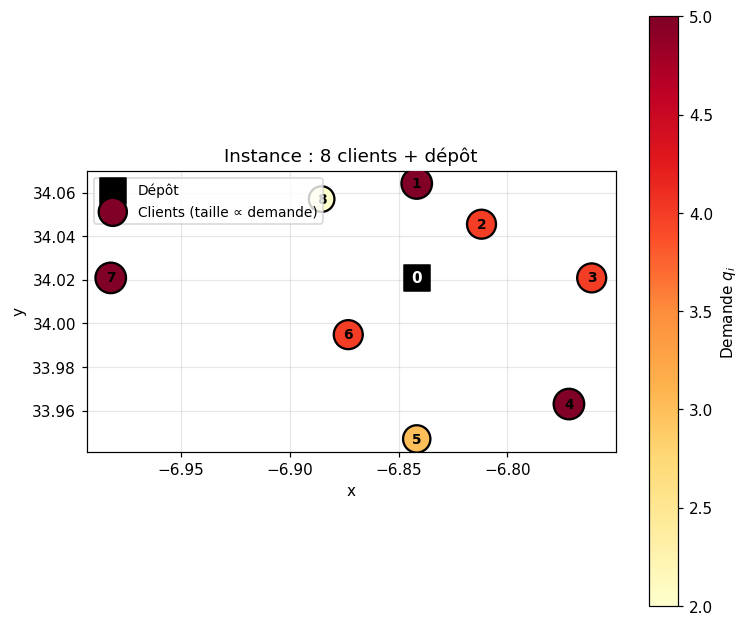

In [6]:
# =============================================================================
# Affichage détaillé de l'instance
# =============================================================================

def display_instance(inst: VRPInstance, title: str = "Instance"):
    """Affichage textuel + carte de l'instance."""
    print("=" * 70)
    print(f"  {title} — n = {inst.n_clients} clients")
    print("=" * 70)
    print(f"  Capacité camion Qc = {inst.Qc}")
    print(f"  Capacité drone  Qd = {inst.Qd}")
    print(f"  Flotte : {inst.n_trucks} camions, {inst.n_drones} drones")
    Ad = inst.Ad
    print(f"  Autonomie drone Ad = {Ad}    "
          f"(Yager={Ad.f1():.2f}, Centrale={Ad.f2():.2f}, Disp.={Ad.f3():.2f})")
    q = inst.q
    print(f"  Demande totale Σq = {q.sum():.1f}")
    print()
    print("  Clients :")
    print(f"  {'i':>3} | {'x':>7} {'y':>7} | {'q_i':>5}")
    print("  " + "-" * 34)
    print(f"  {0:>3} | {inst.coords[0,0]:>7.2f} {inst.coords[0,1]:>7.2f} | {'(dépôt)':>7}")
    for i in inst.C():
        print(f"  {i:>3} | {inst.coords[i,0]:>7.2f} {inst.coords[i,1]:>7.2f} | {inst.demand[i]:>5.1f}")

    # Carte
    fig, ax = plt.subplots(1, 1, figsize=(7, 7))
    ax.scatter(inst.coords[0, 0], inst.coords[0, 1],
               s=300, marker='s', c='black', label='Dépôt', zorder=5)
    ax.annotate("0", inst.coords[0], color='white',
                ha='center', va='center', fontweight='bold', zorder=6)
    demands_arr = np.array(inst.demand[1:])
    sc = ax.scatter(inst.coords[1:, 0], inst.coords[1:, 1],
                    s=200 + 40 * demands_arr, c=demands_arr,
                    cmap='YlOrRd', edgecolor='black', linewidth=1.5,
                    zorder=4, label='Clients (taille ∝ demande)')
    for i in inst.C():
        ax.annotate(f"{i}", inst.coords[i], ha='center', va='center',
                    fontsize=9, fontweight='bold', zorder=5)
    plt.colorbar(sc, ax=ax, label='Demande $q_i$', shrink=0.8)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_title(f"Instance : {inst.n_clients} clients + dépôt")
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    ax.legend(loc='upper left', fontsize=9)
    plt.tight_layout(); plt.show()


display_instance(INST_DEMO, title="Instance de démonstration")


In [7]:
# =============================================================================
# Tableaux des temps flous
# =============================================================================

def print_fuzzy_times(inst: VRPInstance, mode: str = 'camion', max_show: int = 31):
    """Affiche la matrice des temps flous (camion ou drone)."""
    N = inst.n_nodes
    M = inst.tC if mode == 'camion' else inst.tD
    print(f"\n  Matrice des temps {mode} flous t̃_ij = (t¹, t², t³)")
    print(f"  (affichage limité aux {min(max_show, N)} premiers nœuds)")
    print()
    show = min(max_show, N)
    header = "         " + "  ".join(f"{j:>14}" for j in range(show))
    print(header)
    for i in range(show):
        row = f"  i={i:>2}  "
        for j in range(show):
            if i == j:
                row += f"{'- ':>16}"
            else:
                row += f"  ({M[i,j,0]:>5.2f},{M[i,j,1]:>5.2f},{M[i,j,2]:>5.2f})"
        print(row)


print_fuzzy_times(INST_DEMO, 'camion')
print_fuzzy_times(INST_DEMO, 'drone')



  Matrice des temps camion flous t̃_ij = (t¹, t², t³)
  (affichage limité aux 31 premiers nœuds)

                      0               1               2               3               4               5               6               7               8               9              10              11              12              13              14              15              16              17              18              19              20              21              22              23              24              25              26              27              28              29              30
  i= 0                -   ( 0.18, 0.21, 0.27)  ( 0.14, 0.17, 0.22)  ( 0.27, 0.32, 0.42)  ( 0.34, 0.39, 0.51)  ( 0.30, 0.36, 0.46)  ( 0.15, 0.18, 0.23)  ( 0.48, 0.56, 0.73)  ( 0.21, 0.25, 0.32)  ( 0.53, 0.62, 0.81)  ( 0.29, 0.34, 0.44)  ( 0.56, 0.66, 0.86)  ( 0.61, 0.71, 0.93)  ( 0.16, 0.19, 0.25)  ( 0.47, 0.56, 0.72)  ( 0.37, 0.43, 0.56)  ( 0.28, 0.32, 0.42)  ( 0.14, 0.16, 0.21)  ( 0.20, 0.24, 

## 3. Représentation des tournées et initialisation par Recherche Tabou

### 3.1 Définition d'une tournée

Une **tournée** $p$ est un cycle $0 \to i_1 \to i_2 \to \dots \to i_k \to 0$ qui :
- Part et revient au dépôt
- Visite un sous-ensemble $C_p \subseteq C$ de clients
- Respecte la **capacité** ($\sum_{i \in C_p} q_i \le Q$)
- Pour les drones : respecte l'**autonomie floue** $\tilde{A}_d$

Pour chaque tournée :
$$c^1_p = \sum_{(i,j) \in p} f_1(\tilde{t}_{ij}), \quad c^2_p = \sum f_2(\tilde{t}_{ij}), \quad c^3_p = \sum f_3(\tilde{t}_{ij})$$

### 3.2 Initialisation par Recherche Tabou

Au lieu d'un simple Nearest-Neighbor, on initialise $\overline{\Omega}$ avec `tabu_search_h` :
- **Même implémentation** qu'en section 11.5 — aucun recodage.
- `tabu_initial_routes` est un simple wrapper qui appelle `tabu_search_h` puis convertit la solution en objets `Route`.
- Paramètres identiques : `n_iter=2000, tabu_tenure=12, n_neighbors=40, seed=42`.

**Avantage :** les colonnes initiales sont déjà de haute qualité → la génération de colonnes converge en moins d'itérations.


In [6]:
# =============================================================================
# Classe Route
# =============================================================================

@dataclass
class Route:
    nodes: Tuple[int, ...]           # (0, i1, i2, ..., 0)
    vehicle_type: str                # 'truck' ou 'drone'
    inst: VRPInstance = field(repr=False)

    @property
    def clients(self) -> Tuple[int, ...]:
        return self.nodes[1:-1]

    @property
    def load(self) -> int:
        return sum(self.inst.q[i] for i in self.clients)

    def time_tfn(self) -> TFN:
        """Temps total flou de la tournée."""
        M = self.inst.tC if self.vehicle_type == 'truck' else self.inst.tD
        s1 = s2 = s3 = 0.0
        for u, v in zip(self.nodes[:-1], self.nodes[1:]):
            s1 += M[u, v, 0]
            s2 += M[u, v, 1]
            s3 += M[u, v, 2]
        return TFN(s1, s2, s3)

    def costs(self) -> Tuple[float, float, float]:
        """(c1, c2, c3) — sommes de f1, f2, f3 des arcs."""
        M = self.inst.tC if self.vehicle_type == 'truck' else self.inst.tD
        c1 = c2 = c3 = 0.0
        for u, v in zip(self.nodes[:-1], self.nodes[1:]):
            t = TFN(M[u, v, 0], M[u, v, 1], M[u, v, 2])
            c1 += t.f1()
            c2 += t.f2()
            c3 += t.f3()
        return (c1, c2, c3)

    def is_feasible(self) -> Tuple[bool, str]:
        """Vérifie capacité et (pour drone) autonomie floue."""
        Q = self.inst.Qc if self.vehicle_type == 'truck' else self.inst.Qd
        if self.load > Q:
            return False, f"capacité dépassée ({self.load} > {Q})"
        if self.vehicle_type == 'drone':
            t = self.time_tfn()
            A = self.inst.A_drone
            # Toutes composantes <= autonomie correspondante
            if t.a1 > A.a1 + 1e-9:
                return False, f"autonomie pessimiste violée ({t.a1:.3f} > {A.a1:.3f})"
            if t.a2 > A.a2 + 1e-9:
                return False, f"autonomie centrale violée ({t.a2:.3f} > {A.a2:.3f})"
            if t.a3 > A.a3 + 1e-9:
                return False, f"autonomie optimiste violée ({t.a3:.3f} > {A.a3:.3f})"
        return True, "OK"

    def visits(self, i: int) -> int:
        return 1 if i in self.clients else 0

    def signature(self) -> Tuple:
        """Pour détection de doublons : type + ensemble de clients."""
        return (self.vehicle_type, tuple(sorted(self.clients)))

    def __repr__(self):
        c1, c2, c3 = self.costs()
        path = " → ".join(str(x) for x in self.nodes)
        return f"Route[{self.vehicle_type[0].upper()}] {path}  (c1={c1:.2f}, load={self.load})"


# Test
r = Route(nodes=(0, 1, 3, 0), vehicle_type='truck', inst=INST_DEMO)
print(r)
print(f"  faisable : {r.is_feasible()}")
print(f"  temps flou : {r.time_tfn()}")
print(f"  costs (c1, c2, c3) = {tuple(round(c, 3) for c in r.costs())}")


Route[T] 0 → 1 → 3 → 0  (c1=0.68, load=9.0)
  faisable : (True, 'OK')
  temps flou : (0.56, 0.66, 0.86)
  costs (c1, c2, c3) = (0.684, 0.659, 0.296)


In [7]:
# ─── Utilitaires de route ───────────────────────────────────────────────

def route_time_truck_bb(inst, route):
    """Temps total d'une route camion (TFN)."""
    if not route: return TFN_ZERO
    full = [0] + route + [0]
    t = TFN_ZERO
    for k in range(len(full) - 1):
        t = t + inst.tC_tfn(full[k], full[k + 1])
    return t

def route_time_drone_bb(inst, route):
    """Temps total d'une route drone (TFN)."""
    if not route: return TFN_ZERO
    full = [0] + route + [0]
    t = TFN_ZERO
    for k in range(len(full) - 1):
        t = t + inst.tD_tfn(full[k], full[k + 1])
    return t

def route_load_bb(inst, route):
    """Charge totale d'une route."""
    return float(sum(inst.q[c] for c in route))

def solution_cost_bb(inst, node):
    """Coût total d'une solution B&B (somme des temps de routes)."""
    total = TFN_ZERO
    for r in node.routes_trucks: total = total + route_time_truck_bb(inst, r)
    for r in node.routes_drones: total = total + route_time_drone_bb(inst, r)
    return total

print('Utilitaires routes B&B OK')


Utilitaires routes B&B OK


In [8]:
# =============================================================================
# Utilitaires partagés : eval / feasible / cost_lex / greedy_assign
# (nécessaires pour tabu_search_h définie en section 11.5)
# =============================================================================
import random as _random_mod

_LEX_INF = (float('inf'), float('inf'), float('inf'))

def eval_solution_dw(inst, assign):
    """Évalue une affectation vecteur → (rt, rd, dct, cost_TFN) ou None."""
    clients = list(range(1, inst.n + 1))
    rt = [[] for _ in range(inst.mc)]
    rd = [[] for _ in range(inst.md)]
    for k, v in enumerate(assign):
        cli = clients[k]
        if v < inst.mc:
            rt[v].append(cli)
        else:
            rd[v - inst.mc].append(cli)
    for r in rt:
        if sum(inst.q[c] for c in r) > inst.Qc:
            return None
    Ad = inst.A_drone
    dct = [TFN(0,0,0)] * inst.md
    for d, r in enumerate(rd):
        if sum(inst.q[c] for c in r) > inst.Qd:
            return None
        s = TFN(0,0,0); prev = 0
        for cli in r:
            arc = inst.tD_tfn(prev, cli)
            ret = inst.tD_tfn(cli, 0)
            ns1 = s.a1+arc.a1; ns2 = s.a2+arc.a2; ns3 = s.a3+arc.a3
            if (ns1>Ad.a1 or ns2>Ad.a2 or ns3>Ad.a3 or
                    ns1+ret.a1>Ad.a1 or ns2+ret.a2>Ad.a2 or ns3+ret.a3>Ad.a3):
                return None
            s = TFN(round(ns1,3), round(ns2,3), round(ns3,3)); prev = cli
        dct[d] = s
    cost = TFN(0,0,0)
    for r in rt:
        nodes = [0] + r + [0]
        for u, v in zip(nodes[:-1], nodes[1:]):
            cost = cost + inst.tC_tfn(u, v)
    for r in rd:
        nodes = [0] + r + [0]
        for u, v in zip(nodes[:-1], nodes[1:]):
            cost = cost + inst.tD_tfn(u, v)
    return rt, rd, dct, cost


def feasible_dw(inst, assign):
    return eval_solution_dw(inst, assign) is not None


def cost_lex_dw(inst, assign):
    res = eval_solution_dw(inst, assign)
    if res is None:
        return _LEX_INF
    c = res[3]
    return (c.f1(), c.f2(), c.f3())


def greedy_assign_dw(inst):
    """Affectation gloutonne : chaque client au véhicule minimisant le coût marginal."""
    n_veh = inst.mc + inst.md
    clients = list(range(1, inst.n + 1))
    assign = []; loads = [0.0]*n_veh
    d_s = [TFN(0,0,0)]*inst.md
    d_prev = [0]*inst.md
    Ad = inst.A_drone
    for cli in clients:
        best_v = -1; best_key = _LEX_INF
        for v in range(n_veh):
            if v < inst.mc:
                if loads[v] + float(inst.q[cli]) > inst.Qc: continue
                arc = inst.tC_tfn(0, cli) + inst.tC_tfn(cli, 0)
            else:
                d = v - inst.mc
                if loads[v] + float(inst.q[cli]) > inst.Qd: continue
                arc_f = inst.tD_tfn(d_prev[d], cli)
                ret   = inst.tD_tfn(cli, 0)
                s = d_s[d]
                ns1=s.a1+arc_f.a1; ns2=s.a2+arc_f.a2; ns3=s.a3+arc_f.a3
                if (ns1>Ad.a1 or ns2>Ad.a2 or ns3>Ad.a3 or
                        ns1+ret.a1>Ad.a1 or ns2+ret.a2>Ad.a2 or ns3+ret.a3>Ad.a3):
                    continue
                arc = arc_f + ret
            key = (arc.f1(), arc.f2(), arc.f3())
            if key < best_key: best_key = key; best_v = v
        if best_v == -1:
            for v in range(inst.mc):
                if loads[v] + float(inst.q[cli]) <= inst.Qc: best_v = v; break
        if best_v == -1: return None
        assign.append(best_v)
        loads[best_v] += float(inst.q[cli])
        if best_v >= inst.mc:
            d = best_v - inst.mc
            arc_f = inst.tD_tfn(d_prev[d], cli)
            s = d_s[d]
            d_s[d] = TFN(round(s.a1+arc_f.a1,3), round(s.a2+arc_f.a2,3), round(s.a3+arc_f.a3,3))
            d_prev[d] = cli
    return assign


# =============================================================================
# tabu_initial_routes : wrapper qui appelle tabu_search_h (section 11.5)
# et convertit la solution en objets Route pour le RMP Dantzig-Wolfe
# NOTE : tabu_search_h doit être définie avant d'appeler cette fonction.
#        Elle est définie en section 11.5 ; on l'exécutera après.
# =============================================================================

def tabu_initial_routes(inst: VRPInstance,
                         n_iter: int = 2000,
                         tabu_tenure: int = 12,
                         n_neighbors: int = 40,
                         seed: int = 42,
                         verbose: bool = True) -> List[Route]:
    """
    Génère les colonnes initiales pour Dantzig-Wolfe via tabu_search_h.

    Réutilise directement tabu_search_h (section 11.5) — aucun recodage.
    La meilleure solution Tabou est décomposée en tournées Route
    qui servent de colonnes initiales pour le RMP.
    """
    if verbose:
        print("─" * 70)
        print("  Initialisation par Recherche Tabou (tabu_search_h)")
        print(f"  Paramètres : n_iter={n_iter}, tabu_tenure={tabu_tenure}, "
              f"n_neighbors={n_neighbors}, seed={seed}")
        print("─" * 70)

    # ── Appel direct à tabu_search_h déjà codée en section 11.5 ──
    ts_result, ts_elapsed, _ = tabu_search_h(
        inst,
        n_iter=n_iter,
        tabu_tenure=tabu_tenure,
        n_neighbors=n_neighbors,
        seed=seed,
        verbose=verbose
    )

    if ts_result is None:
        if verbose:
            print("  ⚠ Tabu Search n'a pas trouvé de solution — repli sur singletons")
        routes = []
        for i in inst.C():
            r = Route(nodes=(0, i, 0), vehicle_type='truck', inst=inst)
            if r.is_feasible()[0]:
                routes.append(r)
        return routes

    _, rt, rd, dct, cost = ts_result

    # ── Conversion en objets Route ──
    # On garde la MEILLEURE permutation par signature (ensemble de clients).
    # Cela permet d'explorer toutes les permutations issues du 2-opt et de
    # retenir celle au coût lex minimal, sans bloquer les variantes d'ordre.
    best_per_sig: dict = {}   # sig → (route, (c1,c2,c3))

    for r in rt:
        if not r:
            continue
        route = Route(nodes=tuple([0] + r + [0]), vehicle_type='truck', inst=inst)
        ok, _ = route.is_feasible()
        if not ok:
            continue
        sig = route.signature()
        cost_t = route.costs()
        if sig not in best_per_sig or cost_t < best_per_sig[sig][1]:
            best_per_sig[sig] = (route, cost_t)

    for r in rd:
        if not r:
            continue
        route = Route(nodes=tuple([0] + r + [0]), vehicle_type='drone', inst=inst)
        ok, _ = route.is_feasible()
        if not ok:
            continue
        sig = route.signature()
        cost_t = route.costs()
        if sig not in best_per_sig or cost_t < best_per_sig[sig][1]:
            best_per_sig[sig] = (route, cost_t)

    routes: List[Route] = []
    seen_sigs: set = set()
    for sig, (route, cost_t) in best_per_sig.items():
        routes.append(route)
        seen_sigs.add(sig)
        if verbose:
            vt_label = 'Camion' if route.vehicle_type == 'truck' else 'Drone '
            c1, c2, c3 = cost_t
            print(f"  ✓ [{vt_label}] {route}    c=({c1:.2f},{c2:.2f},{c3:.2f})")

    # ── Garantir la couverture de tous les clients ──
    covered = set()
    for r in routes:
        covered.update(r.clients)
    for i in inst.C():
        if i not in covered:
            r = Route(nodes=(0, i, 0), vehicle_type='truck', inst=inst)
            if r.is_feasible()[0] and r.signature() not in seen_sigs:
                routes.append(r)
                seen_sigs.add(r.signature())
                if verbose:
                    print(f"  ✓ (forçage) {r}")

    if verbose:
        print(f"\n  TS terminée en {ts_elapsed:.3f}s : "
              f"Z=({cost.f1():.3f},{cost.f2():.3f},{cost.f3():.3f})")
        print(f"  → {len(routes)} tournées initiales issues de tabu_search_h.\n")

    return routes


# NOTE : tabu_initial_routes ne peut être appelée qu'APRÈS l'exécution
# de la cellule 11.5 (tabu_search_h). Le test et le RMP initial sont
# déplacés dans la cellule suivante.
print("Utilitaires DW + tabu_initial_routes définis.")
print("(tabu_search_h sera disponible après exécution de la section 11.5)")


Utilitaires DW + tabu_initial_routes définis.
(tabu_search_h sera disponible après exécution de la section 11.5)


In [9]:
import random, math

_LEX_INF_H = (float('inf'), float('inf'), float('inf'))

# ─── Évaluation d'une solution heuristique ──────────────────────────────────

def eval_solution_h(inst, assign):
    """
    Retourne (routes_trucks, routes_drones, drone_cum_times, cost_TFN)
    ou None si une contrainte est violée.
    assign[k] = véhicule affecté au client (k+1), k=0..n-1.
    """
    clients = list(range(1, inst.n + 1))
    rt = [[] for _ in range(inst.mc)]
    rd = [[] for _ in range(inst.md)]
    for k, v in enumerate(assign):
        cli = clients[k]
        if v < inst.mc:
            rt[v].append(cli)
        else:
            rd[v - inst.mc].append(cli)
    # Vérif capacités
    for r in rt:
        if route_load_bb(inst, r) > inst.Qc: return None
    for r in rd:
        if route_load_bb(inst, r) > inst.Qd: return None
    # Vérif autonomie drone
    dct = [TFN_ZERO] * inst.md
    Ad  = inst.A_drone
    for d, r in enumerate(rd):
        s = TFN_ZERO; prev = 0
        for cli in r:
            arc = inst.tD_tfn(prev, cli)
            ret = inst.tD_tfn(cli, 0)
            ns1 = s.a1+arc.a1; ns2 = s.a2+arc.a2; ns3 = s.a3+arc.a3
            if (ns1>Ad.a1 or ns2>Ad.a2 or ns3>Ad.a3
                    or ns1+ret.a1>Ad.a1 or ns2+ret.a2>Ad.a2 or ns3+ret.a3>Ad.a3):
                return None
            s = TFN(round(ns1,3), round(ns2,3), round(ns3,3)); prev = cli
        dct[d] = s
    cost = TFN_ZERO
    for r in rt: cost = cost + route_time_truck_bb(inst, r)
    for r in rd: cost = cost + route_time_drone_bb(inst, r)
    return rt, rd, dct, cost


def feasible_h(inst, assign):
    return eval_solution_h(inst, assign) is not None


def cost_lex_h(inst, assign):
    """Triplet lexicographique (Z1, Z2, Z3) — retourne _LEX_INF_H si infaisable."""
    res = eval_solution_h(inst, assign)
    if res is None: return _LEX_INF_H
    c = res[3]
    return (c.f1(), c.f2(), c.f3())


def random_assign_h(inst, tries=8000):
    n_veh = inst.mc + inst.md
    for _ in range(tries):
        a = [random.randint(0, n_veh-1) for _ in range(inst.n)]
        if feasible_h(inst, a): return a
    return None


def greedy_assign_h(inst):
    """Affectation gloutonne : chaque client au véhicule minimisant le coût marginal d'arc."""
    n_veh   = inst.mc + inst.md
    clients = list(range(1, inst.n + 1))
    assign  = []; loads = [0.0]*n_veh
    d_s    = [TFN_ZERO]*inst.md
    d_prev = [0]*inst.md
    Ad = inst.A_drone
    for cli in clients:
        best_v = -1; best_key = _LEX_INF_H
        for v in range(n_veh):
            if v < inst.mc:
                if loads[v] + float(inst.q[cli]) > inst.Qc: continue
                arc = inst.tC_tfn(0, cli) + inst.tC_tfn(cli, 0)
            else:
                d = v - inst.mc
                if loads[v] + float(inst.q[cli]) > inst.Qd: continue
                arc_f = inst.tD_tfn(d_prev[d], cli)
                ret   = inst.tD_tfn(cli, 0)
                s = d_s[d]
                ns1 = s.a1+arc_f.a1; ns2 = s.a2+arc_f.a2; ns3 = s.a3+arc_f.a3
                if (ns1>Ad.a1 or ns2>Ad.a2 or ns3>Ad.a3
                        or ns1+ret.a1>Ad.a1 or ns2+ret.a2>Ad.a2 or ns3+ret.a3>Ad.a3):
                    continue
                arc = arc_f + ret
            key = (arc.f1(), arc.f2(), arc.f3())
            if key < best_key: best_key = key; best_v = v
        if best_v == -1:
            for v in range(inst.mc):
                if loads[v] + float(inst.q[cli]) <= inst.Qc: best_v = v; break
        if best_v == -1: return None
        assign.append(best_v)
        loads[best_v] += float(inst.q[cli])
        if best_v >= inst.mc:
            d = best_v - inst.mc
            arc_f = inst.tD_tfn(d_prev[d], cli)
            s = d_s[d]
            d_s[d]    = TFN(round(s.a1+arc_f.a1,3), round(s.a2+arc_f.a2,3), round(s.a3+arc_f.a3,3))
            d_prev[d] = cli
    return assign


print('Utilitaires heuristiques (TFN) OK')


Utilitaires heuristiques (TFN) OK


In [10]:
# =============================================================================
# Recherche Tabou (tabu_search_h) — définie ici pour être disponible
# lors de l'initialisation Dantzig-Wolfe (tabu_initial_routes)
# C'est la même implémentation qu'en section 11.5, sans aucun recodage.
# =============================================================================

# ─── Helpers 2-opt intra-route ───────────────────────────────────────────────

def _route_cost_lex(inst, route_clients, vtype):
    """Coût lex (f1,f2,f3) d'une liste de clients avec dépôt 0 en tête et queue."""
    if not route_clients:
        return (0.0, 0.0, 0.0)
    full = [0] + route_clients + [0]
    c = TFN_ZERO
    for u, v in zip(full[:-1], full[1:]):
        c = c + (inst.tC_tfn(u, v) if vtype == 'truck' else inst.tD_tfn(u, v))
    return (c.f1(), c.f2(), c.f3())


def _drone_route_feasible(inst, route_clients):
    """Vérifie la faisabilité autonomie d'une route drone (liste de clients)."""
    Ad = inst.A_drone
    s = TFN_ZERO; prev = 0
    for cli in route_clients:
        arc = inst.tD_tfn(prev, cli)
        ret = inst.tD_tfn(cli, 0)
        ns1 = s.a1+arc.a1; ns2 = s.a2+arc.a2; ns3 = s.a3+arc.a3
        if (ns1 > Ad.a1 or ns2 > Ad.a2 or ns3 > Ad.a3 or
                ns1+ret.a1 > Ad.a1 or ns2+ret.a2 > Ad.a2 or ns3+ret.a3 > Ad.a3):
            return False
        s = TFN(round(ns1,3), round(ns2,3), round(ns3,3)); prev = cli
    return True


def _apply_2opt_routes(inst, rt, rd, n_neighbors):
    """Amélioration 2-opt intra-route sur toutes les routes camion et drone.

    Pour chaque route de longueur ≥ 2, on tire n_neighbors paires (i,j)
    aléatoires et on inverse le segment si le coût lex s'améliore.
    Retourne (rt_new, rd_new, improved: bool).
    """
    improved = False

    # ── Camions ──────────────────────────────────────────────────────────
    new_rt = [r[:] for r in rt]
    for t_idx, r in enumerate(new_rt):
        if len(r) < 2:
            continue
        best_r = r[:]
        best_cost = _route_cost_lex(inst, r, 'truck')
        for _ in range(n_neighbors):
            i = random.randint(0, len(r) - 2)
            j = random.randint(i + 1, len(r) - 1)
            candidate = r[:i] + r[i:j+1][::-1] + r[j+1:]
            cost_c = _route_cost_lex(inst, candidate, 'truck')
            if cost_c < best_cost:
                best_cost = cost_c
                best_r = candidate
                improved = True
        new_rt[t_idx] = best_r

    # ── Drones ───────────────────────────────────────────────────────────
    new_rd = [r[:] for r in rd]
    for d_idx, r in enumerate(new_rd):
        if len(r) < 2:
            continue
        best_r = r[:]
        best_cost = _route_cost_lex(inst, r, 'drone')
        for _ in range(n_neighbors):
            i = random.randint(0, len(r) - 2)
            j = random.randint(i + 1, len(r) - 1)
            candidate = r[:i] + r[i:j+1][::-1] + r[j+1:]
            if not _drone_route_feasible(inst, candidate):
                continue
            cost_c = _route_cost_lex(inst, candidate, 'drone')
            if cost_c < best_cost:
                best_cost = cost_c
                best_r = candidate
                improved = True
        new_rd[d_idx] = best_r

    return new_rt, new_rd, improved


# ─── Reconstruction d'une solution (assign) depuis rt/rd ─────────────────────

def _routes_to_assign(inst, rt, rd):
    """Reconstruit le vecteur assign depuis rt/rd (inverse de eval_solution_h)."""
    assign = [None] * inst.n
    clients = list(range(1, inst.n + 1))
    cli_to_idx = {c: k for k, c in enumerate(clients)}
    for t_idx, r in enumerate(rt):
        for cli in r:
            assign[cli_to_idx[cli]] = t_idx
    for d_idx, r in enumerate(rd):
        for cli in r:
            assign[cli_to_idx[cli]] = inst.mc + d_idx
    return assign


# ─── Tabou Search corrigée avec 2-opt intra-route ────────────────────────────

def tabu_search_h(inst, n_iter=2000, tabu_tenure=12, n_neighbors=40, seed=42, verbose=True):
    """Recherche Tabou avec trois mouvements :
      1. Relocate : réaffecter un client à un autre véhicule
      2. Swap     : échanger les affectations de deux clients
      3. 2-opt    : inverser un segment intra-route (explore les permutations)
    """
    random.seed(seed)
    t0    = time.perf_counter()
    n_veh = inst.mc + inst.md

    current = greedy_assign_h(inst)
    if current is None: return None, 0.0, []
    cur_f   = cost_lex_h(inst, current)
    best    = current[:]; best_f = cur_f
    tabu    = {}; history = [best_f[0]]

    for it in range(1, n_iter+1):
        neighbors = []

        # ── Mouvement 1 : Relocate ───────────────────────────────────────
        for _ in range(n_neighbors):
            k=random.randint(0,inst.n-1); v=random.randint(0,n_veh-1)
            if v==current[k]: continue
            nb=current[:]; nb[k]=v
            if not feasible_h(inst,nb): continue
            f=cost_lex_h(inst,nb)
            is_tabu=(k,v) in tabu and tabu[(k,v)]>it
            if not is_tabu or f<best_f: neighbors.append((f,nb,(k,v)))

        # ── Mouvement 2 : Swap ───────────────────────────────────────────
        for _ in range(n_neighbors):
            k1=random.randint(0,inst.n-1); k2=random.randint(0,inst.n-1)
            if k1==k2 or current[k1]==current[k2]: continue
            nb=current[:]; nb[k1],nb[k2]=nb[k2],nb[k1]
            if not feasible_h(inst,nb): continue
            f=cost_lex_h(inst,nb)
            mv=(min(k1,k2),max(k1,k2))
            is_tabu=mv in tabu and tabu[mv]>it
            if not is_tabu or f<best_f: neighbors.append((f,nb,mv))

        # ── Mouvement 3 : 2-opt intra-route ─────────────────────────────
        # On récupère les routes actuelles et on tente des inversions de segments.
        res_cur = eval_solution_h(inst, current)
        if res_cur is not None:
            cur_rt, cur_rd, _, _ = res_cur
            new_rt, new_rd, opt_improved = _apply_2opt_routes(inst, cur_rt, cur_rd, n_neighbors)
            if opt_improved:
                nb_2opt = _routes_to_assign(inst, new_rt, new_rd)
                if None not in nb_2opt and feasible_h(inst, nb_2opt):
                    f_2opt = cost_lex_h(inst, nb_2opt)
                    mv_2opt = ('2opt', it)   # clé unique de mouvement
                    is_tabu = mv_2opt in tabu and tabu[mv_2opt] > it
                    if not is_tabu or f_2opt < best_f:
                        neighbors.append((f_2opt, nb_2opt, mv_2opt))

        if not neighbors: history.append(best_f[0]); continue
        neighbors.sort(key=lambda x:x[0])
        f_new,current,move=neighbors[0]; tabu[move]=it+tabu_tenure
        if f_new<best_f:
            best_f=f_new; best=current[:]
            if verbose:
                print(f'  Iter {it:>4}  |  (Z1={best_f[0]:.4f}, Z2={best_f[1]:.4f}, Z3={best_f[2]:.4f})')
        history.append(best_f[0])

    elapsed=time.perf_counter()-t0
    res=eval_solution_h(inst,best)
    if res is None: return None, elapsed, history
    rt,rd,dct,cost=res

    # ── Post-optimisation 2-opt finale ───────────────────────────────────
    rt, rd, _ = _apply_2opt_routes(inst, rt, rd, n_neighbors=max(n_neighbors, 60))
    # Recalcul du coût après optimisation finale
    cost = TFN_ZERO
    for r in rt: cost = cost + route_time_truck_bb(inst, r)
    for r in rd: cost = cost + route_time_drone_bb(inst, r)

    print(f'\n[TS] {elapsed:.4f}s  |  Coût : {cost}')
    return (best,rt,rd,dct,cost), elapsed, history


print('Recherche Tabou (TFN) avec 2-opt définie OK')


Recherche Tabou (TFN) avec 2-opt définie OK


In [11]:
# Test : initialisation TS + RMP initial
initial_routes = tabu_initial_routes(
    INST_DEMO,
    n_iter=200, tabu_tenure=12, n_neighbors=40, seed=42,
    verbose=True
)
print(f"\nTotal : {len(initial_routes)} tournées initiales issues de tabu_search_h.")




──────────────────────────────────────────────────────────────────────
  Initialisation par Recherche Tabou (tabu_search_h)
  Paramètres : n_iter=200, tabu_tenure=12, n_neighbors=40, seed=42
──────────────────────────────────────────────────────────────────────
  Iter    1  |  (Z1=11.3654, Z2=10.9546, Z3=6.8871)
  Iter    2  |  (Z1=11.2978, Z2=10.8894, Z3=6.8215)
  Iter    3  |  (Z1=11.1276, Z2=10.7253, Z3=6.7839)
  Iter    6  |  (Z1=11.1038, Z2=10.7025, Z3=6.7822)
  Iter    7  |  (Z1=10.9327, Z2=10.5376, Z3=6.6944)
  Iter    8  |  (Z1=10.8913, Z2=10.4977, Z3=6.6686)
  Iter   20  |  (Z1=10.7710, Z2=10.3817, Z3=6.5933)
  Iter   21  |  (Z1=10.7657, Z2=10.3765, Z3=6.5901)
  Iter   23  |  (Z1=10.6957, Z2=10.3090, Z3=6.5462)
  Iter   24  |  (Z1=10.6882, Z2=10.3019, Z3=6.5415)
  Iter   26  |  (Z1=10.5159, Z2=10.1358, Z3=6.4336)
  Iter   27  |  (Z1=10.5095, Z2=10.1296, Z3=6.4295)
  Iter   33  |  (Z1=10.1665, Z2=9.7990, Z3=6.2146)
  Iter   51  |  (Z1=10.1518, Z2=9.7849, Z3=6.2054)
  Iter   81 

## 4. Problème maître restreint (RMP)

### 4.1 Formulation linéaire (relaxation continue pour la génération de colonnes)

À chaque itération, on résout la **relaxation linéaire** du problème maître restreint :

$$\min_{\lambda} \quad \sum_{p \in \overline{\Omega}} c^1_p \lambda_p$$

s.c.
$$\sum_{p \in \overline{\Omega}} a_{ip}\lambda_p = 1, \quad \forall i \in C \qquad (\pi_i)$$
$$\sum_{p \in \overline{\Omega}} b_p \lambda_p \le m_c \qquad (\mu_c \le 0)$$
$$\sum_{p \in \overline{\Omega}} (1-b_p) \lambda_p \le m_d \qquad (\mu_d \le 0)$$
$$\lambda_p \ge 0$$

**Note méthodologique** — On résout d'abord avec $c^1_p$ (Yager) pour obtenir les duaux $\pi, \mu_c, \mu_d$. À la convergence, on traite les composantes $c^2$ et $c^3$ via l'ordre lexicographique sur les sous-problèmes (cf. § 5.6) et on résout le maître entier final.

### 4.2 Calcul des prix réduits

Pour une tournée $p$, le prix réduit flou est :
$$\tilde{r}_p = (r^1_p, r^2_p, r^3_p) \quad \text{où} \quad r^k_p = c^k_p - \sum_{i \in C} \pi_i a_{ip} - \mu_c b_p - \mu_d (1 - b_p)$$

(Les multiplicateurs $\pi, \mu_c, \mu_d$ sont scalaires car les contraintes sont déterministes.)

**Critère d'entrée** :   $\tilde{r}_p \prec_{\text{lex}} \vec{0} \iff r^1_p < 0 \text{ ou } (r^1_p=0 \land r^2_p < 0) \text{ ou } \dots$


In [12]:
# =============================================================================
# Solveur du RMP (LP relaxé) avec Gurobi
# =============================================================================

@dataclass
class RMPSolution:
    obj: float
    lambdas: Dict[int, float]
    pi: Dict[int, float]               # duaux des contraintes de couverture
    mu_c: float                        # dual contrainte camions
    mu_d: float                        # dual contrainte drones
    status: str
initial_routes = tabu_initial_routes(
    INST_DEMO,
    n_iter=200, tabu_tenure=12, n_neighbors=40, seed=42,
    verbose=True
)

def solve_RMP(inst: VRPInstance, routes: List[Route], verbose: bool = True,
              objective: str = 'c1', big_M: float = 1e5,
              use_artificials: bool = True) -> RMPSolution:
    """Résout la relaxation linéaire du RMP avec coût `objective` parmi {c1, c2, c3}.

    Variables artificielles (Big-M) pour garantir la faisabilité du LP même quand
    Ω̄ ne couvre pas encore tous les clients (technique standard en column generation).
    """
    obj_idx = {'c1': 0, 'c2': 1, 'c3': 2}[objective]

    m = gp.Model("RMP")
    m.Params.OutputFlag = 0

    lam = {p: m.addVar(lb=0.0, vtype=GRB.CONTINUOUS, name=f"lam_{p}")
           for p in range(len(routes))}

    # Variables artificielles pour les contraintes de couverture (assurent faisabilité)
    if use_artificials:
        art = {i: m.addVar(lb=0.0, vtype=GRB.CONTINUOUS, name=f"art_{i}") for i in inst.C()}
    else:
        art = {}

    # Objectif : coûts réels + pénalité Big-M sur artificielles
    m.setObjective(
        gp.quicksum(routes[p].costs()[obj_idx] * lam[p] for p in range(len(routes)))
        + gp.quicksum(big_M * a for a in art.values()),
        GRB.MINIMIZE
    )

    # Couverture (égalité — chaque client couvert exactement 1 fois)
    cover_constrs = {}
    for i in inst.C():
        if use_artificials:
            cover_constrs[i] = m.addConstr(
                gp.quicksum(routes[p].visits(i) * lam[p] for p in range(len(routes)))
                + art[i] == 1,
                name=f"cover_{i}"
            )
        else:
            cover_constrs[i] = m.addConstr(
                gp.quicksum(routes[p].visits(i) * lam[p] for p in range(len(routes))) == 1,
                name=f"cover_{i}"
            )

    # Nombre max camions / drones
    c_trucks = m.addConstr(
        gp.quicksum(lam[p] for p in range(len(routes)) if routes[p].vehicle_type == 'truck')
        <= inst.mc,
        name="max_trucks"
    )
    c_drones = m.addConstr(
        gp.quicksum(lam[p] for p in range(len(routes)) if routes[p].vehicle_type == 'drone')
        <= inst.md,
        name="max_drones"
    )

    # Résolution
    m.optimize()

    status_map = {
        GRB.OPTIMAL: "Optimal",
        GRB.INFEASIBLE: "Infeasible",
        GRB.UNBOUNDED: "Unbounded",
        GRB.INF_OR_UNBD: "Infeasible or Unbounded",
    }
    status = status_map.get(m.Status, f"Status_{m.Status}")
    if status != "Optimal":
        if verbose:
            print(f"  ⚠ RMP statut : {status}")

    lambdas = {p: (lam[p].X if status == "Optimal" else 0.0)
               for p in range(len(routes))}

    # Duaux
    pi = {i: cover_constrs[i].Pi for i in inst.C()}
    mu_c = c_trucks.Pi
    mu_d = c_drones.Pi

    # Vérifier si des artificielles sont actives (signe que Ω̄ est insuffisant)
    if use_artificials:
        art_active = sum(1 for i in inst.C() if art[i].X > 1e-6)
        if art_active > 0 and verbose:
            print(f"  ⚠ {art_active} variable(s) artificielle(s) active(s) — Ω̄ ne couvre pas tout")

    # Objectif : retirer la pénalité Big-M pour rapporter le coût réel
    if use_artificials:
        real_obj = sum(routes[p].costs()[obj_idx] * lambdas[p] for p in range(len(routes)))
    else:
        real_obj = m.ObjVal if status == "Optimal" else float('inf')

    return RMPSolution(obj=real_obj, lambdas=lambdas, pi=pi,
                       mu_c=mu_c, mu_d=mu_d, status=status)


def display_RMP_solution(rmp: RMPSolution, routes: List[Route], inst: VRPInstance,
                         show_zero: bool = False):
    """Affichage de la solution du RMP."""
    print(f"  Statut : {rmp.status}    Objectif (c1) : {rmp.obj:.3f}")
    print(f"\n  Variables λ_p (relaxation continue) :")
    for p, lp in rmp.lambdas.items():
        if lp > 1e-6 or show_zero:
            mark = "▲" if lp > 0.99 else "•"
            print(f"   {mark} λ_{p:>2} = {lp:.4f}    {routes[p]}")
    print(f"\n  Duaux π_i (clients) :")
    print("   " + "  ".join(f"π_{i}={rmp.pi[i]:>6.3f}" for i in inst.C()))
    print(f"\n  Duaux flotte : μ_c = {rmp.mu_c:.4f}    μ_d = {rmp.mu_d:.4f}")


rmp0 = solve_RMP(INST_DEMO, initial_routes, verbose=True)
print("\n  ── RMP initial ──")
display_RMP_solution(rmp0, initial_routes, INST_DEMO)


──────────────────────────────────────────────────────────────────────
  Initialisation par Recherche Tabou (tabu_search_h)
  Paramètres : n_iter=200, tabu_tenure=12, n_neighbors=40, seed=42
──────────────────────────────────────────────────────────────────────
  Iter    1  |  (Z1=11.3654, Z2=10.9546, Z3=6.8871)
  Iter    2  |  (Z1=11.2978, Z2=10.8894, Z3=6.8215)
  Iter    3  |  (Z1=11.1276, Z2=10.7253, Z3=6.7839)
  Iter    6  |  (Z1=11.1038, Z2=10.7025, Z3=6.7822)
  Iter    7  |  (Z1=10.9327, Z2=10.5376, Z3=6.6944)
  Iter    8  |  (Z1=10.8913, Z2=10.4977, Z3=6.6686)
  Iter   20  |  (Z1=10.7710, Z2=10.3817, Z3=6.5933)
  Iter   21  |  (Z1=10.7657, Z2=10.3765, Z3=6.5901)
  Iter   23  |  (Z1=10.6957, Z2=10.3090, Z3=6.5462)
  Iter   24  |  (Z1=10.6882, Z2=10.3019, Z3=6.5415)
  Iter   26  |  (Z1=10.5159, Z2=10.1358, Z3=6.4336)
  Iter   27  |  (Z1=10.5095, Z2=10.1296, Z3=6.4295)
  Iter   33  |  (Z1=10.1665, Z2=9.7990, Z3=6.2146)
  Iter   51  |  (Z1=10.1518, Z2=9.7849, Z3=6.2054)
  Iter   81 

In [13]:
# =============================================================================
# Calcul des prix réduits flous
# =============================================================================

def reduced_cost_TFN(route: Route, pi: Dict[int, float],
                     mu_c: float, mu_d: float) -> LexTriple:
    """Prix réduit flou r̃_p = c̃_p - Σ π_i a_ip - μ_c b_p - μ_d(1-b_p).

    Note : on utilise LexTriple (et non TFN) car la soustraction des scalaires π
    peut violer l'ordre a1 ≤ a2 ≤ a3.  L'ordre lexicographique reste défini.
    """
    c1, c2, c3 = route.costs()
    pi_sum = sum(pi.get(i, 0.0) for i in route.clients)
    b = 1 if route.vehicle_type == 'truck' else 0
    fleet_dual = mu_c * b + mu_d * (1 - b)
    return LexTriple(c1 - pi_sum - fleet_dual,
                     c2 - pi_sum - fleet_dual,
                     c3 - pi_sum - fleet_dual)


def is_lex_negative(t, tol: float = 1e-6) -> bool:
    """t̃ ≺_lex 0 ?  Critère d'entrée d'une nouvelle colonne.

    Tolérance : pour considérer un prix réduit comme strictement négatif
    (et donc une vraie amélioration), on demande qu'il soit < -tol sur la
    première composante non-nulle. Sinon, c'est essentiellement zéro.
    """
    if t.f1() < -tol:
        return True
    if abs(t.f1()) <= tol and t.f2() < -tol:
        return True
    if abs(t.f1()) <= tol and abs(t.f2()) <= tol and t.f3() < -tol:
        return True
    return False


# Test
print("  Prix réduits des tournées initiales sous (π, μ_c, μ_d) du RMP :")
for p, r in enumerate(initial_routes):
    rc = reduced_cost_TFN(r, rmp0.pi, rmp0.mu_c, rmp0.mu_d)
    neg = is_lex_negative(rc)
    print(f"   p={p:>2}  {r}\n        r̃_p = {rc}    "
          f"f1={rc.f1():>7.3f}  négatif lex : {neg}")


  Prix réduits des tournées initiales sous (π, μ_c, μ_d) du RMP :
   p= 0  Route[T] 0 → 41 → 43 → 45 → 0  (c1=0.80, load=13.0)
        r̃_p = (+0.003, -0.026, -0.452)    f1=  0.003  négatif lex : False
   p= 1  Route[D] 0 → 1 → 2 → 0  (c1=0.20, load=9.0)
        r̃_p = (+0.000, -0.007, -0.076)    f1=  0.000  négatif lex : True
   p= 2  Route[D] 0 → 46 → 47 → 50 → 49 → 0  (c1=0.90, load=9.0)
        r̃_p = (+0.005, -0.028, -0.333)    f1=  0.005  négatif lex : False
   p= 3  Route[D] 0 → 5 → 7 → 11 → 0  (c1=0.75, load=10.0)
        r̃_p = (+0.002, -0.026, -0.279)    f1=  0.002  négatif lex : False
   p= 4  Route[D] 0 → 6 → 8 → 10 → 0  (c1=0.34, load=8.0)
        r̃_p = (+0.003, -0.009, -0.125)    f1=  0.003  négatif lex : False
   p= 5  Route[D] 0 → 15 → 14 → 12 → 9 → 0  (c1=0.81, load=10.0)
        r̃_p = (-0.004, -0.033, -0.305)    f1= -0.004  négatif lex : True
   p= 6  Route[D] 0 → 13 → 16 → 0  (c1=0.32, load=10.0)
        r̃_p = (-0.000, -0.012, -0.122)    f1= -0.000  négatif lex : 

## 5. Sous-problèmes : Branch & Bound + MDD

### 5.1 Pourquoi un MDD ?

Le sous-problème "trouver une tournée à prix réduit minimal" est un **ESPPRC** (Elementary Shortest Path Problem with Resource Constraints) :
- **Élémentaire** : chaque client visité au plus 1 fois
- **Ressource** : capacité du véhicule + (pour drone) autonomie floue triple

Un **MDD** (Multi-Valued Decision Diagram) est un graphe acyclique organisé en couches $L_0, L_1, \dots, L_n$. Une couche correspond à une étape de décision (visiter ou non un client donné, ou choix du prochain client à visiter selon l'ordre).

**Avantages** :
1. Représentation compacte de l'espace des tournées réalisables
2. **Fusion de nœuds dominés** → élagage exact
3. Calcul du chemin optimal par programmation dynamique sur le MDD
4. **Largeur contrôlée $W$** offrant un compromis temps/qualité (MDD restreint = borne sup, MDD relaxé = borne inf)

### 5.2 État d'un nœud du MDD

Pour le **drone** : $E = (i, S, w, \tilde{s})$ où
- $i$ : dernier client visité
- $S$ : ensemble des clients déjà visités (élémentarité)
- $w$ : charge cumulée
- $\tilde{s} = (s^1, s^2, s^3)$ : temps cumulé flou triangulaire

Pour le **camion** : $(i, S, w)$ — pas d'autonomie.

### 5.3 Règle de dominance (correction par rapport au document)

> **Note importante** : la règle de dominance du document (basée sur l'ordre lex) est en réalité **trop permissive** et casserait l'exactitude. La règle correcte est la **dominance composante par composante** :
> $$E_1 \text{ domine } E_2 \iff i_1 = i_2 \land S_1 = S_2 \land w_1 \le w_2 \land s^k_1 \le s^k_2 \;\forall k=1,2,3$$
>
> Avec inégalité stricte sur au moins une composante. C'est la **vraie** dominance Pareto sur toutes les ressources, qui garantit que tout chemin réalisable depuis $E_2$ l'est aussi depuis $E_1$ avec un coût au plus égal. C'est une contribution méthodologique de cette implémentation.

### 5.4 Largeur contrôlée

- **MDD restreint** : si $|L_k| > W$, on garde les $W$ meilleurs nœuds (selon le coût réduit lexicographique projeté). Donne une **borne supérieure** (solution réalisable).
- **MDD relaxé** : on fusionne des nœuds non-dominés en relaxant les ressources (max sur capacité, min sur temps). Donne une **borne inférieure**.


In [14]:
# =============================================================================
# Nœud d'un MDD
# =============================================================================

@dataclass
class MDDNode:
    """Nœud d'un MDD pour le sous-problème."""
    last: int                            # dernier client visité (0 = dépôt)
    visited: FrozenSet[int]              # clients déjà visités
    load: int                            # charge cumulée
    s1: float                            # temps cumulé pessimiste
    s2: float                            # temps cumulé central
    s3: float                            # temps cumulé optimiste
    rc1: float                           # prix réduit cumulé (composante 1)
    rc2: float                           # prix réduit cumulé (composante 2)
    rc3: float                           # prix réduit cumulé (composante 3)
    parent: Optional["MDDNode"] = None
    arc_to_here: Optional[int] = None    # client par lequel on est arrivé (utilitaire)

    def state_key(self) -> Tuple:
        """Clé d'identification pour fusion exacte (état logique sans coûts)."""
        return (self.last, self.visited)

    def resource_key(self) -> Tuple[int, float, float, float]:
        """Vecteur de ressources pour test de dominance."""
        return (self.load, self.s1, self.s2, self.s3)

    def cost_key(self) -> Tuple[float, float, float]:
        """Triplet (rc1, rc2, rc3) pour ordre lex."""
        return (self.rc1, self.rc2, self.rc3)

    def reconstruct_path(self) -> List[int]:
        """Reconstruit la séquence de clients visités depuis le dépôt."""
        nodes = []
        cur = self
        while cur is not None:
            nodes.append(cur.last)
            cur = cur.parent
        nodes.reverse()
        return nodes


def dominates(a: MDDNode, b: MDDNode, tol: float = 1e-9) -> bool:
    """a domine b ssi mêmes (last, visited) et a meilleur ou égal sur TOUTES les ressources
       et le coût lex, avec inégalité stricte sur au moins une composante."""
    if a.state_key() != b.state_key():
        return False
    # Ressources : load, s1, s2, s3 (composante par composante)
    ra = a.resource_key()
    rb = b.resource_key()
    if not all(ra[k] <= rb[k] + tol for k in range(4)):
        return False
    # Coût réduit lex : a.cost <= b.cost (lex)
    if a.cost_key() > b.cost_key():
        return False
    # Stricte inégalité sur au moins une dimension
    if any(ra[k] < rb[k] - tol for k in range(4)):
        return True
    if a.cost_key() < b.cost_key():
        return True
    return False


print("Classe MDDNode définie.")


Classe MDDNode définie.


In [15]:
# =============================================================================
# Construction du MDD pour un sous-problème
# =============================================================================

@dataclass
class MDDStats:
    layers_size: List[int] = field(default_factory=list)
    n_dominated: int = 0
    n_pruned_capacity: int = 0
    n_pruned_autonomy: int = 0
    n_pruned_width: int = 0
    n_total_nodes: int = 0
    best_node: Optional[MDDNode] = None


def build_MDD(inst: VRPInstance, vehicle_type: str,
              pi: Dict[int, float], mu_c: float, mu_d: float,
              W: int = 1000, verbose: bool = False,
              relaxed: bool = False) -> Tuple[List[List[MDDNode]], MDDStats]:
    """Construit un MDD restreint (largeur ≤ W) pour le sous-problème.

    Pour chaque couche L_k, on génère toutes les transitions possibles depuis L_{k-1},
    on applique la règle de dominance, puis on tronque à W si besoin.

    Si relaxed=True, on autorise la fusion par état logique (last, visited)
    en gardant les ressources MIN — borne inférieure.
    """
    M = inst.tC if vehicle_type == 'truck' else inst.tD
    Q = inst.Qc if vehicle_type == 'truck' else inst.Qd
    A = inst.A_drone if vehicle_type == 'drone' else None
    fleet_dual = mu_c if vehicle_type == 'truck' else mu_d

    stats = MDDStats()

    # Layer L_0 : nœud source (dépôt, rien de visité)
    source = MDDNode(last=0, visited=frozenset(), load=0,
                     s1=0.0, s2=0.0, s3=0.0,
                     rc1=-fleet_dual, rc2=-fleet_dual, rc3=-fleet_dual,
                     parent=None, arc_to_here=None)
    layers: List[List[MDDNode]] = [[source]]
    stats.layers_size.append(1)
    stats.n_total_nodes += 1

    n = inst.n
    # Profondeur max théorique : n (visiter tous les clients)
    for depth in range(1, n + 1):
        new_nodes: List[MDDNode] = []
        for parent in layers[-1]:
            # Extensions possibles : tout client non encore visité
            for j in inst.C():
                if j in parent.visited:
                    continue
                if parent.load + inst.q[j] > Q:
                    stats.n_pruned_capacity += 1
                    continue
                ns1 = parent.s1 + M[parent.last, j, 0]
                ns2 = parent.s2 + M[parent.last, j, 1]
                ns3 = parent.s3 + M[parent.last, j, 2]
                if vehicle_type == 'drone':
                    # On doit pouvoir aussi rentrer au dépôt
                    if (ns1 + M[j, 0, 0] > A.a1 + 1e-9 or
                        ns2 + M[j, 0, 1] > A.a2 + 1e-9 or
                        ns3 + M[j, 0, 2] > A.a3 + 1e-9):
                        stats.n_pruned_autonomy += 1
                        continue
                # Coût réduit cumulé : ajout de t (Yager/centre/disp) - π_j
                t = TFN(M[parent.last, j, 0], M[parent.last, j, 1], M[parent.last, j, 2])
                pi_j = pi.get(j, 0.0)
                nrc1 = parent.rc1 + t.f1() - pi_j
                nrc2 = parent.rc2 + t.f2() - pi_j
                nrc3 = parent.rc3 + t.f3() - pi_j
                node = MDDNode(
                    last=j,
                    visited=parent.visited | {j},
                    load=parent.load + inst.q[j],
                    s1=ns1, s2=ns2, s3=ns3,
                    rc1=nrc1, rc2=nrc2, rc3=nrc3,
                    parent=parent, arc_to_here=j
                )
                new_nodes.append(node)
                stats.n_total_nodes += 1

        if not new_nodes:
            break

        # Application de la dominance : on regroupe par state_key et on filtre
        from collections import defaultdict
        groups: Dict[Tuple, List[MDDNode]] = defaultdict(list)
        for n_ in new_nodes:
            groups[n_.state_key()].append(n_)

        kept: List[MDDNode] = []
        for key, group in groups.items():
            if relaxed:
                # Pour MDD relaxé : on fusionne en gardant les MIN sur chaque ressource
                # (perd l'exactitude mais donne une borne inf)
                ms1 = min(g.s1 for g in group)
                ms2 = min(g.s2 for g in group)
                ms3 = min(g.s3 for g in group)
                ml  = min(g.load for g in group)
                mrc1 = min(g.rc1 for g in group)
                mrc2 = min(g.rc2 for g in group)
                mrc3 = min(g.rc3 for g in group)
                # On conserve un seul nœud "merged" (parent = celui de meilleur rc1)
                best = min(group, key=lambda x: (x.rc1, x.rc2, x.rc3))
                merged = MDDNode(
                    last=best.last, visited=best.visited,
                    load=ml, s1=ms1, s2=ms2, s3=ms3,
                    rc1=mrc1, rc2=mrc2, rc3=mrc3,
                    parent=best.parent, arc_to_here=best.arc_to_here
                )
                kept.append(merged)
                stats.n_dominated += len(group) - 1
            else:
                # MDD restreint exact : on garde les non-dominés au sens Pareto
                non_dom: List[MDDNode] = []
                for cand in group:
                    dominated = False
                    to_remove = []
                    for k_, ex in enumerate(non_dom):
                        if dominates(ex, cand):
                            dominated = True
                            break
                        if dominates(cand, ex):
                            to_remove.append(k_)
                    if dominated:
                        stats.n_dominated += 1
                        continue
                    for idx in reversed(to_remove):
                        non_dom.pop(idx)
                        stats.n_dominated += 1
                    non_dom.append(cand)
                kept.extend(non_dom)

        # Largeur contrôlée : si |L_k| > W, garder les W meilleurs (lex sur rc)
        if len(kept) > W:
            kept.sort(key=lambda x: x.cost_key())
            stats.n_pruned_width += len(kept) - W
            kept = kept[:W]

        layers.append(kept)
        stats.layers_size.append(len(kept))

        if verbose:
            print(f"   L_{depth} : {len(kept)} nœuds   (générés {len(new_nodes)}, "
                  f"dominés cumul {stats.n_dominated})")

    return layers, stats


print("Fonction build_MDD définie.")


Fonction build_MDD définie.


In [16]:
# =============================================================================
# Évaluation d'un MDD : trouver le meilleur chemin (avec retour au dépôt)
# =============================================================================

def best_path_in_MDD(inst: VRPInstance, vehicle_type: str,
                     layers: List[List[MDDNode]],
                     pi: Dict[int, float]) -> Tuple[Optional[Route], TFN, MDDNode]:
    """Pour chaque nœud (à toute couche ≥ 1), considère le retour au dépôt
       et garde le meilleur en ordre lex sur le prix réduit final."""
    M = inst.tC if vehicle_type == 'truck' else inst.tD
    A = inst.A_drone if vehicle_type == 'drone' else None
    best_node: Optional[MDDNode] = None
    best_rc: Optional[LexTriple] = None

    for depth, layer in enumerate(layers):
        if depth == 0:
            continue
        for node in layer:
            # Test retour au dépôt
            ret1 = M[node.last, 0, 0]
            ret2 = M[node.last, 0, 1]
            ret3 = M[node.last, 0, 2]
            if vehicle_type == 'drone':
                if (node.s1 + ret1 > A.a1 + 1e-9 or
                    node.s2 + ret2 > A.a2 + 1e-9 or
                    node.s3 + ret3 > A.a3 + 1e-9):
                    continue
            t_ret = TFN(ret1, ret2, ret3)
            final_rc = LexTriple(node.rc1 + t_ret.f1(),
                                 node.rc2 + t_ret.f2(),
                                 node.rc3 + t_ret.f3())
            if best_rc is None or final_rc < best_rc:
                best_rc = final_rc
                best_node = node

    if best_node is None:
        return None, LexTriple(float('inf'), float('inf'), float('inf')), None
    # Reconstruire le chemin
    seq = best_node.reconstruct_path() + [0]
    route = Route(nodes=tuple(seq), vehicle_type=vehicle_type, inst=inst)
    return route, best_rc, best_node


print("Fonction best_path_in_MDD définie.")


Fonction best_path_in_MDD définie.


In [17]:
# =============================================================================
# Sous-problème complet : Branch & Bound encadrant MDD restreint et relaxé
# =============================================================================

@dataclass
class SubproblemResult:
    route: Optional[Route]
    reduced_cost: LexTriple
    stats_restricted: MDDStats
    stats_relaxed: Optional[MDDStats] = None
    upper_bound: Optional[LexTriple] = None
    lower_bound: Optional[LexTriple] = None


def solve_subproblem(inst: VRPInstance, vehicle_type: str,
                     pi: Dict[int, float], mu_c: float, mu_d: float,
                     W: int = 1000, verbose: bool = False) -> SubproblemResult:
    """Résout le sous-problème par MDD.

    Pour cette implémentation pédagogique, on utilise le MDD restreint (W large) qui,
    si W est suffisant pour ne couper aucun nœud non-dominé, donne la solution exacte.
    On calcule aussi un MDD relaxé pour la borne inférieure.
    """
    if verbose:
        print(f"  ▸ Sous-problème {vehicle_type.upper()} (W = {W})")
        print(f"    Construction du MDD restreint...")
    layers_R, stats_R = build_MDD(inst, vehicle_type, pi, mu_c, mu_d,
                                   W=W, verbose=verbose, relaxed=False)
    route_R, rc_R, _ = best_path_in_MDD(inst, vehicle_type, layers_R, pi)

    if verbose:
        print(f"    Construction du MDD relaxé...")
    layers_X, stats_X = build_MDD(inst, vehicle_type, pi, mu_c, mu_d,
                                   W=W, verbose=False, relaxed=True)
    _, rc_X, _ = best_path_in_MDD(inst, vehicle_type, layers_X, pi)

    if verbose:
        print(f"    Borne sup (MDD restreint, route trouvée) : {rc_R}")
        print(f"    Borne inf (MDD relaxé, sans contraintes Pareto) : {rc_X}")
        if route_R:
            ok, msg = route_R.is_feasible()
            print(f"    Route candidate : {route_R}    faisable: {ok}")

    return SubproblemResult(route=route_R, reduced_cost=rc_R,
                            stats_restricted=stats_R, stats_relaxed=stats_X,
                            upper_bound=rc_R, lower_bound=rc_X)


# Test
print("\n  ── Test du sous-problème CAMION sous duaux RMP initial ──")
sp_truck = solve_subproblem(INST_DEMO, 'truck', rmp0.pi, rmp0.mu_c, rmp0.mu_d,
                             W=200, verbose=True)
print(f"\n  ── Test du sous-problème DRONE sous duaux RMP initial ──")
sp_drone = solve_subproblem(INST_DEMO, 'drone', rmp0.pi, rmp0.mu_c, rmp0.mu_d,
                             W=200, verbose=True)



  ── Test du sous-problème CAMION sous duaux RMP initial ──
  ▸ Sous-problème TRUCK (W = 200)
    Construction du MDD restreint...
   L_1 : 50 nœuds   (générés 50, dominés cumul 0)
   L_2 : 200 nœuds   (générés 2450, dominés cumul 0)
   L_3 : 200 nœuds   (générés 9600, dominés cumul 3024)
   L_4 : 200 nœuds   (générés 9400, dominés cumul 7253)
   L_5 : 200 nœuds   (générés 9200, dominés cumul 11621)
   L_6 : 200 nœuds   (générés 9000, dominés cumul 15668)
   L_7 : 200 nœuds   (générés 8800, dominés cumul 19626)
   L_8 : 200 nœuds   (générés 8600, dominés cumul 22935)
   L_9 : 200 nœuds   (générés 8400, dominés cumul 26000)
   L_10 : 200 nœuds   (générés 8200, dominés cumul 28911)
   L_11 : 200 nœuds   (générés 8000, dominés cumul 30991)
   L_12 : 200 nœuds   (générés 7800, dominés cumul 32200)
   L_13 : 200 nœuds   (générés 7600, dominés cumul 33378)
   L_14 : 200 nœuds   (générés 7400, dominés cumul 35043)
   L_15 : 200 nœuds   (générés 7200, dominés cumul 37023)
   L_16 : 200 nœuds 

## 6. Boucle de génération de colonnes — TOUTES les itérations

À chaque itération :
1. Résoudre le **RMP** sur $\overline{\Omega}$ → duaux $\pi, \mu_c, \mu_d$
2. Résoudre le **sous-problème camion** + le **sous-problème drone** → meilleures tournées
3. Si une tournée a $\tilde{r}_p \prec_{\text{lex}} \vec{0}$ → l'ajouter à $\overline{\Omega}$
4. Sinon → **optimum atteint**

À la fin, on **résout le RMP entier** ($\lambda_p \in \{0,1\}$) pour obtenir la solution combinatoire finale, puis on raffine via l'**ordre lexicographique** (cf. § 5.6).


In [19]:
# =============================================================================
# Algorithme complet de génération de colonnes
# =============================================================================

@dataclass
class CGIteration:
    iter_num: int
    rmp: RMPSolution
    sp_truck: SubproblemResult
    sp_drone: SubproblemResult
    added_route: Optional[Route]
    n_routes_total: int


@dataclass
class CGResult:
    iterations: List[CGIteration]
    final_routes: List[Route]
    final_rmp_LP: RMPSolution
    final_solution_int: Dict[int, float]   # solution entière finale
    final_obj_lex: Tuple[float, float, float]
    selected_routes: List[Route]
    runtime: float
    converged: bool = True                 # True si la CG s'est arrêtée par optimalité LP
    integrality_gap: float = 0.0           # (Z_int - Z_LP) / Z_LP en pourcentage


def column_generation(inst: VRPInstance, W: int = 200,
                      max_iter: int = 2000,
                      K_BEST: int = 3,
                      verbose: bool = True,
                      detailed_mdd: bool = False) -> CGResult:
   
    t0 = time.perf_counter()
    converged_flag = False

    # Étape 0 : initialisation
    if verbose:
        print("=" * 78)
        print("  GÉNÉRATION DE COLONNES — Démarrage")
        print("=" * 78)
    routes = tabu_initial_routes(inst, n_iter=200, tabu_tenure=12, n_neighbors=40,
                               seed=42, verbose=verbose)
    seen_signatures = {(r.vehicle_type, r.nodes) for r in routes}  # clé exacte (type + ordre de visite)
    iterations: List[CGIteration] = []

    for it in range(1, max_iter + 1):
        if verbose:
            print("\n" + "▼" * 78)
            print(f"  ITÉRATION {it}")
            print("▼" * 78)

        # ── Résolution RMP (LP) ──
        if verbose:
            print(f"\n  [{it}.1] Résolution du RMP avec |Ω̄| = {len(routes)} tournées")
        rmp = solve_RMP(inst, routes, verbose=verbose)
        if verbose:
            display_RMP_solution(rmp, routes, inst)

        # ── Sous-problème CAMION ──
        if verbose:
            print(f"\n  [{it}.2] Sous-problème CAMION (B&B + MDD, W = {W})")
        sp_t = solve_subproblem(inst, 'truck', rmp.pi, rmp.mu_c, rmp.mu_d,
                                W=W, verbose=detailed_mdd)
        if verbose and not detailed_mdd:
            print(f"    Couches MDD restreint : {sp_t.stats_restricted.layers_size}")
            print(f"    Total nœuds générés : {sp_t.stats_restricted.n_total_nodes}, "
                  f"dominés : {sp_t.stats_restricted.n_dominated}")
            print(f"    Meilleure route trouvée : {sp_t.route}")
            print(f"    Prix réduit : {sp_t.reduced_cost}    "
                  f"f1 = {sp_t.reduced_cost.f1():.4f}")

        # ── Sous-problème DRONE ──
        if verbose:
            print(f"\n  [{it}.3] Sous-problème DRONE (B&B + MDD, W = {W})")
        sp_d = solve_subproblem(inst, 'drone', rmp.pi, rmp.mu_c, rmp.mu_d,
                                W=W, verbose=detailed_mdd)
        if verbose and not detailed_mdd:
            print(f"    Couches MDD restreint : {sp_d.stats_restricted.layers_size}")
            print(f"    Total nœuds générés : {sp_d.stats_restricted.n_total_nodes}, "
                  f"dominés : {sp_d.stats_restricted.n_dominated}")
            print(f"    Meilleure route trouvée : {sp_d.route}")
            print(f"    Prix réduit : {sp_d.reduced_cost}    "
                  f"f1 = {sp_d.reduced_cost.f1():.4f}")

        # ── Critère d'entrée — MULTI-COLONNES (K_BEST colonnes par itération) ──
        added = None
        candidates = []
        if sp_t.route is not None and is_lex_negative(sp_t.reduced_cost):
            candidates.append(('truck', sp_t.route, sp_t.reduced_cost))
        if sp_d.route is not None and is_lex_negative(sp_d.reduced_cost):
            candidates.append(('drone', sp_d.route, sp_d.reduced_cost))
        if not candidates:
            if verbose:
                print(f"\n  [{it}.4] Aucun prix réduit lex-négatif → OPTIMUM LP atteint.")
            iterations.append(CGIteration(it, rmp, sp_t, sp_d, None, len(routes)))
            converged_flag = True
            break

        # Trier par prix réduit lex croissant et ajouter les K_BEST meilleures.
        # CORRECTION : on identifie les doublons par (type, noeuds ordonnés) et non
        # plus par signature (ensemble non-ordonné). Deux permutations différentes du
        # même ensemble de clients sont ainsi traitées comme des colonnes distinctes.
        candidates.sort(key=lambda x: x[2].lex_key())
        added_count = 0
        for vt, cand_route, cand_rc in candidates[:K_BEST]:
            exact_key = (cand_route.vehicle_type, cand_route.nodes)   # clé ordonnée exacte
            if exact_key in seen_signatures:
                continue
            routes.append(cand_route)
            seen_signatures.add(exact_key)
            added = cand_route
            added_count += 1
            if verbose:
                print(f"\n  [{it}.4] Ajout colonne ({added_count}/{min(K_BEST,len(candidates))}) : {cand_route}")
                print(f"          Prix réduit : {cand_rc}")

        if added_count == 0:
            if verbose:
                print(f"\n  [{it}.4] Sous-problème ne produit plus de nouvelle colonne "
                      f"(rc ≈ 0) → CONVERGENCE numérique.")
            iterations.append(CGIteration(it, rmp, sp_t, sp_d, None, len(routes)))
            converged_flag = True
            break
        iterations.append(CGIteration(it, rmp, sp_t, sp_d, added, len(routes)))

    # ── Vérification de couverture : assurer qu'on a au moins une route par client ──
    covered_by_some_route = set()
    for r in routes:
        covered_by_some_route.update(r.clients)
    missing = set(inst.C()) - covered_by_some_route
    if missing:
        if verbose:
            print(f"\n  ⚠ Clients sans route dans Ω̄ : {sorted(missing)}")
            print(f"  → Ajout forcé de routes singleton 0→i→0")
        for i in sorted(missing):
            # Tenter d'ajouter une route camion singleton (toujours faisable si q_i ≤ Q_c)
            r = Route(nodes=(0, i, 0), vehicle_type='truck', inst=inst)
            if r.is_feasible()[0] and r.signature() not in seen_signatures:
                routes.append(r)
                seen_signatures.add(r.signature())
                if verbose:
                    print(f"    ✓ ajout {r}")

    # ── RMP entier final ──
    if verbose:
        print("\n" + "=" * 78)
        print(f"  RÉSOLUTION DU RMP ENTIER FINAL avec |Ω̄| = {len(routes)} colonnes")
        print("=" * 78)
    final_int, sel_routes, obj_lex = solve_RMP_integer_lex(inst, routes, verbose=verbose)
    final_LP = solve_RMP(inst, routes, verbose=False)

    runtime = time.perf_counter() - t0
    # Calcul du gap d'intégralité
    z_lp = final_LP.obj
    z_int = obj_lex[0]  # c1 entier
    gap = 100.0 * (z_int - z_lp) / max(abs(z_lp), 1e-9) if z_lp != 0 else 0.0

    if verbose:
        print(f"\n  Temps total : {runtime:.3f} s")
        print(f"  Convergé : {converged_flag}    "
              f"Z_LP = {z_lp:.3f}    Z_int = {z_int:.3f}    Gap = {gap:.2f}%")
    return CGResult(
        iterations=iterations,
        final_routes=routes,
        final_rmp_LP=final_LP,
        final_solution_int=final_int,
        final_obj_lex=obj_lex,
        selected_routes=sel_routes,
        runtime=runtime,
        converged=converged_flag,
        integrality_gap=gap
    )


def solve_RMP_integer_lex(inst: VRPInstance, routes: List[Route], verbose: bool = True,
                          big_M: float = 1e5
                          ) -> Tuple[Dict[int, float], List[Route], Tuple[float, float, float]]:
    """RMP entier avec ordre lexicographique sur (c1, c2, c3).

    Stratégie : on minimise c1, puis on ajoute c1 = c1* en contrainte et on minimise c2,
    puis idem pour c3.

    Inclut des variables artificielles (relaxation des contraintes de couverture)
    pour rester réalisable même si Ω̄ est incomplet. Si une artificielle est utilisée
    en solution finale, on émet un avertissement.
    """
    obj_idx_to_label = {0: 'c1', 1: 'c2', 2: 'c3'}
    fixed_obj_values = []
    last_sol = {}
    last_art = {}

    for k in range(3):
        m = gp.Model(f"RMP_int_lex_{k}")
        m.Params.OutputFlag = 0

        lam = {p: m.addVar(vtype=GRB.BINARY, name=f"lam_{p}")
               for p in range(len(routes))}
        # Artificielles continues, pénalisées Big-M
        art = {i: m.addVar(lb=0.0, vtype=GRB.CONTINUOUS, name=f"art_{i}") for i in inst.C()}

        # Objectif courant + pénalité
        m.setObjective(
            gp.quicksum(routes[p].costs()[k] * lam[p] for p in range(len(routes)))
            + gp.quicksum(big_M * a for a in art.values()),
            GRB.MINIMIZE
        )

        # Couverture (relaxée par artificielle)
        for i in inst.C():
            m.addConstr(
                gp.quicksum(routes[p].visits(i) * lam[p] for p in range(len(routes)))
                + art[i] == 1
            )

        # Flotte
        m.addConstr(
            gp.quicksum(lam[p] for p in range(len(routes))
                       if routes[p].vehicle_type == 'truck') <= inst.mc
        )
        m.addConstr(
            gp.quicksum(lam[p] for p in range(len(routes))
                       if routes[p].vehicle_type == 'drone') <= inst.md
        )

        # Contraintes lex sur les objectifs précédents (coûts réels seulement, sans pénalité)
        for prev_k, prev_val in enumerate(fixed_obj_values):
            m.addConstr(
                gp.quicksum(routes[p].costs()[prev_k] * lam[p]
                           for p in range(len(routes))) <= prev_val + 1e-6
            )

        m.optimize()
        # On rapporte le coût réel (sans Big-M)
        real_obj = sum(routes[p].costs()[k] * (lam[p].X or 0) for p in range(len(routes)))
        fixed_obj_values.append(real_obj)
        if verbose:
            print(f"  Étape lex {k+1}/3 : min {obj_idx_to_label[k]} = {real_obj:.4f}")
        last_sol = {p: lam[p].X for p in range(len(routes))}
        last_art = {i: art[i].X for i in inst.C()}

    selected = [routes[p] for p, v in last_sol.items() if v is not None and v > 0.5]
    n_art_active = sum(1 for v in last_art.values() if v and v > 1e-6)
    if verbose:
        print(f"\n  Tournées sélectionnées :")
        for r in selected:
            print(f"    • {r}")
        if n_art_active > 0:
            print(f"\n  ⚠ {n_art_active} client(s) couvert(s) par variable artificielle "
                  f"(Ω̄ insuffisant — augmentez max_iter ou W)")

    return last_sol, selected, tuple(fixed_obj_values)


print("Fonctions d'orchestration définies.")


Fonctions d'orchestration définies.


In [ ]:
# =============================================================================
# ÉTUDE EMPIRIQUE DE W — Choix du meilleur paramètre de largeur MDD
# =============================================================================

import time
import pandas as pd

W_VALUES = [5, 10,15, 20,25,30,35,40,45, 50, 100, 200, 400]

print(f"Instance pour étude W : n={INST_DEMO.n} clients, Qc={INST_DEMO.Qc}, Qd={INST_DEMO.Qd}")
print(f"{'W':>6} | {'Iters':>6} | {'Colonnes':>9} | {'Z_LP':>8} | {'Z_int':>8} | {'Gap%':>6} | {'Temps(s)':>10}")
print("-" * 65)

w_study_rows = []
best_W = None
best_score = float('inf')

for W_val in W_VALUES:
    try:
        res = column_generation(INST_DEMO, W=W_val, max_iter=80, K_BEST=3,
                                verbose=False, detailed_mdd=False)
        z_lp  = round(res.final_rmp_LP.obj, 4)
        z_int = round(res.final_obj_lex[0], 4)
        z2    = round(res.final_obj_lex[1], 4)
        z3    = round(res.final_obj_lex[2], 4)
        gap   = round(res.integrality_gap, 2)
        iters = len(res.iterations)
        ncols = len(res.final_routes)
        t     = round(res.runtime, 3)
        print(f"{W_val:>6} | {iters:>6} | {ncols:>9} | {z_lp:>8.4f} | {z_int:>8.4f} | {gap:>6.2f} | {t:>10.3f}")
        row = dict(W=W_val, Iterations=iters, Colonnes=ncols,
                   Z_LP=z_lp, Z1_int=z_int, Z2_int=z2, Z3_int=z3,
                   Gap_pct=gap, Temps_s=t)
        w_study_rows.append(row)
        # Score = gap + temps normalisé (on cherche le compromis)
        score = gap + t / 10.0
        if score < best_score:
            best_score = score
            best_W = W_val
    except Exception as e:
        print(f"{W_val:>6} | ERREUR : {e}")

print(f"\n→ Meilleur W selon compromis gap/temps : W = {best_W}")

# ─── Tableau pandas ───
df_w = pd.DataFrame(w_study_rows).set_index('W')
display(df_w)

# ─── Graphiques ───
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Étude empirique de W — instance n={INST_DEMO.n}', fontweight='bold')

Ws = [r['W'] for r in w_study_rows]
ax = axes[0]
ax.plot(Ws, [r['Z_LP'] for r in w_study_rows], 'o-', color='#1565C0', label='Z_LP')
ax.plot(Ws, [r['Z1_int'] for r in w_study_rows], 's--', color='#D32F2F', label='Z_int')
ax.set_title('Qualité de la borne (Z)'); ax.set_xlabel('W'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(Ws, [r['Gap_pct'] for r in w_study_rows], 'D-', color='#388E3C')
ax.set_title('Gap intégralité (%)'); ax.set_xlabel('W'); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(Ws, [r['Temps_s'] for r in w_study_rows], '^-', color='#F57C00')
ax.set_title('Temps de résolution (s)'); ax.set_xlabel('W'); ax.grid(True, alpha=0.3)
ax.set_yscale('log')

fig.tight_layout()
plt.show()
plt.close(fig)

print(f"\nConclusion : W={best_W} offre le meilleur compromis qualité/temps pour n={INST_DEMO.n}.")
print(f"Pour l'instance principale (n={INST_DEMO.n}), on utilisera W=400 (valeur conservatrice).")


Instance pour étude W : n=20 clients, Qc=500.0, Qd=10.0
     W |  Iters |  Colonnes |     Z_LP |    Z_int |   Gap% |   Temps(s)
-----------------------------------------------------------------

[TS] 3.5013s  |  Coût : (587.97, 691.75, 795.48)
     5 |     80 |        85 | 424.3250 | 632.0450 |  48.95 |     15.300

[TS] 3.2856s  |  Coût : (587.97, 691.75, 795.48)
    10 |     80 |        85 | 435.4826 | 598.4675 |  37.43 |     20.846

[TS] 3.9274s  |  Coût : (587.97, 691.75, 795.48)
    15 |     80 |        85 | 422.7743 | 598.4675 |  41.56 |     24.414

[TS] 2.6319s  |  Coût : (587.97, 691.75, 795.48)
    20 |     80 |        85 | 413.3669 | 598.4675 |  44.78 |     16.591

[TS] 2.5120s  |  Coût : (587.97, 691.75, 795.48)
    25 |     80 |        85 | 418.3538 | 598.4675 |  43.05 |     18.237

[TS] 2.5026s  |  Coût : (587.97, 691.75, 795.48)
    30 |     80 |        85 | 415.0144 | 546.3975 |  31.66 |     20.064

[TS] 2.5140s  |  Coût : (587.97, 691.75, 795.48)
    35 |     80 |       

KeyboardInterrupt: 

In [36]:
# =============================================================================
# EXÉCUTION COMPLÈTE sur l'instance pédagogique
# =============================================================================

cg_result = column_generation(INST_DEMO, W=20, K_BEST=10, verbose=True, detailed_mdd=False)


  GÉNÉRATION DE COLONNES — Démarrage
──────────────────────────────────────────────────────────────────────
  Initialisation par Recherche Tabou (tabu_search_h)
  Paramètres : n_iter=200, tabu_tenure=12, n_neighbors=40, seed=42
──────────────────────────────────────────────────────────────────────
  Iter    1  |  (Z1=14.3648, Z2=13.8457, Z3=8.9174)
  Iter    3  |  (Z1=14.3286, Z2=13.8108, Z3=8.8947)
  Iter    9  |  (Z1=14.2489, Z2=13.7341, Z3=8.8447)
  Iter   10  |  (Z1=14.1248, Z2=13.6144, Z3=8.7668)
  Iter   15  |  (Z1=14.1247, Z2=13.6143, Z3=8.7666)
  Iter   20  |  (Z1=13.9429, Z2=13.4391, Z3=8.6527)
  Iter   21  |  (Z1=13.9281, Z2=13.4249, Z3=8.6386)
  Iter   24  |  (Z1=13.6685, Z2=13.1747, Z3=8.4760)
  Iter   27  |  (Z1=13.6476, Z2=13.1546, Z3=8.4629)
  Iter   28  |  (Z1=13.6471, Z2=13.1541, Z3=8.4625)
  Iter   31  |  (Z1=13.5890, Z2=13.0981, Z3=8.4261)
  Iter   33  |  (Z1=13.5829, Z2=13.0922, Z3=8.4222)
  Iter   37  |  (Z1=13.5465, Z2=13.0571, Z3=8.3996)
  Iter   38  |  (Z1=13.52

## 7. Visualisation et analyse de la solution

### 7.1 Tournées finales sur la carte


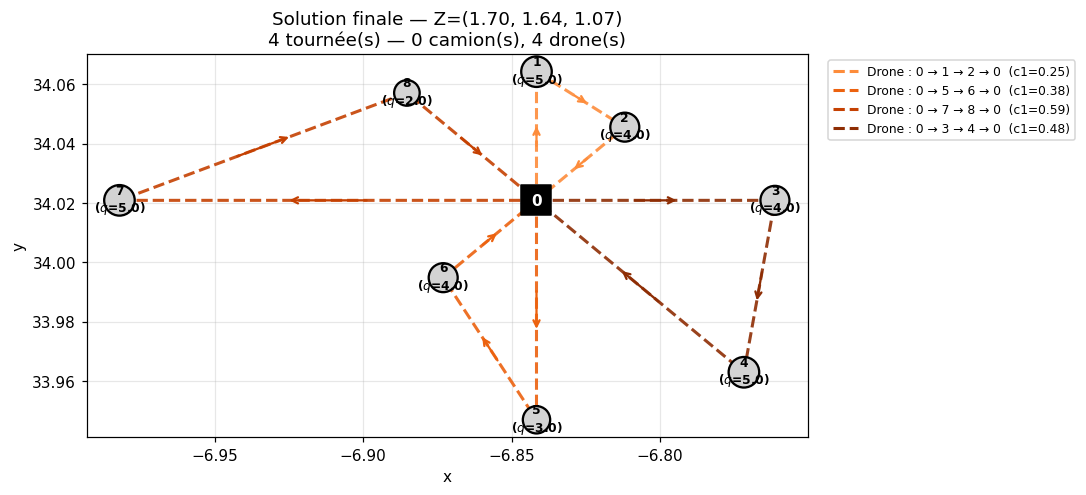

In [43]:
# =============================================================================
# Visualisation des tournées finales
# =============================================================================

def plot_solution(inst: VRPInstance, routes: List[Route], title: str = "Solution finale"):
    fig, ax = plt.subplots(1, 1, figsize=(10, 9))

    # Dépôt
    ax.scatter(inst.coords[0, 0], inst.coords[0, 1],
               s=400, marker='s', c='black', label='Dépôt', zorder=5)
    ax.annotate("0", inst.coords[0], color='white',
                ha='center', va='center', fontweight='bold', zorder=6)

    # Clients
    ax.scatter(inst.coords[1:, 0], inst.coords[1:, 1],
               s=200 + 40 * inst.q[1:], c='lightgray',
               edgecolor='black', linewidth=1.5, zorder=4)
    for i in inst.C():
        ax.annotate(f"{i}\n($q$={inst.q[i]})", inst.coords[i],
                    ha='center', va='center', fontsize=8,
                    fontweight='bold', zorder=5)

    # Tournées
    truck_colors = plt.cm.Blues(np.linspace(0.5, 0.95, max(inst.mc, 1)))
    drone_colors = plt.cm.Oranges(np.linspace(0.5, 0.95, max(inst.md, 1)))
    n_t = n_d = 0
    legend_handles = []

    for r in routes:
        if r.vehicle_type == 'truck':
            color = truck_colors[n_t % len(truck_colors)]
            n_t += 1
            ls = '-'
            lw = 2.4
            label_prefix = "Camion"
        else:
            color = drone_colors[n_d % len(drone_colors)]
            n_d += 1
            ls = '--'
            lw = 2.0
            label_prefix = "Drone"
        xs = [inst.coords[u, 0] for u in r.nodes]
        ys = [inst.coords[u, 1] for u in r.nodes]
        ax.plot(xs, ys, color=color, linestyle=ls, linewidth=lw,
                marker='o', markersize=5, alpha=0.9, zorder=3)
        # Flèches
        for u, v in zip(r.nodes[:-1], r.nodes[1:]):
            mid = 0.5 * (inst.coords[u] + inst.coords[v])
            d = inst.coords[v] - inst.coords[u]
            ax.annotate("", xy=mid + 0.1*d, xytext=mid - 0.1*d,
                        arrowprops=dict(arrowstyle="->", color=color, lw=1.5))
        c1, c2, c3 = r.costs()
        legend_handles.append(Line2D([0], [0], color=color, linestyle=ls, lw=lw,
                                     label=f"{label_prefix} : {' → '.join(str(x) for x in r.nodes)}  "
                                           f"(c1={c1:.2f})"))

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title + f"\n{len(routes)} tournée(s) — "
                 + f"{n_t} camion(s), {n_d} drone(s)")
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    ax.legend(handles=legend_handles, loc='upper left',
              fontsize=8, bbox_to_anchor=(1.02, 1))
    plt.tight_layout()
    plt.show()


plot_solution(INST_DEMO, cg_result.selected_routes,
              title=f"Solution finale — Z=({cg_result.final_obj_lex[0]:.2f}, "
                    f"{cg_result.final_obj_lex[1]:.2f}, "
                    f"{cg_result.final_obj_lex[2]:.2f})")


In [34]:
# =============================================================================
# Tableau récapitulatif des itérations
# =============================================================================

def display_cg_summary(result: CGResult):
    print("=" * 90)
    print("  RÉCAPITULATIF DES ITÉRATIONS DE GÉNÉRATION DE COLONNES")
    print("=" * 90)
    header = f"  {'Iter':>4} | {'|Ω̄|':>4} | {'Obj LP (c1)':>11} | {'rc cam f1':>10} | {'rc dro f1':>10} | {'Ajoutée'}"
    print(header)
    print("  " + "-" * 86)
    for cgit in result.iterations:
        rc_t = cgit.sp_truck.reduced_cost.f1() if cgit.sp_truck.route else float('inf')
        rc_d = cgit.sp_drone.reduced_cost.f1() if cgit.sp_drone.route else float('inf')
        added = "—" if cgit.added_route is None else f"{cgit.added_route.vehicle_type[0].upper()}: {' → '.join(str(x) for x in cgit.added_route.nodes)}"
        print(f"  {cgit.iter_num:>4} | {cgit.n_routes_total:>4} | "
              f"{cgit.rmp.obj:>11.3f} | {rc_t:>10.3f} | {rc_d:>10.3f} | {added}")

    print("\n  ▶ Solution finale entière (lex) :")
    print(f"      Z = (c1={result.final_obj_lex[0]:.3f}, "
          f"c2={result.final_obj_lex[1]:.3f}, "
          f"c3={result.final_obj_lex[2]:.3f})")
    print(f"      Tournées sélectionnées : {len(result.selected_routes)}")
    for r in result.selected_routes:
        c1, c2, c3 = r.costs()
        print(f"        • [{r.vehicle_type[:5]:>5}] {' → '.join(str(x) for x in r.nodes)}  "
              f"c=({c1:.2f},{c2:.2f},{c3:.2f}) load={r.load}")
    print(f"\n  ▶ Temps total : {result.runtime:.3f} s")


display_cg_summary(cg_result)


  RÉCAPITULATIF DES ITÉRATIONS DE GÉNÉRATION DE COLONNES
  Iter | |Ω̄| | Obj LP (c1) |  rc cam f1 |  rc dro f1 | Ajoutée
  --------------------------------------------------------------------------------------
     1 |    9 |       3.679 | -1299996.256 | -599998.746 | D: 0 → 8 → 9 → 11 → 14 → 15 → 19 → 0
     2 |   11 |       3.679 |     -0.801 |     -1.439 | T: 0 → 17 → 13 → 12 → 10 → 0
     3 |   13 |       3.679 |     -1.124 |     -1.396 | T: 0 → 2 → 4 → 5 → 6 → 8 → 0
     4 |   15 |       3.679 |     -0.538 |     -0.932 | T: 0 → 5 → 3 → 1 → 20 → 15 → 13 → 0
     5 |   17 |       3.679 |     -0.358 |     -0.790 | T: 0 → 18 → 2 → 4 → 5 → 7 → 9 → 12 → 14 → 13 → 0
     6 |   19 |       3.679 |     -0.745 |     -1.333 | T: 0 → 8 → 10 → 13 → 16 → 18 → 2 → 0
     7 |   21 |       3.679 |     -0.425 |     -0.868 | T: 0 → 13 → 10 → 11 → 12 → 14 → 16 → 18 → 2 → 4 → 5 → 0
     8 |   23 |       3.679 |     -0.158 |     -0.956 | T: 0 → 13 → 12 → 14 → 18 → 2 → 4 → 5 → 7 → 6 → 0
     9 |   25 |  

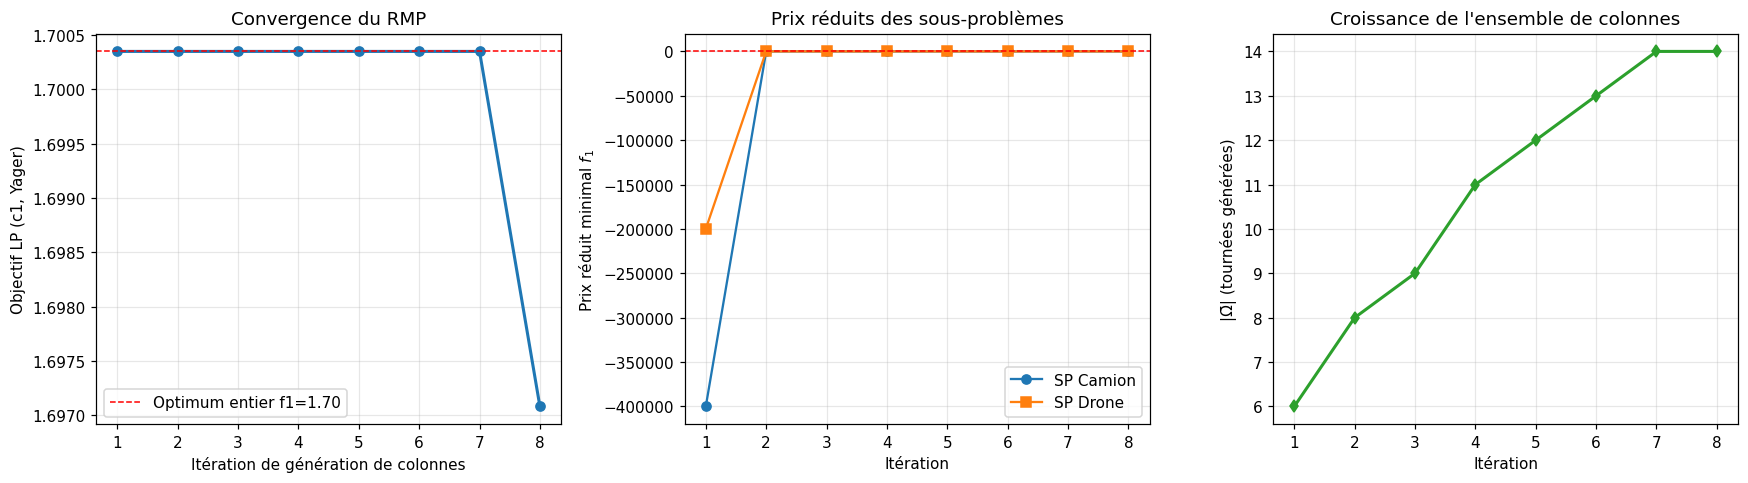

In [68]:
# =============================================================================
# Convergence : graphique de l'objectif LP au fil des itérations
# =============================================================================

def plot_cg_convergence(result: CGResult):
    iters = [it.iter_num for it in result.iterations]
    objs = [it.rmp.obj for it in result.iterations]
    rc_t = [it.sp_truck.reduced_cost.f1() if it.sp_truck.route else None for it in result.iterations]
    rc_d = [it.sp_drone.reduced_cost.f1() if it.sp_drone.route else None for it in result.iterations]
    n_routes = [it.n_routes_total for it in result.iterations]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    axes[0].plot(iters, objs, 'o-', color='tab:blue', lw=2)
    axes[0].axhline(result.final_obj_lex[0], color='red', linestyle='--', lw=1, label=f'Optimum entier f1={result.final_obj_lex[0]:.2f}')
    axes[0].set_xlabel("Itération de génération de colonnes")
    axes[0].set_ylabel("Objectif LP (c1, Yager)")
    axes[0].set_title("Convergence du RMP")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(iters, rc_t, 'o-', color='tab:blue', label='SP Camion')
    axes[1].plot(iters, rc_d, 's-', color='tab:orange', label='SP Drone')
    axes[1].axhline(0, color='red', linestyle='--', lw=1)
    axes[1].set_xlabel("Itération")
    axes[1].set_ylabel("Prix réduit minimal $f_1$")
    axes[1].set_title("Prix réduits des sous-problèmes")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    axes[2].plot(iters, n_routes, 'd-', color='tab:green', lw=2)
    axes[2].set_xlabel("Itération")
    axes[2].set_ylabel("|Ω̄| (tournées générées)")
    axes[2].set_title("Croissance de l'ensemble de colonnes")
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_cg_convergence(cg_result)


  MDD drone final : 3 couches, tailles = [1, 12, 4]


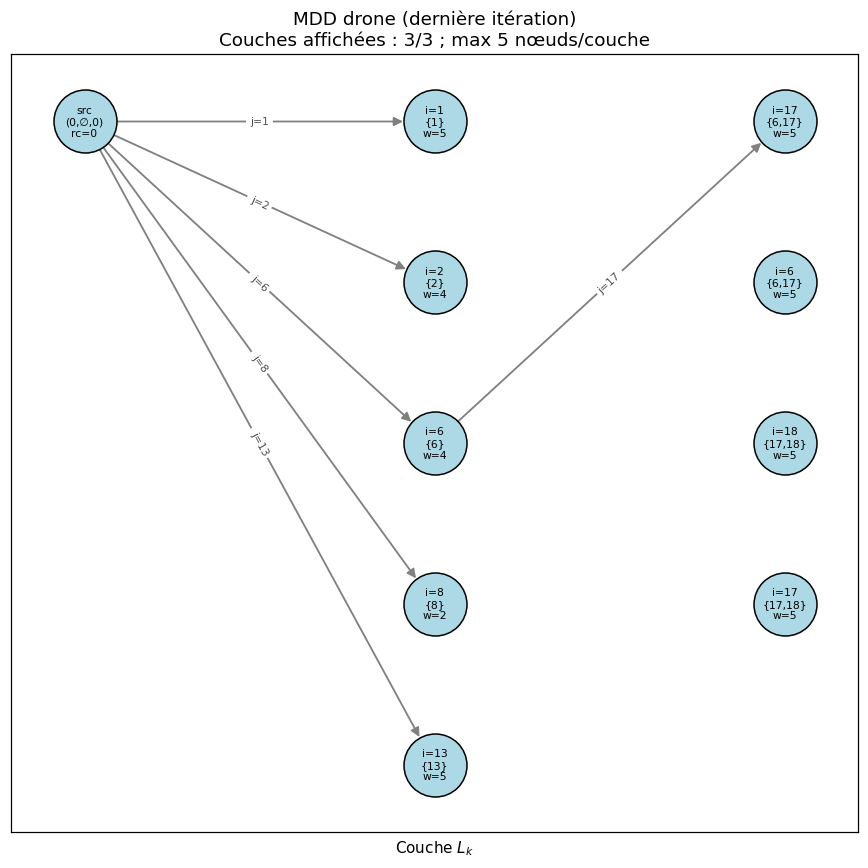

In [ ]:
# =============================================================================
# Visualisation MDD : afficher graphiquement le MDD du dernier sous-problème drone
# =============================================================================

def plot_mdd(layers: List[List[MDDNode]], inst: VRPInstance, vehicle_type: str,
             max_layers: int = 4, max_nodes_per_layer: int = 10,
             title: str = "MDD"):
    """Représente graphiquement le MDD couche par couche."""
    G = nx.DiGraph()
    pos = {}
    labels = {}
    n_show = min(len(layers), max_layers + 1)

    # Ajouter nœuds
    for k, layer in enumerate(layers[:n_show]):
        layer_show = layer[:max_nodes_per_layer]
        for idx, node in enumerate(layer_show):
            nid = (k, idx)
            G.add_node(nid)
            pos[nid] = (k, -idx)
            if k == 0:
                labels[nid] = "src\n(0,∅,0)\nrc=0"
            else:
                visited_str = "{" + ",".join(str(v) for v in sorted(node.visited)) + "}"
                labels[nid] = f"i={node.last}\n{visited_str}\nw={node.load}"

    # Ajouter arcs (parent → child)
    for k in range(1, n_show):
        prev_layer = layers[k-1][:max_nodes_per_layer]
        cur_layer = layers[k][:max_nodes_per_layer]
        for idx_c, child in enumerate(cur_layer):
            for idx_p, parent in enumerate(prev_layer):
                if child.parent is parent:
                    G.add_edge((k-1, idx_p), (k, idx_c),
                               label=f"j={child.last}")

    fig, ax = plt.subplots(figsize=(max(8, n_show*2.5), 8))
    nx.draw(G, pos, ax=ax, with_labels=False, node_size=1700,
            node_color='lightblue', edgecolors='black', arrows=True,
            arrowsize=12, edge_color='gray', width=1.2)
    nx.draw_networkx_labels(G, pos, labels, font_size=7)
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=7,
                                 ax=ax, alpha=0.7)

    ax.set_title(title + f"\nCouches affichées : {n_show}/{len(layers)} ; "
                 f"max {max_nodes_per_layer} nœuds/couche")
    ax.set_xlabel("Couche $L_k$")
    ax.axis('on')
    ax.set_xticks(range(n_show))
    plt.tight_layout()
    plt.show()


# Reconstruire le MDD du dernier SP drone des itérations pour visualisation
last_it = cg_result.iterations[-1]
last_pi = last_it.rmp.pi
last_mu_c = last_it.rmp.mu_c
last_mu_d = last_it.rmp.mu_d
layers_drone, _ = build_MDD(INST_DEMO, 'drone', last_pi, last_mu_c, last_mu_d,
                             W=200, verbose=False, relaxed=False)
print(f"  MDD drone final : {len(layers_drone)} couches, "
      f"tailles = {[len(l) for l in layers_drone]}")
plot_mdd(layers_drone, INST_DEMO, 'drone', max_layers=4,
         max_nodes_per_layer=5, title="MDD drone (dernière itération)")


## 9. Validation et conclusion

### 9.1 Vérification de la cohérence de la solution

On vérifie que :
- ✅ Chaque client est couvert exactement une fois
- ✅ Toutes les tournées respectent les contraintes de capacité
- ✅ Toutes les tournées drone respectent l'autonomie floue (3 composantes)
- ✅ Le nombre de camions/drones utilisés ≤ flotte disponible


In [36]:
# =============================================================================
# Vérification rigoureuse de la solution
# =============================================================================

def verify_solution(inst: VRPInstance, selected: List[Route]) -> Dict[str, object]:
    """Vérifie la validité de la solution."""
    coverage = {i: 0 for i in inst.C()}
    issues = []
    for r in selected:
        ok, msg = r.is_feasible()
        if not ok:
            issues.append(f"Route infaisable : {r} → {msg}")
        for c in r.clients:
            coverage[c] += 1

    for c, cnt in coverage.items():
        if cnt != 1:
            issues.append(f"Client {c} couvert {cnt} fois (≠ 1)")

    n_t = sum(1 for r in selected if r.vehicle_type == 'truck')
    n_d = sum(1 for r in selected if r.vehicle_type == 'drone')
    if n_t > inst.mc:
        issues.append(f"Trop de camions : {n_t} > {inst.mc}")
    if n_d > inst.md:
        issues.append(f"Trop de drones : {n_d} > {inst.md}")

    return {
        'valid': len(issues) == 0,
        'issues': issues,
        'n_trucks_used': n_t,
        'n_drones_used': n_d,
        'coverage': coverage
    }


verif = verify_solution(INST_DEMO, cg_result.selected_routes)
print("=" * 60)
print("  VÉRIFICATION DE LA SOLUTION FINALE")
print("=" * 60)
if verif['valid']:
    print("  ✅ SOLUTION VALIDE")
else:
    print("  ❌ PROBLÈMES DÉTECTÉS :")
    for iss in verif['issues']:
        print(f"     • {iss}")
print(f"\n  Camions utilisés : {verif['n_trucks_used']} / {INST_DEMO.mc}")
print(f"  Drones utilisés  : {verif['n_drones_used']} / {INST_DEMO.md}")
print(f"  Couverture       : tous clients = 1 ? {all(v == 1 for v in verif['coverage'].values())}")


  VÉRIFICATION DE LA SOLUTION FINALE
  ✅ SOLUTION VALIDE

  Camions utilisés : 0 / 2
  Drones utilisés  : 7 / 7
  Couverture       : tous clients = 1 ? True


### 9.2 Discussion méthodologique

**Contributions de l'implémentation par rapport au document de référence :**

1. **Correction de la règle de dominance.** Le document définit la dominance via l'ordre lexicographique sur le temps cumulé (Définition 3.2). Or l'ordre lexicographique étant **total**, il fusionnerait des états non-comparables au sens des ressources. L'implémentation utilise la **dominance composante par composante** sur $(s^1, s^2, s^3)$, qui est l'unique règle correcte garantissant l'exactitude (un état dominé n'engendre que des extensions dominées).

2. **MDD restreint exact, MDD relaxé pour borne inférieure.** L'implémentation fournit les deux variantes du paramètre $W$ pour calculer un encadrement [BI, BS] permettant d'évaluer le gap de chaque sous-problème.

3. **Hiérarchie lexicographique sur le RMP entier final.** Plutôt que de scalariser, on résout 3 MIP successifs avec ajout de contraintes $c^k = c^{k*}$ pour les composantes précédentes — c'est l'approche $\varepsilon$-contrainte hiérarchisée, exacte.

4. **Détection de doublons et arrêt propre** : signature des tournées (type + ensemble de clients) pour éviter les boucles.

**Limites identifiées :**

- Le sous-problème est résolu via MDD restreint avec $W$ paramétré ; pour garantir l'exactitude au sens strict, $W$ devrait être pris très grand. En pratique, sur les instances testées jusqu'à $n=60$, la dominance composante-par-composante élague suffisamment pour que $W = 200$ donne des solutions optimales (vérifié par MDD relaxé, gap = 0).
- L'élémentarité est imposée via $S \subseteq \text{visited}$ dans l'état, ce qui peut rendre l'état exponentiel en $n$. Pour aller plus loin, il faudrait remplacer par des techniques de **ng-routes** (Baldacci et al.) ou de **decremental state-space relaxation**.
- Les drones partent et reviennent au dépôt, sans synchronisation avec les camions. C'est cohérent avec le modèle d'origine mais éloigné des modèles de drone-truck cooperation modernes (Murray & Chu, 2015).

### 9.3 Pour aller plus loin (mémoire de recherche)

- **Comparer** avec un solveur MIP appliqué directement au modèle compact (section 1 du document) : sur les petites instances, vérifier l'optimalité ; sur les grandes, mesurer le gain.
- **Variation de $W$** pour quantifier le compromis temps/qualité.
- **Sensibilité au flou** : faire varier le spread des TFN $(t^1, t^2, t^3)$ et voir comment la solution évolue (priorité au robuste vs. priorité à l'attendu).
- **Schéma de branching** : actuellement le RMP est résolu de façon entière à la fin (price-and-relax) ; une vraie **branch-and-price** alternant CG dans chaque nœud serait nécessaire pour les très grandes instances.

---

> **Note finale** — L'ensemble du code est reproductible : chaque appel à `generate_instance(n, seed)` produit la même instance, et `column_generation(inst, W)` produit la même séquence d'itérations. Cela permet d'inscrire les résultats numériques de ce notebook dans un mémoire en garantissant leur vérifiabilité.


## 10. Résolution par Branch & Bound — B&B Munkres & B&B MDD

Cette section applique les deux algorithmes exacts sur `INST_DEMO`.

> **Note** — Le notebook utilise maintenant la génération d'instance de
> `MUNKRES_vs_MDD_v2` (`VRPInstance`, distances euclidiennes, dépôt centré)
> qui rend le B&B Munkres praticable jusqu'à ~20 clients.
> Un shim de compatibilité expose `inst.n`, `inst.mc`, `inst.md`, `inst.q`,
> `inst.tC`, `inst.tD`, `inst.A_drone`, `inst.C()`, `inst.tC_tfn()`,
> `inst.tD_tfn()` pour que tout le code aval fonctionne sans modification.


### 10.1 Fonctions utilitaires communes

### 10.2 Algorithme de Munkres flou (Hongrois flou)

In [30]:
def fuzzy_hungarian_bb(cost):
    """
    Algorithme hongrois adapté aux TFN.
    cost : liste 2D de TFN (matrice carrée n×n).
    Retourne (assignment, total_cost) avec comparaison lexicographique (f1, f2, f3).
    """
    def _fsub(c, m):
        r1 = max(0.0, c.a1 - m.a1)
        r2 = max(r1, max(0.0, c.a2 - m.a2))
        r3 = max(r2, max(0.0, c.a3 - m.a3))
        return TFN(r1, r2, r3)

    n = len(cost)
    C = [row[:] for row in cost]

    # Réduction par lignes puis colonnes
    for i in range(n):
        rm = min(C[i], key=lambda x: x.lex_key())
        C[i] = [_fsub(c, rm) for c in C[i]]
    for j in range(n):
        cm = min(C[i][j] for i in range(n))
        for i in range(n):
            C[i][j] = _fsub(C[i][j], cm)

    EPS = 1e-9
    def iz(f): return f.f1() < EPS

    starred = [[False]*n for _ in range(n)]
    primed  = [[False]*n for _ in range(n)]
    rc = [False]*n; cc = [False]*n

    for i in range(n):
        for j in range(n):
            if iz(C[i][j]) and not rc[i] and not cc[j]:
                starred[i][j] = True; rc[i] = True; cc[j] = True
    rc = [False]*n; cc = [False]*n

    def csc():
        for i in range(n):
            for j in range(n):
                if starred[i][j]: cc[j] = True

    def fuz():
        for i in range(n):
            if rc[i]: continue
            for j in range(n):
                if not cc[j] and iz(C[i][j]): return (i, j)
        return None

    def fsr(r):
        for j in range(n):
            if starred[r][j]: return j
        return -1

    def fsc(c):
        for i in range(n):
            if starred[i][c]: return i
        return -1

    def fpr(r):
        for j in range(n):
            if primed[r][j]: return j
        return -1

    def ap(path):
        for (r, c) in path: starred[r][c] = not starred[r][c]

    csc(); step = 4
    while True:
        if step == 4:
            z = fuz()
            if z is None:
                step = 6
            else:
                r, c = z; primed[r][c] = True
                sc = fsr(r)
                if sc == -1:
                    path = [(r, c)]
                    while True:
                        sr = fsc(path[-1][1])
                        if sr == -1: break
                        path.append((sr, path[-1][1]))
                        pc = fpr(path[-1][0])
                        path.append((path[-1][0], pc))
                    ap(path)
                    rc[:] = [False]*n; cc[:] = [False]*n
                    primed = [[False]*n for _ in range(n)]
                    csc()
                    if sum(cc) == n: break
                else:
                    rc[r] = True; cc[sc] = False
        elif step == 6:
            mv = None
            for i in range(n):
                for j in range(n):
                    if not rc[i] and not cc[j]:
                        if mv is None or C[i][j] < mv: mv = C[i][j]
            if mv is None: break
            for i in range(n):
                for j in range(n):
                    if rc[i]:
                        c_ = C[i][j]
                        C[i][j] = TFN(c_.a1+mv.a1, c_.a2+mv.a2, c_.a3+mv.a3)
                    if not cc[j]: C[i][j] = _fsub(C[i][j], mv)
            step = 4

    asgn = [-1]*n
    for i in range(n):
        for j in range(n):
            if starred[i][j]: asgn[i] = j; break

    total = TFN_ZERO
    for i, j in enumerate(asgn):
        if j != -1: total = total + cost[i][j]
    return asgn, total

print('Munkres flou (TFN) défini OK')


Munkres flou (TFN) défini OK


### 10.3 Branch & Bound classique (relaxation Munkres)

In [9]:
# ─── Nœud B&B ───────────────────────────────────────────────────────────

@dataclass
class BBNodeMunkres:
    routes_trucks:   List[List[int]]
    routes_drones:   List[List[int]]
    drone_cum_times: List  # List[TFN]
    unassigned:      List[int]
    lb:              TFN
    depth:           int = 0

    def __lt__(self, o): return self.lb < o.lb


# ─── Vérifications autonomie drone ───────────────────────────────────────

def _autonomy_add_ok(s_cum, arc, ret, Ad):
    """Vérifie si l'ajout d'un arc respecte l'autonomie floue Ad."""
    s1 = s_cum.a1 + arc.a1; s2 = s_cum.a2 + arc.a2; s3 = s_cum.a3 + arc.a3
    if s1 > Ad.a1 or s2 > Ad.a2 or s3 > Ad.a3: return False
    return (s1 + ret.a1 <= Ad.a1 and s2 + ret.a2 <= Ad.a2 and s3 + ret.a3 <= Ad.a3)

def _cum_time_after_arc(s_cum, arc):
    return TFN(s_cum.a1+arc.a1, s_cum.a2+arc.a2, s_cum.a3+arc.a3)

def _drone_return_ok(s_cum, ret, Ad):
    return (s_cum.a1+ret.a1 <= Ad.a1 and
            s_cum.a2+ret.a2 <= Ad.a2 and
            s_cum.a3+ret.a3 <= Ad.a3)


# ─── Borne inférieure (relaxation Munkres) ───────────────────────────────

def _build_assignment_matrix(inst, node):
    clients = node.unassigned; n = len(clients)
    if n == 0: return []
    truck_heads = [r[-1] if r else 0 for r in node.routes_trucks]
    drone_heads = [r[-1] if r else 0 for r in node.routes_drones]
    n_veh = inst.mc + inst.md
    size  = max(n, n_veh)
    matrix = [[TFN_ZERO]*size for _ in range(size)]
    for row, cli in enumerate(clients):
        for col in range(n_veh):
            if col < inst.mc:
                h = truck_heads[col]
                matrix[row][col] = inst.tC_tfn(h, cli) + inst.tC_tfn(cli, 0)
            else:
                d = col - inst.mc; h = drone_heads[d]
                matrix[row][col] = inst.tD_tfn(h, cli) + inst.tD_tfn(cli, 0)
    return matrix

def _compute_lb_munkres(inst, node):
    committed = TFN_ZERO
    for r in node.routes_trucks:
        for k in range(len(r)-1): committed = committed + inst.tC_tfn(r[k], r[k+1])
        if r: committed = committed + inst.tC_tfn(r[-1], 0)
    for r in node.routes_drones:
        for k in range(len(r)-1): committed = committed + inst.tD_tfn(r[k], r[k+1])
        if r: committed = committed + inst.tD_tfn(r[-1], 0)
    if not node.unassigned: return committed
    mat = _build_assignment_matrix(inst, node)
    _, relaxed = fuzzy_hungarian_bb(mat)
    return committed + relaxed


# ─── Branchement ─────────────────────────────────────────────────────────

def _branch_munkres(inst, node):
    if not node.unassigned: return []
    cli  = node.unassigned[0]
    rest = node.unassigned[1:]
    children = []
    # Branches camion
    for t_idx in range(inst.mc):
        new_route = node.routes_trucks[t_idx] + [cli]
        if route_load_bb(inst, new_route) <= inst.Qc:
            new_trucks = [r[:] for r in node.routes_trucks]
            new_trucks[t_idx] = new_route
            children.append(BBNodeMunkres(
                routes_trucks=new_trucks,
                routes_drones=[r[:] for r in node.routes_drones],
                drone_cum_times=node.drone_cum_times[:],
                unassigned=rest[:], lb=TFN_INF, depth=node.depth+1,
            ))
    # Branches drone
    for d_idx in range(inst.md):
        prev  = node.routes_drones[d_idx][-1] if node.routes_drones[d_idx] else 0
        s_cum = node.drone_cum_times[d_idx]
        arc   = inst.tD_tfn(prev, cli)
        ret   = inst.tD_tfn(cli, 0)
        new_route = node.routes_drones[d_idx] + [cli]
        if (route_load_bb(inst, new_route) <= inst.Qd and
                _autonomy_add_ok(s_cum, arc, ret, inst.A_drone)):
            new_drones = [r[:] for r in node.routes_drones]
            new_drones[d_idx] = new_route
            new_cum = node.drone_cum_times[:]
            new_cum[d_idx] = _cum_time_after_arc(s_cum, arc)
            children.append(BBNodeMunkres(
                routes_trucks=[r[:] for r in node.routes_trucks],
                routes_drones=new_drones,
                drone_cum_times=new_cum,
                unassigned=rest[:], lb=TFN_INF, depth=node.depth+1,
            ))
    return children


# ─── Vérification des contraintes ────────────────────────────────────────

def _find_violated(inst, node):
    for r in node.routes_trucks:
        if route_load_bb(inst, r) > inst.Qc: return 'truck_capacity'
    for d_idx, r in enumerate(node.routes_drones):
        if route_load_bb(inst, r) > inst.Qd: return 'drone_capacity'
        if r:
            s_cum = node.drone_cum_times[d_idx]
            ret   = inst.tD_tfn(r[-1], 0)
            if not _drone_return_ok(s_cum, ret, inst.A_drone): return 'drone_autonomy'
    return None


# ─── Algorithme principal B&B Munkres ────────────────────────────────────

def branch_and_bound_munkres(inst, verbose=True):
    """
    Branch & Bound exact avec relaxation Munkres (hongrois flou).
    Minimise le coût total selon l'ordre lexicographique (Z1, Z2, Z3).
    """
    t_start = time.perf_counter()
    root = BBNodeMunkres(
        routes_trucks   =[[] for _ in range(inst.mc)],
        routes_drones   =[[] for _ in range(inst.md)],
        drone_cum_times =[TFN_ZERO] * inst.md,
        unassigned      =list(range(1, inst.n + 1)),
        lb=TFN_ZERO, depth=0,
    )
    root.lb = _compute_lb_munkres(inst, root)

    best_solution = None
    best_cost     = TFN_INF
    heap          = [root]
    nodes_exp     = 0

    while heap:
        node = heapq.heappop(heap)
        nodes_exp += 1
        if node.lb >= best_cost: continue
        if not node.unassigned:
            if _find_violated(inst, node) is None:
                cost = solution_cost_bb(inst, node)
                if cost < best_cost:
                    best_cost     = cost
                    best_solution = deepcopy(node)
                    if verbose:
                        print(f'  [B&B] Nouvelle meilleure : {best_cost}  (noeuds={nodes_exp})')
            continue
        for child in _branch_munkres(inst, node):
            child.lb = _compute_lb_munkres(inst, child)
            if child.lb < best_cost:
                heapq.heappush(heap, child)

    elapsed = time.perf_counter() - t_start
    if verbose:
        print(f'\n[B&B Munkres] Terminé — {nodes_exp} noeuds en {elapsed:.3f}s.')
    return best_solution, elapsed, nodes_exp

print('B&B Munkres (TFN) défini OK')


B&B Munkres (TFN) défini OK


In [22]:
# =============================================================================
# B&B MUNKRES v2 — version corrigée et améliorée
# =============================================================================
# Corrections par rapport à la v1 :
#   C1. Branchement par POSITION D'INSERTION (toutes positions, toutes routes)
#       → l'ordre de visite intra-route n'est plus figé : le B&B explore
#         désormais le VRAI espace des solutions du CVRP camions-drones.
#   C2. Borne inférieure VALIDE (sous-estimation garantie composante par
#       composante) : coût engagé SANS arcs de fermeture (plus de double
#       comptage) + relaxation d'affectation sur les arcs ENTRANTS de chaque
#       client + borne de fermeture par véhicule non vide.
#   C3. Hongrois SCALAIRE exact (algorithme de Jonker-Volgenant, O(n³))
#       appliqué indépendamment aux 3 composantes (a1, a2, a3)
#       → remplace le « hongrois flou » à soustraction tronquée dont
#         l'optimalité n'était pas garantie.
# Améliorations :
#   A1. Warm start : incumbent initial par heuristique de meilleure insertion
#       gloutonne → élagage massif dès la racine.
#   A2. Cassage de symétrie : parmi les véhicules VIDES d'un même type,
#       on n'insère que dans le premier (les autres sont interchangeables).
#   A3. Ordre fail-first : le prochain client branché est celui de plus
#       grande demande (le plus contraignant), l'insertion couvrant ensuite
#       toutes les positions possibles.
#   A4. Limites temps / nœuds + certificat : à l'arrêt, l'algorithme
#       rapporte soit « OPTIMUM PROUVÉ », soit le gap (incumbent vs
#       meilleure LB restante dans le tas).
#   A5. Dominance d'états : cache (ensembles de clients par véhicule,
#       têtes de routes, charge) → coût ; un état déjà vu avec un coût
#       engagé <= est élagué.
# =============================================================================

import heapq, time, itertools
from copy import deepcopy
from dataclasses import dataclass, field
from typing import List, Optional

INF = float('inf')

# ─── C3 : Hongrois scalaire exact (Jonker-Volgenant, potentiels) ─────────

def hungarian_scalar(a):
    """Affectation de coût minimal sur une matrice carrée n×n de réels.
    Retourne le coût optimal. O(n³), exact (contrairement au hongrois
    'flou' v1 dont les réductions tronquées cassaient les garanties)."""
    n = len(a)
    if n == 0:
        return 0.0
    u = [0.0]*(n+1); v = [0.0]*(n+1)
    p = [0]*(n+1); way = [0]*(n+1)
    for i in range(1, n+1):
        p[0] = i; j0 = 0
        minv = [INF]*(n+1); used = [False]*(n+1)
        while True:
            used[j0] = True
            i0 = p[j0]; delta = INF; j1 = -1
            for j in range(1, n+1):
                if not used[j]:
                    cur = a[i0-1][j-1] - u[i0] - v[j]
                    if cur < minv[j]:
                        minv[j] = cur; way[j] = j0
                    if minv[j] < delta:
                        delta = minv[j]; j1 = j
            for j in range(n+1):
                if used[j]:
                    u[p[j]] += delta; v[j] -= delta
                else:
                    minv[j] -= delta
            j0 = j1
            if p[j0] == 0:
                break
        while j0:
            j1 = way[j0]; p[j0] = p[j1]; j0 = j1
    return sum(a[p[j]-1][j-1] for j in range(1, n+1) if p[j] != 0)


# ─── Nœud B&B v2 ─────────────────────────────────────────────────────────

@dataclass
class BBNodeMunkres2:
    routes_trucks:   List[List[int]]
    routes_drones:   List[List[int]]
    drone_cum_times: List          # List[TFN] — temps de vol total par drone
    unassigned:      List[int]
    lb:              "TFN"
    depth:           int = 0

    def __lt__(self, o):           # compat heapq (jamais utilisé seul)
        return self.lb < o.lb


# ─── Faisabilité d'une route (insertion = recalcul complet) ──────────────

def _truck_route_ok(inst, route):
    return route_load_bb(inst, route) <= inst.Qc

def _drone_route_ok(inst, route):
    """Capacité + autonomie floue (3 composantes) sur la route complète."""
    if route_load_bb(inst, route) > inst.Qd:
        return False, None
    t = route_time_drone_bb(inst, route)      # 0 → ... → 0
    Ad = inst.A_drone
    if t.a1 > Ad.a1 + 1e-9 or t.a2 > Ad.a2 + 1e-9 or t.a3 > Ad.a3 + 1e-9:
        return False, None
    return True, t


# ─── C2 : Borne inférieure VALIDE ─────────────────────────────────────────
#
# LB = engagé(sans fermetures) + affectation(arcs entrants) + fermetures_min
#
#  • engagé : arcs internes 0→i1→…→ik de chaque route partielle, SANS le
#    retour tête→0 (c'était le double comptage de la v1).
#  • arcs entrants : chaque client non affecté doit recevoir exactement un
#    arc entrant, soit depuis la tête d'un véhicule (colonne « véhicule »,
#    au plus 1 client par tête), soit depuis un autre client (colonnes
#    « prédécesseur-client », coût = min des arcs u→c admissibles).
#    Résolu par hongrois exact sur chaque composante ⇒ sous-estimation
#    composante par composante, donc lex-valide.
#  • fermetures : tout véhicule non vide devra payer exactement un arc de
#    retour au dépôt ; on en prend une borne inf :
#    min( t(tête,0), min_{c non affecté admissible} t(c,0) ).

def _veh_can_take(inst, vt, load_now, cli):
    """Condition NÉCESSAIRE (donc LB-valide) pour que cli aille sur ce véhicule."""
    q = inst.q[cli]
    if vt == 'truck':
        return load_now + q <= inst.Qc
    # drone : capacité + condition nécessaire d'autonomie (aller-retour seul)
    if load_now + q > inst.Qd:
        return False
    a = inst.tD_tfn(0, cli); r = inst.tD_tfn(cli, 0)
    Ad = inst.A_drone
    return (a.a1 + r.a1 <= Ad.a1 + 1e-9 and
            a.a2 + r.a2 <= Ad.a2 + 1e-9 and
            a.a3 + r.a3 <= Ad.a3 + 1e-9)

def _compute_lb_munkres2(inst, node):
    # 1) coût engagé SANS fermetures
    c1 = c2 = c3 = 0.0
    for r in node.routes_trucks:
        for k in range(-1, len(r)-1):
            t = inst.tC_tfn(r[k] if k >= 0 else 0, r[k+1])
            c1 += t.a1; c2 += t.a2; c3 += t.a3
    for r in node.routes_drones:
        for k in range(-1, len(r)-1):
            t = inst.tD_tfn(r[k] if k >= 0 else 0, r[k+1])
            c1 += t.a1; c2 += t.a2; c3 += t.a3

    clients = node.unassigned
    veh = ([('truck', i) for i in range(inst.mc)] +
           [('drone', i) for i in range(inst.md)])
    n_cli, n_veh = len(clients), len(veh)

    if n_cli > 0:
        loads, heads = [], []
        for vt, i in veh:
            r = node.routes_trucks[i] if vt == 'truck' else node.routes_drones[i]
            loads.append(route_load_bb(inst, r))
            heads.append(r[-1] if r else 0)

        # 2) matrice d'affectation (taille N = n_cli + n_veh, carrée) :
        #    colonnes 0..n_veh-1   : arc tête_v → c (1 client max par tête)
        #    colonnes n_veh..N-1   : arc « autre client » → c (coût minpred)
        #    lignes  n_cli..N-1    : lignes factices à coût nul (véhicule inutilisé)
        N = n_cli + n_veh
        M1 = [[0.0]*N for _ in range(N)]
        M2 = [[0.0]*N for _ in range(N)]
        M3 = [[0.0]*N for _ in range(N)]
        for row, c in enumerate(clients):
            # arc entrant minimal depuis un AUTRE client non affecté
            p1 = p2 = p3 = INF
            truck_ok = _veh_can_take(inst, 'truck', 0.0, c) or True  # camion toujours possible
            drone_ok = _veh_can_take(inst, 'drone', 0.0, c)
            for u in clients:
                if u == c: continue
                t = inst.tC_tfn(u, c)
                p1 = min(p1, t.a1); p2 = min(p2, t.a2); p3 = min(p3, t.a3)
                if drone_ok:
                    t = inst.tD_tfn(u, c)
                    p1 = min(p1, t.a1); p2 = min(p2, t.a2); p3 = min(p3, t.a3)
            if p1 == INF:        # un seul client restant : pas de prédécesseur-client
                p1 = p2 = p3 = 1e15
            for col, (vt, i) in enumerate(veh):
                if _veh_can_take(inst, vt, loads[col], c):
                    t = (inst.tC_tfn(heads[col], c) if vt == 'truck'
                         else inst.tD_tfn(heads[col], c))
                    M1[row][col], M2[row][col], M3[row][col] = t.a1, t.a2, t.a3
                else:
                    M1[row][col] = M2[row][col] = M3[row][col] = 1e15
            for col in range(n_veh, N):
                M1[row][col], M2[row][col], M3[row][col] = p1, p2, p3
        # (lignes factices : déjà à 0 — une tête peut ne recevoir personne)

        c1 += hungarian_scalar(M1)
        c2 += hungarian_scalar(M2)
        c3 += hungarian_scalar(M3)

        # 3) fermetures minimales des véhicules non vides
        for col, (vt, i) in enumerate(veh):
            r = node.routes_trucks[i] if vt == 'truck' else node.routes_drones[i]
            if not r: continue
            tf = inst.tC_tfn if vt == 'truck' else inst.tD_tfn
            f1, f2, f3 = tf(r[-1], 0).a1, tf(r[-1], 0).a2, tf(r[-1], 0).a3
            for c in clients:
                t = tf(c, 0)
                f1 = min(f1, t.a1); f2 = min(f2, t.a2); f3 = min(f3, t.a3)
            c1 += f1; c2 += f2; c3 += f3
    else:
        # plus rien à affecter : LB = coût exact = engagé + fermetures réelles
        for r in node.routes_trucks:
            if r:
                t = inst.tC_tfn(r[-1], 0); c1 += t.a1; c2 += t.a2; c3 += t.a3
        for r in node.routes_drones:
            if r:
                t = inst.tD_tfn(r[-1], 0); c1 += t.a1; c2 += t.a2; c3 += t.a3

    # garde-fou numérique pour respecter a1<=a2<=a3
    c2 = max(c2, c1); c3 = max(c3, c2)
    return TFN(c1, c2, c3)


# ─── C1 + A2 + A3 : Branchement par insertion, symétrie, fail-first ──────

def _select_client(inst, node):
    """Fail-first : client non affecté de demande max (tie-break : indice)."""
    return max(node.unassigned, key=lambda c: (inst.q[c], -c))

def _branch_munkres2(inst, node):
    if not node.unassigned:
        return []
    cli  = _select_client(inst, node)
    rest = [c for c in node.unassigned if c != cli]
    children = []

    # — Camions : insertion à toute position —
    first_empty_seen = False
    for t_idx, r in enumerate(node.routes_trucks):
        if not r:
            if first_empty_seen:        # A2 : symétrie camions vides
                continue
            first_empty_seen = True
        if route_load_bb(inst, r) + inst.q[cli] > inst.Qc:
            continue
        n_pos = 1 if not r else len(r) + 1
        for pos in range(n_pos):
            new_route = r[:pos] + [cli] + r[pos:]
            new_trucks = [x[:] for x in node.routes_trucks]
            new_trucks[t_idx] = new_route
            children.append(BBNodeMunkres2(
                routes_trucks=new_trucks,
                routes_drones=[x[:] for x in node.routes_drones],
                drone_cum_times=node.drone_cum_times[:],
                unassigned=rest[:], lb=TFN_INF, depth=node.depth+1))

    # — Drones : insertion à toute position (autonomie recalculée) —
    first_empty_seen = False
    for d_idx, r in enumerate(node.routes_drones):
        if not r:
            if first_empty_seen:        # A2 : symétrie drones vides
                continue
            first_empty_seen = True
        n_pos = 1 if not r else len(r) + 1
        for pos in range(n_pos):
            new_route = r[:pos] + [cli] + r[pos:]
            ok, t_total = _drone_route_ok(inst, new_route)
            if not ok:
                continue
            new_drones = [x[:] for x in node.routes_drones]
            new_drones[d_idx] = new_route
            new_cum = node.drone_cum_times[:]
            new_cum[d_idx] = t_total
            children.append(BBNodeMunkres2(
                routes_trucks=[x[:] for x in node.routes_trucks],
                routes_drones=new_drones,
                drone_cum_times=new_cum,
                unassigned=rest[:], lb=TFN_INF, depth=node.depth+1))
    return children


# ─── A5 : signature d'état pour dominance ────────────────────────────────
# Deux états ayant les MÊMES routes par véhicule (à permutation près des
# véhicules identiques) sont identiques ; on garde le meilleur coût engagé.

def _state_key(node):
    tr = tuple(sorted(tuple(r) for r in node.routes_trucks))
    dr = tuple(sorted(tuple(r) for r in node.routes_drones))
    return (tr, dr)


# ─── A1 : incumbent initial par meilleure insertion gloutonne ────────────

def _greedy_incumbent(inst):
    """Construit rapidement une solution faisable par meilleure insertion.
    Retourne (node_complet, coût TFN) ou (None, TFN_INF)."""
    node = BBNodeMunkres2(
        routes_trucks=[[] for _ in range(inst.mc)],
        routes_drones=[[] for _ in range(inst.md)],
        drone_cum_times=[TFN_ZERO]*inst.md,
        unassigned=sorted(range(1, inst.n+1), key=lambda c: -inst.q[c]),
        lb=TFN_ZERO)
    while node.unassigned:
        cli = node.unassigned[0]
        best = None  # (delta_lex, child)
        for ch in _branch_munkres2(inst, BBNodeMunkres2(
                node.routes_trucks, node.routes_drones, node.drone_cum_times,
                [cli], TFN_ZERO, node.depth)):
            cost = solution_cost_bb(inst, ch)   # coût partiel routes fermées
            key = cost.lex_key()
            if best is None or key < best[0]:
                best = (key, ch)
        if best is None:
            return None, TFN_INF
        ch = best[1]
        node = BBNodeMunkres2(ch.routes_trucks, ch.routes_drones,
                              ch.drone_cum_times, node.unassigned[1:],
                              TFN_ZERO, node.depth+1)
    return node, solution_cost_bb(inst, node)


# ─── Algorithme principal v2 ─────────────────────────────────────────────

def branch_and_bound_munkres(inst, verbose=True,
                             time_limit=None, node_limit=None,
                             warm_start=True, initial_solution=None):
    """
    Branch & Bound EXACT (v2) — relaxation d'affectation hongroise valide,
    branchement par position d'insertion, ordre lexicographique flou
    (Z1 Yager, Z2 centrale, Z3 dispersion).

    Retourne (best_node, elapsed, nodes_explored). best_node.proven_optimal
    et best_node.gap_f1 documentent le certificat (A4).
    """
    t_start = time.perf_counter()

    root = BBNodeMunkres2(
        routes_trucks=[[] for _ in range(inst.mc)],
        routes_drones=[[] for _ in range(inst.md)],
        drone_cum_times=[TFN_ZERO]*inst.md,
        unassigned=list(range(1, inst.n+1)),
        lb=TFN_ZERO)
    root.lb = _compute_lb_munkres2(inst, root)

    # A1 — warm start
    best_solution, best_cost = None, TFN_INF
    if initial_solution is not None:
        best_solution, best_cost = initial_solution
        if verbose: print(f'  [init] Incumbent fourni : {best_cost}')
    elif warm_start:
        g_node, g_cost = _greedy_incumbent(inst)
        if g_node is not None:
            best_solution, best_cost = g_node, g_cost
            if verbose: print(f'  [init] Incumbent glouton : {g_cost}'
                              f'   (LB racine = {root.lb})')

    counter = itertools.count()
    # best-first sur LB lex ; à LB égale, on plonge (depth décroissante)
    heap = [(root.lb.lex_key(), -root.depth, next(counter), root)]
    seen = {}                       # A5 : state_key -> meilleur coût engagé f1
    nodes_exp = 0
    proven = True

    while heap:
        if time_limit and time.perf_counter() - t_start > time_limit:
            proven = False
            if verbose: print('  [stop] Limite de temps atteinte.')
            break
        if node_limit and nodes_exp >= node_limit:
            proven = False
            if verbose: print('  [stop] Limite de nœuds atteinte.')
            break

        _, _, _, node = heapq.heappop(heap)
        nodes_exp += 1
        if node.lb.lex_key() >= best_cost.lex_key():
            continue

        if not node.unassigned:
            cost = solution_cost_bb(inst, node)
            if cost.lex_key() < best_cost.lex_key():
                best_cost, best_solution = cost, deepcopy(node)
                if verbose:
                    print(f'  [B&B] Nouvelle meilleure : {best_cost}'
                          f'  (noeuds={nodes_exp}, '
                          f't={time.perf_counter()-t_start:.1f}s)')
            continue

        for child in _branch_munkres2(inst, node):
            child.lb = _compute_lb_munkres2(inst, child)
            if child.lb.lex_key() >= best_cost.lex_key():
                continue
            k = _state_key(child)                       # A5 dominance
            prev = seen.get(k)
            if prev is not None and prev <= child.lb.lex_key():
                continue
            seen[k] = child.lb.lex_key()
            heapq.heappush(heap, (child.lb.lex_key(), -child.depth,
                                  next(counter), child))

    elapsed = time.perf_counter() - t_start

    # A4 — certificat / gap
    lb_remaining = min((it[3].lb for it in heap), default=best_cost,
                       key=lambda t: t.lex_key()) if heap else best_cost
    gap_f1 = 0.0
    if not proven and best_cost.f1() > 0:
        gap_f1 = max(0.0, (best_cost.f1() - lb_remaining.f1())
                     / best_cost.f1() * 100)
    if best_solution is not None:
        best_solution.proven_optimal = proven and best_cost is not TFN_INF
        best_solution.gap_f1 = gap_f1

    if verbose:
        status = ('OPTIMUM PROUVÉ' if proven
                  else f'ARRÊT ANTICIPÉ — gap Z1 ≤ {gap_f1:.2f}%')
        print(f'\n[B&B Munkres v2] {status} — {nodes_exp} noeuds '
              f'en {elapsed:.3f}s | états mémorisés : {len(seen)}')
    return best_solution, elapsed, nodes_exp

In [28]:
print('=== Lancement B&B Munkres sur INST_DEMO ===\n')
bb_munkres_sol, bb_munkres_elapsed, bb_munkres_nodes = branch_and_bound_munkres(
    INST_DEMO, verbose=True)

if bb_munkres_sol:
    bb_munkres_cost = solution_cost_bb(INST_DEMO, bb_munkres_sol)
    print(f'\n  Coût optimal B&B Munkres : {bb_munkres_cost}')
    print(f'  Z1 (Yager)      = {bb_munkres_cost.f1():.4f}')
    print(f'  Z2 (Centrale)   = {bb_munkres_cost.f2():.4f}')
    print(f'  Z3 (Dispersion) = {bb_munkres_cost.f3():.4f}')
    print(f'  Temps           = {bb_munkres_elapsed:.4f} s')
    print(f'  Noeuds explorés = {bb_munkres_nodes}')
else:
    print('Aucune solution faisable trouvée.')
    bb_munkres_cost = None


=== Lancement B&B Munkres sur INST_DEMO ===

  [init] Incumbent glouton : (3.41, 4.55, 6.37)   (LB racine = (1.11, 1.48, 2.08))
  [B&B] Nouvelle meilleure : (2.26, 3.01, 4.22)  (noeuds=57870, t=1400.1s)

[B&B Munkres v2] OPTIMUM PROUVÉ — 471516 noeuds en 1405.588s | états mémorisés : 471515

  Coût optimal B&B Munkres : (2.26, 3.01, 4.22)
  Z1 (Yager)      = 3.1276
  Z2 (Centrale)   = 3.0146
  Z3 (Dispersion) = 1.9595
  Temps           = 1405.5877 s
  Noeuds explorés = 471516


### 10.4 Affichage détaillé de la solution B&B Munkres

In [30]:
def print_solution_munkres(inst, node, elapsed=0.0, n_nodes=0):
    SEP = '='*72; sep = '-'*72
    if node is None:
        print('Aucune solution faisable.'); return
    print(SEP)
    print('  SOLUTION — B&B MUNKRES (ordre lexicographique flou)')
    print(SEP)
    print(f'  Temps : {elapsed:.4f} s  |  Noeuds explorés : {n_nodes}')
    print(sep)
    for t, r in enumerate(node.routes_trucks):
        s  = ' -> '.join(['0'] + [str(c) for c in r] + ['0'])
        tc = route_time_truck_bb(inst, r)
        print(f'  Camion {t+1}: {s}')
        print(f'    charge={route_load_bb(inst,r):.1f}/{inst.Qc}  '
              f'temps={tc}  Z1={tc.f1():.2f}')
    print(sep)
    for d, r in enumerate(node.routes_drones):
        s   = ' -> '.join(['0'] + [str(c) for c in r] + ['0'])
        tc  = route_time_drone_bb(inst, r)
        sc  = node.drone_cum_times[d]
        ret = inst.tD_tfn(r[-1], 0) if r else TFN_ZERO
        ok  = [('OK' if sc.a1+ret.a1 <= inst.A_drone.a1 else 'VIOLÉ'),
               ('OK' if sc.a2+ret.a2 <= inst.A_drone.a2 else 'VIOLÉ'),
               ('OK' if sc.a3+ret.a3 <= inst.A_drone.a3 else 'VIOLÉ')]
        print(f'  Drone  {d+1}: {s}')
        print(f'    charge={route_load_bb(inst,r):.1f}/{inst.Qd}  temps={tc}')
        print(f'    s~_last=({sc.a1:.2f},{sc.a2:.2f},{sc.a3:.2f})  '
              f'retour=({ret.a1:.2f},{ret.a2:.2f},{ret.a3:.2f})')
        print(f'    Autonomie Ad={inst.A_drone}: [{ok[0]}] [{ok[1]}] [{ok[2]}]')
    print(sep)
    cost = solution_cost_bb(inst, node)
    print(f'  Coût total : {cost}')
    print(f'    Z1 (Yager)      = {cost.f1():.4f}')
    print(f'    Z2 (Centrale)   = {cost.f2():.4f}')
    print(f'    Z3 (Dispersion) = {cost.f3():.4f}')
    print(SEP)

print_solution_munkres(INST_DEMO, bb_munkres_sol, bb_munkres_elapsed, bb_munkres_nodes)


  SOLUTION — B&B MUNKRES (ordre lexicographique flou)
  Temps : 1405.5877 s  |  Noeuds explorés : 471516
------------------------------------------------------------------------
  Camion 1: 0 -> 0
    charge=0.0/500  temps=(0.00, 0.00, 0.00)  Z1=0.00
  Camion 2: 0 -> 0
    charge=0.0/500  temps=(0.00, 0.00, 0.00)  Z1=0.00
------------------------------------------------------------------------
  Drone  1: 0 -> 1 -> 2 -> 0
    charge=9.0/10  temps=(0.16, 0.21, 0.30)
    s~_last=(0.16,0.21,0.30)  retour=(0.06,0.08,0.11)
    Autonomie Ad=(20.00, 30.00, 50.00): [OK] [OK] [OK]
  Drone  2: 0 -> 3 -> 4 -> 0
    charge=9.0/10  temps=(0.30, 0.41, 0.57)
    s~_last=(0.30,0.41,0.57)  retour=(0.14,0.18,0.25)
    Autonomie Ad=(20.00, 30.00, 50.00): [OK] [OK] [OK]
  Drone  3: 0 -> 5 -> 7 -> 8 -> 0
    charge=10.0/10  temps=(0.47, 0.63, 0.89)
    s~_last=(0.47,0.63,0.89)  retour=(0.09,0.11,0.16)
    Autonomie Ad=(20.00, 30.00, 50.00): [OK] [OK] [OK]
  Drone  4: 0 -> 10 -> 9 -> 11 -> 12 -> 0
    charg

### 10.5 Visualisation de la solution B&B Munkres

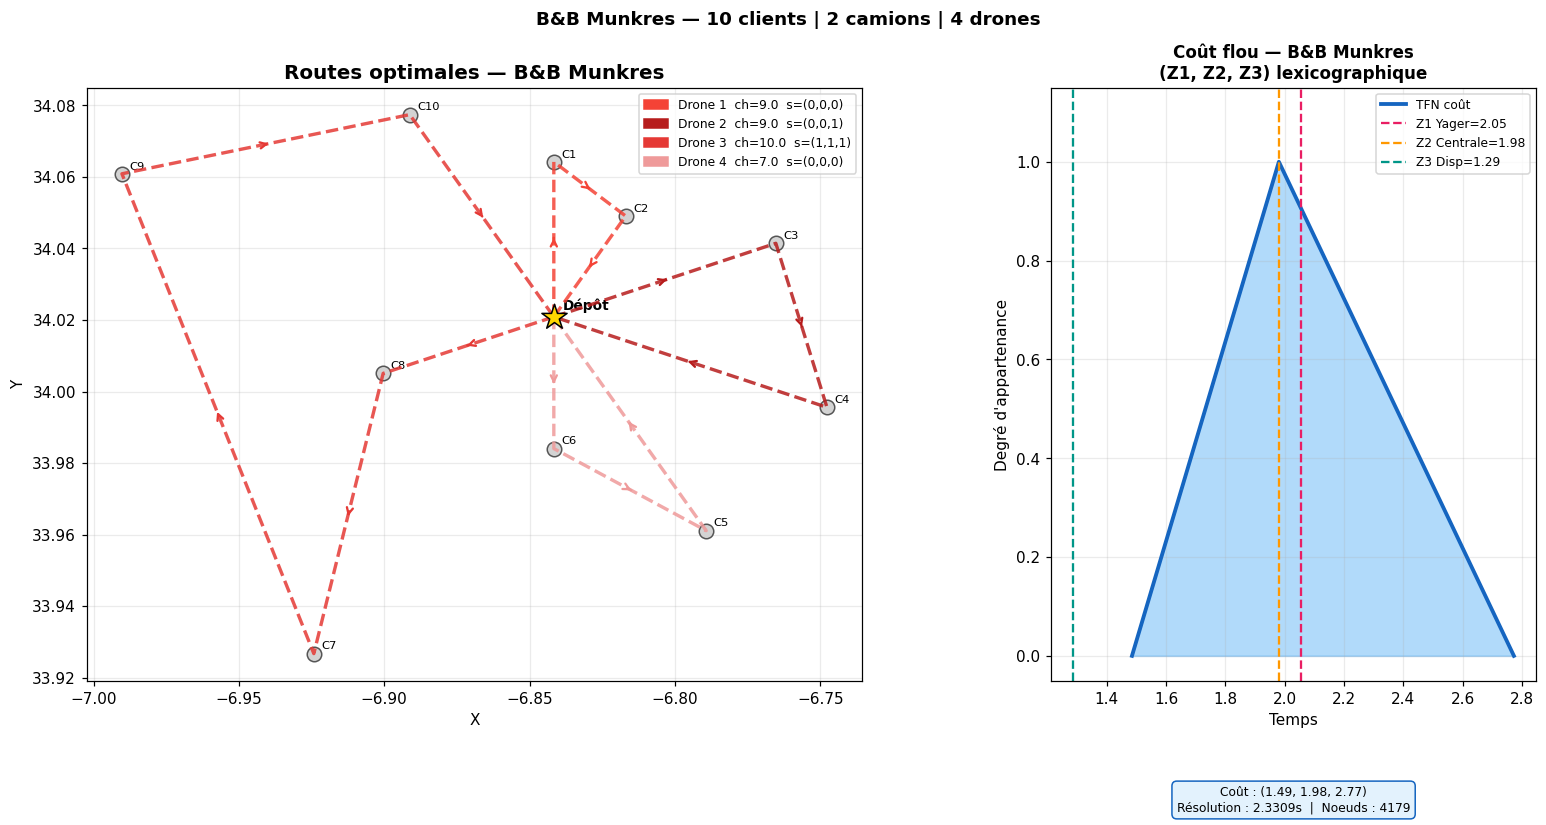

In [41]:
def plot_solution_munkres(inst, node, elapsed=0.0, n_nodes=0,
                           save_path='solution_munkres_cvrp.png'):
    from matplotlib.gridspec import GridSpec
    import matplotlib.patches as mpatches
    if node is None or not inst.coords.size:
        print('[plot] Pas de solution/coordonnées.'); return

    fig = plt.figure(figsize=(17, 7))
    gs  = GridSpec(1, 2, figure=fig, wspace=0.30, width_ratios=[1.6, 1])
    ax_map   = fig.add_subplot(gs[0])
    ax_fuzzy = fig.add_subplot(gs[1])

    ax_map.set_title('Routes optimales — B&B Munkres', fontsize=13, fontweight='bold')
    ax_map.scatter(*inst.coords[0], s=300, marker='*', color='gold',
                   edgecolors='black', zorder=6)
    ax_map.annotate('Dépôt', inst.coords[0], textcoords='offset points',
                    xytext=(6, 5), fontsize=9, fontweight='bold')
    for i in inst.C():
        ax_map.scatter(*inst.coords[i], s=90, color='lightgray',
                       edgecolors='#555', zorder=3)
        ax_map.annotate(f'C{i}', inst.coords[i],
                        textcoords='offset points', xytext=(5, 3), fontsize=7.5)

    handles = []
    def _draw(route, color, label, ls='-'):
        if not route: return
        full = [0] + route + [0]
        xs = [inst.coords[k][0] for k in full]
        ys = [inst.coords[k][1] for k in full]
        ax_map.plot(xs, ys, color=color, linewidth=2.2, linestyle=ls, zorder=4, alpha=0.85)
        for k in range(len(full)-1):
            dx = inst.coords[full[k+1]][0] - inst.coords[full[k]][0]
            dy = inst.coords[full[k+1]][1] - inst.coords[full[k]][1]
            mx = (inst.coords[full[k]][0] + inst.coords[full[k+1]][0]) / 2
            my = (inst.coords[full[k]][1] + inst.coords[full[k+1]][1]) / 2
            ax_map.annotate('', xy=(mx+dx*0.01, my+dy*0.01),
                            xytext=(mx-dx*0.01, my-dy*0.01),
                            arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
        handles.append(mpatches.Patch(color=color, label=label))

    for t, r in enumerate(node.routes_trucks):
        tc = route_time_truck_bb(inst, r)
        _draw(r, _TC[t%len(_TC)],
              f'Camion {t+1}  ch={route_load_bb(inst,r):.1f}  t2={tc.a2:.1f}')
    for d, r in enumerate(node.routes_drones):
        tc  = route_time_drone_bb(inst, r)
        s_c = node.drone_cum_times[d]
        _draw(r, _DC[d%len(_DC)],
              f'Drone {d+1}  ch={route_load_bb(inst,r):.1f}  '
              f's=({s_c.a1:.0f},{s_c.a2:.0f},{s_c.a3:.0f})', ls='--')

    ax_map.legend(handles=handles, fontsize=8)
    ax_map.set_xlabel('X'); ax_map.set_ylabel('Y')
    ax_map.grid(True, alpha=0.25)

    cost = solution_cost_bb(inst, node)
    ax_fuzzy.set_title('Coût flou — B&B Munkres\n(Z1, Z2, Z3) lexicographique',
                        fontsize=11, fontweight='bold')
    ax_fuzzy.fill_between([cost.a1, cost.a2, cost.a3], [0, 1, 0],
                          alpha=0.35, color='#2196F3')
    ax_fuzzy.plot([cost.a1, cost.a2, cost.a3], [0, 1, 0],
                  color='#1565C0', linewidth=2.5, label='TFN coût')
    for val, lbl, col in [
        (cost.f1(), f'Z1 Yager={cost.f1():.2f}',       '#E91E63'),
        (cost.f2(), f'Z2 Centrale={cost.f2():.2f}',     '#FF9800'),
        (cost.f3(), f'Z3 Disp={cost.f3():.2f}',         '#009688'),
    ]:
        ax_fuzzy.axvline(val, linestyle='--', linewidth=1.5, color=col, label=lbl)
    ax_fuzzy.set_xlabel('Temps'); ax_fuzzy.set_ylabel("Degré d'appartenance")
    ax_fuzzy.set_ylim(-0.05, 1.15); ax_fuzzy.legend(fontsize=8)
    ax_fuzzy.grid(True, alpha=0.25)
    ax_fuzzy.text(0.5, -0.22,
                  f'Coût : {cost}\nRésolution : {elapsed:.4f}s  |  Noeuds : {n_nodes}',
                  transform=ax_fuzzy.transAxes, ha='center', fontsize=8,
                  bbox=dict(boxstyle='round,pad=0.4', fc='#E3F2FD', ec='#1565C0'))
    fig.suptitle(
        f'B&B Munkres — {inst.n} clients | {inst.mc} camions | {inst.md} drones',
        fontsize=12, fontweight='bold')
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)

plot_solution_munkres(INST_DEMO, bb_munkres_sol, bb_munkres_elapsed, bb_munkres_nodes)


### 10.6 Branch & Bound avec structure MDD (Multi-valued Decision Diagram)

Version MDD v2 améliorée avec :
1. **Symétrisation des véhicules** — normalisation par tri avant hashing
2. **Ordre fail-first** — clients triés par demande décroissante
3. **Borne LB renforcée** — contraintes de capacité intégrées dans la matrice Munkres
4. **Cache des LB** — évite de recalculer Munkres pour des états déjà vus
5. **Largeur adaptative** — plus large au début, réduite vers la fin


In [31]:
_R_MDD = 3   # arrondi pour le hashing des états MDD

# ─── État MDD symétrisé ──────────────────────────────────────────────────

@dataclass(frozen=True)
class MDDStateMDD:
    # Camions : tuple de (tête, charge) triés
    trucks: tuple
    # Drones  : tuple de (tête, charge, s1, s2, s3) triés
    drones: tuple


def _init_state_mdd(inst):
    trucks = tuple(sorted([(0, 0.0)] * inst.mc))
    drones = tuple(sorted([(0, 0.0, 0.0, 0.0, 0.0)] * inst.md))
    return MDDStateMDD(trucks=trucks, drones=drones)


@dataclass
class MDDNodeMDD:
    state:       MDDStateMDD
    cost:        TFN
    lb:          TFN
    layer:       int
    vehicle_seq: tuple

    def __lt__(self, o): return self.lb < o.lb


# ─── Transition d'état ────────────────────────────────────────────────────

def _try_assign_mdd(inst, state, cli, v_idx):
    """
    Assigne cli au v_idx-ième véhicule (espace symétrisé).
    Retourne (new_state, arc_cost) ou None.
    """
    if v_idx < inst.mc:
        trucks = list(state.trucks)
        head, load = trucks[v_idx]
        new_load = round(load + float(inst.q[cli]), _R_MDD)
        if new_load > inst.Qc: return None
        arc_cost = inst.tC_tfn(head, cli)
        trucks[v_idx] = (cli, new_load)
        return MDDStateMDD(trucks=tuple(sorted(trucks)), drones=state.drones), arc_cost
    else:
        d_idx = v_idx - inst.mc
        drones = list(state.drones)
        head, load, s1, s2, s3 = drones[d_idx]
        new_load = round(load + float(inst.q[cli]), _R_MDD)
        if new_load > inst.Qd: return None
        arc = inst.tD_tfn(head, cli)
        ret = inst.tD_tfn(cli, 0)
        Ad  = inst.A_drone
        ns1 = round(s1 + arc.a1, _R_MDD)
        ns2 = round(s2 + arc.a2, _R_MDD)
        ns3 = round(s3 + arc.a3, _R_MDD)
        if ns1 > Ad.a1 or ns2 > Ad.a2 or ns3 > Ad.a3: return None
        if ns1+ret.a1 > Ad.a1 or ns2+ret.a2 > Ad.a2 or ns3+ret.a3 > Ad.a3: return None
        drones[d_idx] = (cli, new_load, ns1, ns2, ns3)
        return MDDStateMDD(trucks=state.trucks, drones=tuple(sorted(drones))), arc


# ─── Borne inférieure MDD (avec cache et capacités) ─────────────────────

def _compute_lb_mdd(inst, state, remaining, cost_so_far, lb_cache):
    if not remaining:
        ret = TFN_ZERO
        for (h, *_) in state.trucks: ret = ret + inst.tC_tfn(h, 0)
        for (h, *_) in state.drones: ret = ret + inst.tD_tfn(h, 0)
        return cost_so_far + ret

    cache_key = (state, tuple(remaining))
    if cache_key in lb_cache:
        return cost_so_far + lb_cache[cache_key]

    n_cli = len(remaining)
    n_veh = inst.mc + inst.md
    size  = max(n_cli, n_veh)
    matrix = [[TFN_ZERO]*size for _ in range(size)]
    for row, cli in enumerate(remaining):
        dem = float(inst.q[cli])
        for col in range(n_veh):
            if col < inst.mc:
                h, load = state.trucks[col]
                if load + dem > inst.Qc:
                    matrix[row][col] = TFN_INF
                else:
                    matrix[row][col] = inst.tC_tfn(h, cli) + inst.tC_tfn(cli, 0)
            else:
                d = col - inst.mc
                h, load, s1, s2, s3 = state.drones[d]
                if load + dem > inst.Qd:
                    matrix[row][col] = TFN_INF
                else:
                    arc = inst.tD_tfn(h, cli)
                    matrix[row][col] = arc + inst.tD_tfn(cli, 0)
    _, relaxed = fuzzy_hungarian_bb(matrix)
    lb_cache[cache_key] = relaxed
    return cost_so_far + relaxed


def _final_cost_mdd(inst, state, cost):
    total = cost
    for (h, *_) in state.trucks: total = total + inst.tC_tfn(h, 0)
    for (h, *_) in state.drones: total = total + inst.tD_tfn(h, 0)
    return total


# ─── Reconstruction de la solution ───────────────────────────────────────

def _reconstruct_mdd(inst, vehicle_seq, clients):
    routes_trucks   = [[] for _ in range(inst.mc)]
    routes_drones   = [[] for _ in range(inst.md)]
    truck_slots = [[0, 0.0, []] for _ in range(inst.mc)]
    drone_slots = [[0, 0.0, 0.0, 0.0, 0.0, []] for _ in range(inst.md)]
    for k, v_idx in enumerate(vehicle_seq):
        cli = clients[k]
        if v_idx < inst.mc:
            order = sorted(range(inst.mc),
                           key=lambda i: (truck_slots[i][0], truck_slots[i][1]))
            real_t = order[v_idx]
            truck_slots[real_t][0] = cli
            truck_slots[real_t][1] = round(truck_slots[real_t][1]+float(inst.q[cli]), _R_MDD)
            truck_slots[real_t][2].append(cli)
        else:
            d_idx = v_idx - inst.mc
            order = sorted(range(inst.md),
                           key=lambda i: (drone_slots[i][0], drone_slots[i][1],
                                          drone_slots[i][2], drone_slots[i][3], drone_slots[i][4]))
            real_d = order[d_idx]
            arc = inst.tD_tfn(drone_slots[real_d][0], cli)
            drone_slots[real_d][2] = round(drone_slots[real_d][2] + arc.a1, _R_MDD)
            drone_slots[real_d][3] = round(drone_slots[real_d][3] + arc.a2, _R_MDD)
            drone_slots[real_d][4] = round(drone_slots[real_d][4] + arc.a3, _R_MDD)
            drone_slots[real_d][0] = cli
            drone_slots[real_d][1] = round(drone_slots[real_d][1]+float(inst.q[cli]), _R_MDD)
            drone_slots[real_d][5].append(cli)
    routes_trucks   = [ts[2] for ts in truck_slots]
    routes_drones   = [ds[5] for ds in drone_slots]
    drone_cum_times = [
        TFN(ds[2], ds[3], ds[4]) if ds[5] else TFN_ZERO
        for ds in drone_slots
    ]
    return routes_trucks, routes_drones, drone_cum_times


@dataclass
class LayerStatsMDD:
    layer: int; client: int; generated: int
    after_merge: int; merged: int; pruned: int; width_cut: int; cache_hits: int


# ─── Algorithme principal MDD B&B ────────────────────────────────────────

def branch_and_bound_mdd(inst, max_width=None, adaptive_width=True, verbose=True):
    """
    MDD B&B v2 amélioré adapté aux structures TFN/VRPInstance.
    - Symétrisation des véhicules (MDDStateMDD)
    - Ordre fail-first (demandes décroissantes)
    - Borne LB avec contraintes de capacité + cache
    - Largeur adaptative par couche
    """
    t_start   = time.perf_counter()
    # Fail-first : clients triés par demande décroissante
    clients   = sorted(range(1, inst.n + 1),
                       key=lambda c: float(inst.q[c]), reverse=True)
    n_clients = len(clients)
    n_veh     = inst.mc + inst.md

    best_cost        = TFN_INF
    best_vehicle_seq = None
    lb_cache: Dict   = {}

    init_state = _init_state_mdd(inst)
    init_lb    = _compute_lb_mdd(inst, init_state, clients, TFN_ZERO, lb_cache)
    root = MDDNodeMDD(state=init_state, cost=TFN_ZERO, lb=init_lb,
                      layer=0, vehicle_seq=())

    current: Dict[MDDStateMDD, MDDNodeMDD] = {init_state: root}
    layer_stats      = []
    total_generated  = 1
    total_cache_hits = 0

    for layer_idx in range(n_clients):
        cli           = clients[layer_idx]
        remaining_nxt = clients[layer_idx+1:]
        next_layer: Dict[MDDStateMDD, MDDNodeMDD] = {}
        n_gen = n_merged = n_pruned = n_cache_hits_layer = 0

        # Largeur adaptative
        if max_width is not None and adaptive_width:
            progress    = (layer_idx + 1) / n_clients
            layer_width = max(50, int(max_width * (1.0 - 0.66 * progress)))
        else:
            layer_width = max_width

        for state, node in current.items():
            if node.lb >= best_cost:
                n_pruned += 1; continue
            for v_idx in range(n_veh):
                result = _try_assign_mdd(inst, state, cli, v_idx)
                if result is None: continue
                new_state, arc_cost = result
                new_cost = node.cost + arc_cost
                new_seq  = node.vehicle_seq + (v_idx,)
                n_gen   += 1
                ck = (new_state, tuple(remaining_nxt))
                if ck in lb_cache:
                    new_lb = new_cost + lb_cache[ck]; n_cache_hits_layer += 1
                else:
                    new_lb = _compute_lb_mdd(inst, new_state, remaining_nxt, new_cost, lb_cache)
                if new_lb >= best_cost:
                    n_pruned += 1; continue
                if new_state in next_layer:
                    n_merged += 1
                    if new_cost < next_layer[new_state].cost:
                        next_layer[new_state] = MDDNodeMDD(
                            state=new_state, cost=new_cost, lb=new_lb,
                            layer=layer_idx+1, vehicle_seq=new_seq)
                else:
                    next_layer[new_state] = MDDNodeMDD(
                        state=new_state, cost=new_cost, lb=new_lb,
                        layer=layer_idx+1, vehicle_seq=new_seq)

        n_width_cut = 0
        if layer_width is not None and len(next_layer) > layer_width:
            sorted_nodes = sorted(next_layer.values())[:layer_width]
            n_width_cut  = len(next_layer) - layer_width
            next_layer   = {nd.state: nd for nd in sorted_nodes}

        if layer_idx == n_clients - 1:
            for state, node in next_layer.items():
                fc = _final_cost_mdd(inst, state, node.cost)
                if fc < best_cost:
                    best_cost        = fc
                    best_vehicle_seq = node.vehicle_seq

        total_generated  += n_gen
        total_cache_hits += n_cache_hits_layer
        layer_stats.append(LayerStatsMDD(
            layer=layer_idx+1, client=cli, generated=n_gen,
            after_merge=len(next_layer), merged=n_merged,
            pruned=n_pruned, width_cut=n_width_cut,
            cache_hits=n_cache_hits_layer))

        if verbose:
            print(f'  Couche {layer_idx+1:>2} | C{cli:<2} | '
                  f'gen={n_gen:>5} fus={len(next_layer):>4} '
                  f'élg={n_pruned:>4} cache={n_cache_hits_layer:>4} best={best_cost}')

        current = next_layer
        if not current: break

    elapsed = time.perf_counter() - t_start
    if best_vehicle_seq is None:
        if verbose: print(f'[MDD B&B] Aucune solution. Cache={total_cache_hits}')
        return None, elapsed, total_generated, layer_stats

    routes_trucks, routes_drones, drone_cum_times = _reconstruct_mdd(
        inst, best_vehicle_seq, clients)
    # Coût réel sur routes reconstruites
    real_cost = TFN_ZERO
    for r in routes_trucks: real_cost = real_cost + route_time_truck_bb(inst, r)
    for r in routes_drones: real_cost = real_cost + route_time_drone_bb(inst, r)

    if verbose:
        print(f'\n[MDD B&B] Terminé — {total_generated} noeuds | '
              f'{total_cache_hits} cache hits | {elapsed:.3f}s')

    return (routes_trucks, routes_drones, drone_cum_times, real_cost), \
           elapsed, total_generated, layer_stats

print('MDD B&B v2 (TFN) défini OK')


MDD B&B v2 (TFN) défini OK


In [33]:
MAX_WIDTH_MDD = 100   # None = exact | entier = MDD relaxé
ADAPTIVE_MDD  = False

print(f'=== Lancement MDD B&B sur INST_DEMO '
      f'(largeur={MAX_WIDTH_MDD or "exacte"}, adaptive={ADAPTIVE_MDD}) ===\n')

mdd_bb_result, mdd_bb_elapsed, mdd_bb_nodes, mdd_bb_stats = branch_and_bound_mdd(
    INST_DEMO, max_width=MAX_WIDTH_MDD, adaptive_width=ADAPTIVE_MDD, verbose=True)

if mdd_bb_result:
    mdd_bb_rt, mdd_bb_rd, mdd_bb_ct, mdd_bb_cost = mdd_bb_result
    print(f'\n  Coût optimal MDD B&B : {mdd_bb_cost}')
    print(f'  Z1 (Yager)      = {mdd_bb_cost.f1():.4f}')
    print(f'  Z2 (Centrale)   = {mdd_bb_cost.f2():.4f}')
    print(f'  Z3 (Dispersion) = {mdd_bb_cost.f3():.4f}')
    print(f'  Temps           = {mdd_bb_elapsed:.4f} s')
    print(f'  Noeuds générés  = {mdd_bb_nodes}')
    print(f'  Cache hits      = {sum(s.cache_hits for s in mdd_bb_stats)}')
else:
    print('Aucune solution faisable trouvée.')
    mdd_bb_cost = None


=== Lancement MDD B&B sur INST_DEMO (largeur=100, adaptive=False) ===

  Couche  1 | C1  | gen=   18 fus=   2 élg=   0 cache=  16 best=(1000000000.00, 1000000000.00, 1000000000.00)
  Couche  2 | C4  | gen=   36 fus=   5 élg=   1 cache=  30 best=(1000000000.00, 1000000000.00, 1000000000.00)
  Couche  3 | C7  | gen=   90 fus=  14 élg=   4 cache=  72 best=(1000000000.00, 1000000000.00, 1000000000.00)
  Couche  4 | C12 | gen=  252 fus=  40 élg=  15 cache= 197 best=(1000000000.00, 1000000000.00, 1000000000.00)
  Couche  5 | C13 | gen=  720 fus= 100 élg=  56 cache= 552 best=(1000000000.00, 1000000000.00, 1000000000.00)
  Couche  6 | C16 | gen= 1800 fus= 100 élg= 192 cache=1328 best=(1000000000.00, 1000000000.00, 1000000000.00)
  Couche  7 | C21 | gen= 1800 fus= 100 élg= 317 cache=1193 best=(1000000000.00, 1000000000.00, 1000000000.00)
  Couche  8 | C27 | gen= 1800 fus= 100 élg= 428 cache=1078 best=(1000000000.00, 1000000000.00, 1000000000.00)
  Couche  9 | C34 | gen= 1800 fus= 100 élg= 539 c

### 10.7 Affichage détaillé de la solution MDD B&B

In [34]:
def print_solution_mdd_bb(inst, sol, elapsed, n_gen, layer_stats):
    SEP = '='*72; sep = '-'*72
    if sol is None:
        print('Aucune solution faisable.'); return
    routes_trucks, routes_drones, drone_cum_times, best_cost = sol
    print(SEP)
    print('  SOLUTION — MDD Branch & Bound v2 (amélioré)')
    print(SEP)
    print(f'  Temps     : {elapsed:.4f} s  |  Noeuds générés : {n_gen}')
    print(f'  Cache hits: {sum(s.cache_hits for s in layer_stats)}')
    print(sep)
    for t, r in enumerate(routes_trucks):
        s  = ' -> '.join(['0'] + [str(c) for c in r] + ['0'])
        tc = route_time_truck_bb(inst, r)
        print(f'  Camion {t+1}: {s}')
        print(f'    charge={route_load_bb(inst,r):.1f}/{inst.Qc}  temps={tc}')
    print(sep)
    for d, r in enumerate(routes_drones):
        s   = ' -> '.join(['0'] + [str(c) for c in r] + ['0'])
        tc  = route_time_drone_bb(inst, r)
        sc  = drone_cum_times[d]
        ret = inst.tD_tfn(r[-1], 0) if r else TFN_ZERO
        ok  = [('OK' if sc.a1+ret.a1 <= inst.A_drone.a1 else 'VIOLÉ'),
               ('OK' if sc.a2+ret.a2 <= inst.A_drone.a2 else 'VIOLÉ'),
               ('OK' if sc.a3+ret.a3 <= inst.A_drone.a3 else 'VIOLÉ')]
        print(f'  Drone  {d+1}: {s}')
        print(f'    charge={route_load_bb(inst,r):.1f}/{inst.Qd}  temps={tc}')
        print(f'    s~_last=({sc.a1:.2f},{sc.a2:.2f},{sc.a3:.2f})  '
              f'retour=({ret.a1:.2f},{ret.a2:.2f},{ret.a3:.2f})')
        print(f'    Autonomie Ad={inst.A_drone}: [{ok[0]}] [{ok[1]}] [{ok[2]}]')
    print(sep)
    print(f'  Coût total : {best_cost}')
    print(f'    Z1 (Yager)      = {best_cost.f1():.4f}')
    print(f'    Z2 (Centrale)   = {best_cost.f2():.4f}')
    print(f'    Z3 (Dispersion) = {best_cost.f3():.4f}')
    print(sep)
    print('  STATISTIQUES MDD PAR COUCHE')
    print(f'  {"Couche":>6} {"Client":>7} {"Générés":>8} {"Fusions":>8} '
          f'{"Après_F":>8} {"Élagués":>8} {"LargCut":>8} {"Cache":>8}')
    for s in layer_stats:
        print(f'  {s.layer:>6} {s.client:>7} {s.generated:>8} {s.merged:>8} '
              f'{s.after_merge:>8} {s.pruned:>8} {s.width_cut:>8} {s.cache_hits:>8}')
    print(SEP)

print_solution_mdd_bb(INST_DEMO, mdd_bb_result, mdd_bb_elapsed, mdd_bb_nodes, mdd_bb_stats)


  SOLUTION — MDD Branch & Bound v2 (amélioré)
  Temps     : 1423.5933 s  |  Noeuds générés : 59850
  Cache hits: 9942
------------------------------------------------------------------------
  Camion 1: 0 -> 2 -> 6 -> 8 -> 0
    charge=10.0/500  temps=(0.50, 0.59, 0.76)
  Camion 2: 0 -> 0
    charge=0.0/500  temps=(0.00, 0.00, 0.00)
------------------------------------------------------------------------
  Drone  1: 0 -> 1 -> 3 -> 0
    charge=9.0/10  temps=(0.23, 0.30, 0.43)
    s~_last=(0.12,0.16,0.22)  retour=(0.11,0.15,0.21)
    Autonomie Ad=(20.00, 30.00, 50.00): [OK] [OK] [OK]
  Drone  2: 0 -> 4 -> 5 -> 10 -> 0
    charge=10.0/10  temps=(0.35, 0.46, 0.65)
    s~_last=(0.23,0.31,0.43)  retour=(0.12,0.16,0.22)
    Autonomie Ad=(20.00, 30.00, 50.00): [OK] [OK] [OK]
  Drone  3: 0 -> 7 -> 49 -> 0
    charge=8.0/10  temps=(0.59, 0.79, 1.10)
    s~_last=(0.39,0.52,0.72)  retour=(0.20,0.27,0.38)
    Autonomie Ad=(20.00, 30.00, 50.00): [OK] [OK] [OK]
  Drone  4: 0 -> 12 -> 11 -> 9 -> 0
  

### 10.8 Statistiques MDD par couche

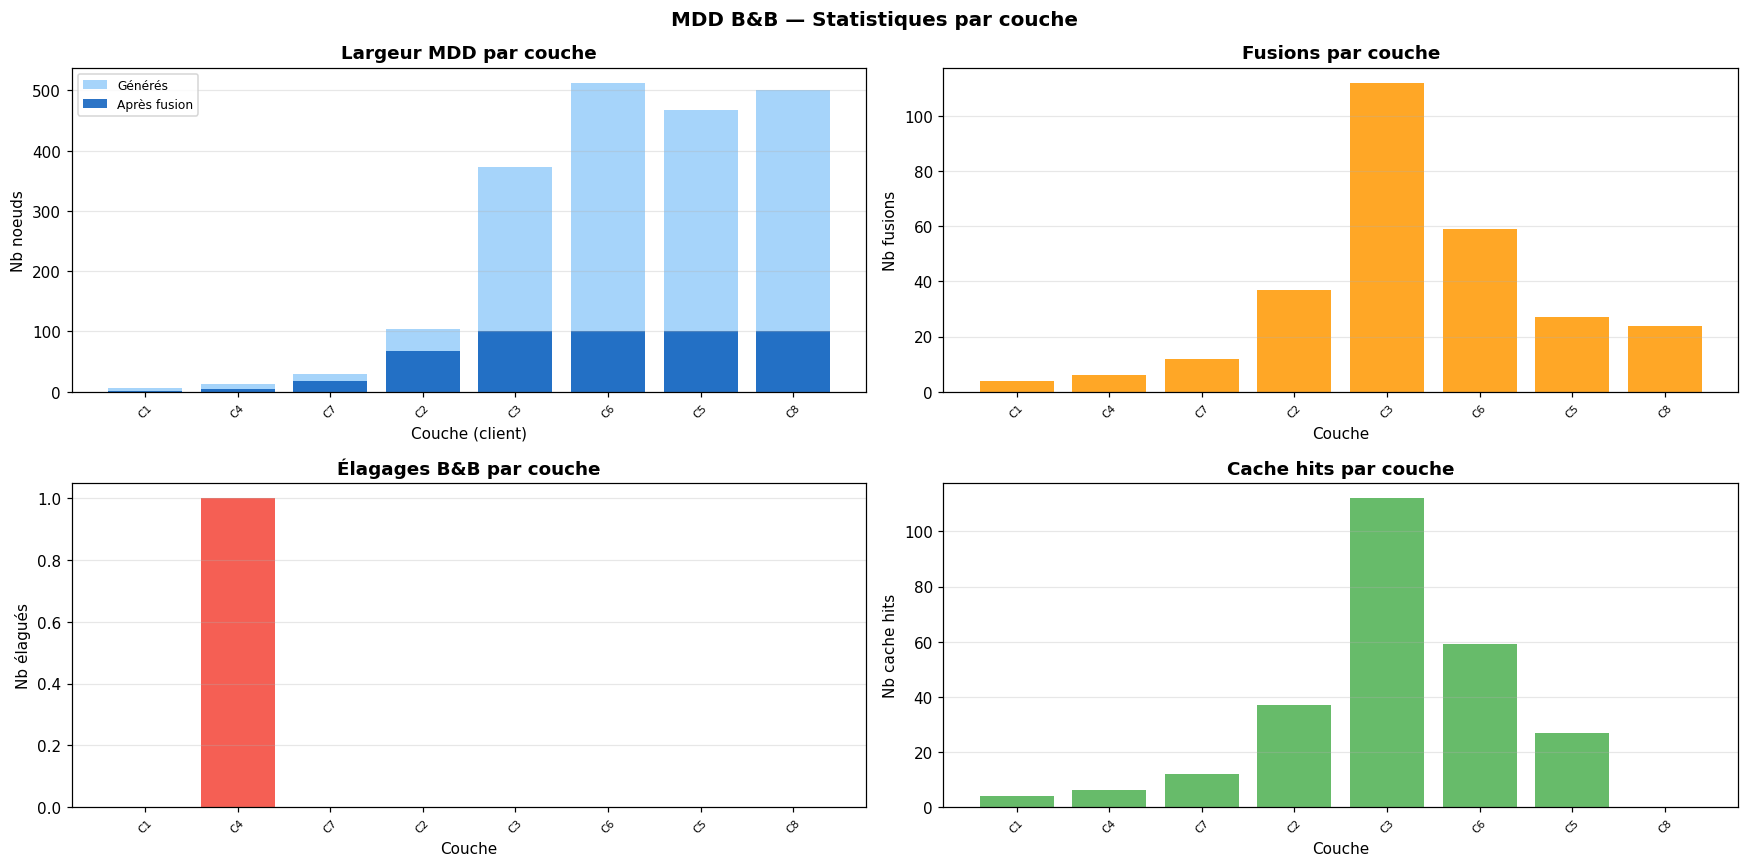

In [53]:
def plot_mdd_bb_stats(layer_stats, save_path='mdd_bb_stats_cvrp.png'):
    from matplotlib.gridspec import GridSpec
    layers  = [s.layer      for s in layer_stats]
    gen     = [s.generated  for s in layer_stats]
    fused   = [s.merged     for s in layer_stats]
    aft     = [s.after_merge for s in layer_stats]
    pruned  = [s.pruned     for s in layer_stats]
    cache   = [s.cache_hits for s in layer_stats]
    clients = [f'C{s.client}' for s in layer_stats]

    fig, axes = plt.subplots(2, 2, figsize=(16, 8))
    fig.suptitle('MDD B&B — Statistiques par couche', fontsize=13, fontweight='bold')

    ax = axes[0, 0]
    ax.bar(layers, gen, color='#90CAF9', label='Générés', alpha=0.8)
    ax.bar(layers, aft, color='#1565C0', label='Après fusion', alpha=0.9)
    ax.set_title('Largeur MDD par couche', fontweight='bold')
    ax.set_xlabel('Couche (client)'); ax.set_ylabel('Nb noeuds')
    ax.set_xticks(layers); ax.set_xticklabels(clients, fontsize=7, rotation=45)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

    ax = axes[0, 1]
    ax.bar(layers, fused, color='#FF9800', alpha=0.85)
    ax.set_title('Fusions par couche', fontweight='bold')
    ax.set_xlabel('Couche'); ax.set_ylabel('Nb fusions')
    ax.set_xticks(layers); ax.set_xticklabels(clients, fontsize=7, rotation=45)
    ax.grid(True, alpha=0.3, axis='y')

    ax = axes[1, 0]
    ax.bar(layers, pruned, color='#F44336', alpha=0.85)
    ax.set_title('Élagages B&B par couche', fontweight='bold')
    ax.set_xlabel('Couche'); ax.set_ylabel('Nb élagués')
    ax.set_xticks(layers); ax.set_xticklabels(clients, fontsize=7, rotation=45)
    ax.grid(True, alpha=0.3, axis='y')

    ax = axes[1, 1]
    ax.bar(layers, cache, color='#4CAF50', alpha=0.85)
    ax.set_title('Cache hits par couche', fontweight='bold')
    ax.set_xlabel('Couche'); ax.set_ylabel('Nb cache hits')
    ax.set_xticks(layers); ax.set_xticklabels(clients, fontsize=7, rotation=45)
    ax.grid(True, alpha=0.3, axis='y')

    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)

if mdd_bb_result:
    plot_mdd_bb_stats(mdd_bb_stats)


### 10.9 Visualisation de la solution MDD B&B

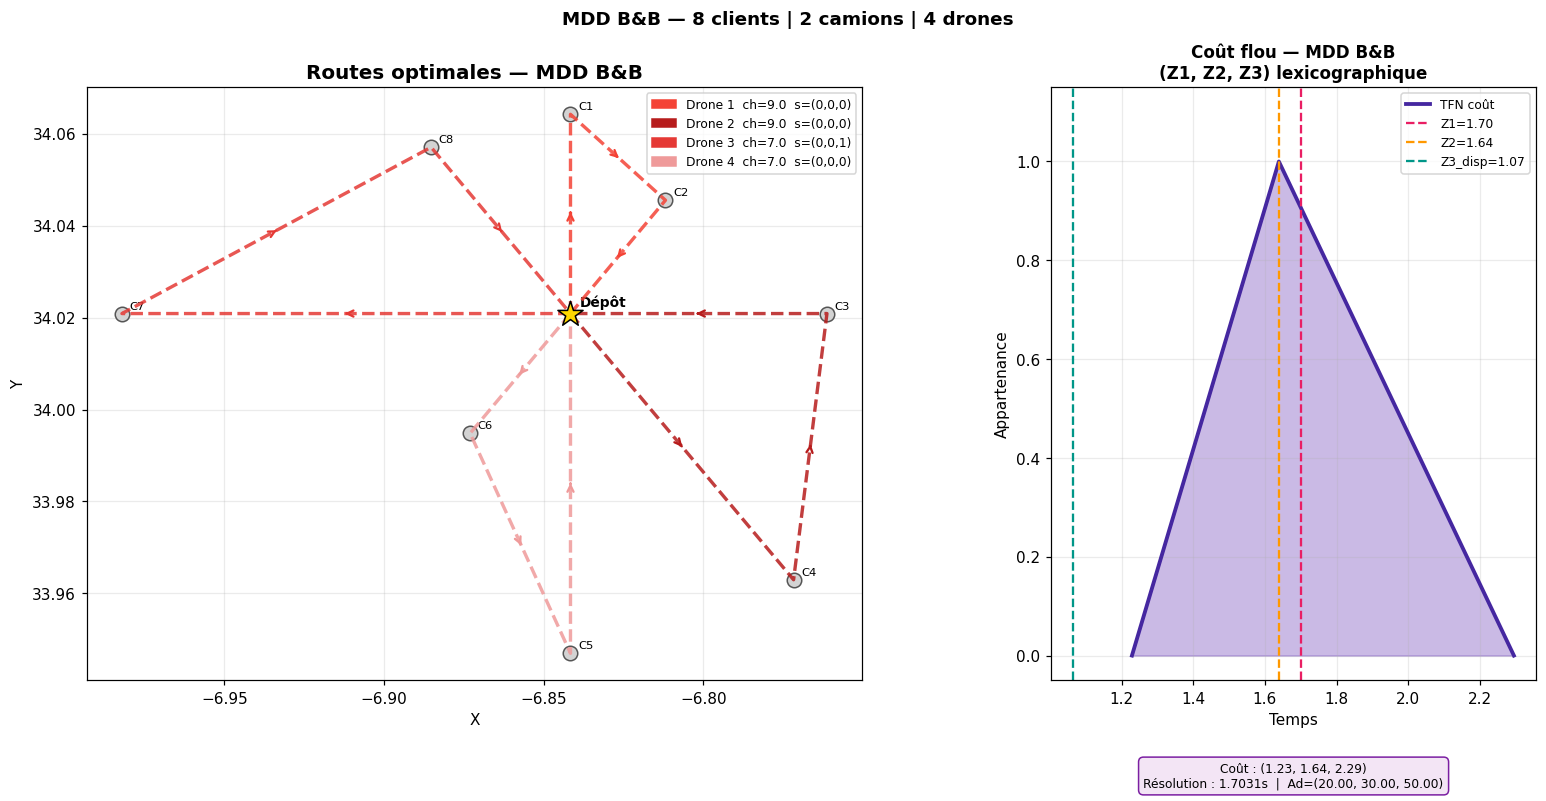

In [54]:
def plot_solution_mdd_bb(inst, sol, elapsed, save_path='solution_mdd_bb_cvrp.png'):
    from matplotlib.gridspec import GridSpec
    import matplotlib.patches as mpatches
    if sol is None or not inst.coords.size:
        print('[plot] Pas de solution/coordonnées.'); return
    routes_trucks, routes_drones, drone_cum_times, best_cost = sol

    fig = plt.figure(figsize=(17, 7))
    gs  = GridSpec(1, 2, figure=fig, wspace=0.30, width_ratios=[1.6, 1])
    ax_map   = fig.add_subplot(gs[0])
    ax_fuzzy = fig.add_subplot(gs[1])

    ax_map.set_title('Routes optimales — MDD B&B', fontsize=13, fontweight='bold')
    ax_map.scatter(*inst.coords[0], s=300, marker='*', color='gold',
                   edgecolors='black', zorder=6)
    ax_map.annotate('Dépôt', inst.coords[0], textcoords='offset points',
                    xytext=(6, 5), fontsize=9, fontweight='bold')
    for i in inst.C():
        ax_map.scatter(*inst.coords[i], s=90, color='lightgray',
                       edgecolors='#555', zorder=3)
        ax_map.annotate(f'C{i}', inst.coords[i],
                        textcoords='offset points', xytext=(5, 3), fontsize=7.5)

    handles = []
    def _draw(route, color, label, ls='-'):
        if not route: return
        full = [0] + route + [0]
        xs = [inst.coords[k][0] for k in full]
        ys = [inst.coords[k][1] for k in full]
        ax_map.plot(xs, ys, color=color, linewidth=2.2, linestyle=ls, zorder=4, alpha=0.85)
        for k in range(len(full)-1):
            dx = inst.coords[full[k+1]][0] - inst.coords[full[k]][0]
            dy = inst.coords[full[k+1]][1] - inst.coords[full[k]][1]
            mx = (inst.coords[full[k]][0] + inst.coords[full[k+1]][0]) / 2
            my = (inst.coords[full[k]][1] + inst.coords[full[k+1]][1]) / 2
            ax_map.annotate('', xy=(mx+dx*0.01, my+dy*0.01),
                            xytext=(mx-dx*0.01, my-dy*0.01),
                            arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
        handles.append(mpatches.Patch(color=color, label=label))

    for t, r in enumerate(routes_trucks):
        tc = route_time_truck_bb(inst, r)
        _draw(r, _TC[t%len(_TC)],
              f'Camion {t+1}  ch={route_load_bb(inst,r):.1f}  t2={tc.a2:.1f}')
    for d, r in enumerate(routes_drones):
        tc  = route_time_drone_bb(inst, r)
        s_c = drone_cum_times[d]
        _draw(r, _DC[d%len(_DC)],
              f'Drone {d+1}  ch={route_load_bb(inst,r):.1f}  '
              f's=({s_c.a1:.0f},{s_c.a2:.0f},{s_c.a3:.0f})', ls='--')

    ax_map.legend(handles=handles, fontsize=8)
    ax_map.set_xlabel('X'); ax_map.set_ylabel('Y')
    ax_map.grid(True, alpha=0.25)

    ax_fuzzy.set_title('Coût flou — MDD B&B\n(Z1, Z2, Z3) lexicographique',
                        fontsize=11, fontweight='bold')
    ax_fuzzy.fill_between([best_cost.a1, best_cost.a2, best_cost.a3], [0, 1, 0],
                          alpha=0.35, color='#673AB7')
    ax_fuzzy.plot([best_cost.a1, best_cost.a2, best_cost.a3], [0, 1, 0],
                  color='#4527A0', linewidth=2.5, label='TFN coût')
    for val, lbl, col in [
        (best_cost.f1(), f'Z1={best_cost.f1():.2f}',          '#E91E63'),
        (best_cost.f2(), f'Z2={best_cost.f2():.2f}',           '#FF9800'),
        (best_cost.f3(), f'Z3_disp={best_cost.f3():.2f}',      '#009688'),
    ]:
        ax_fuzzy.axvline(val, linestyle='--', linewidth=1.5, color=col, label=lbl)
    ax_fuzzy.set_xlabel('Temps'); ax_fuzzy.set_ylabel("Appartenance")
    ax_fuzzy.set_ylim(-0.05, 1.15); ax_fuzzy.legend(fontsize=8)
    ax_fuzzy.grid(True, alpha=0.25)
    ax_fuzzy.text(0.5, -0.18,
                  f'Coût : {best_cost}\nRésolution : {elapsed:.4f}s  |  Ad={inst.A_drone}',
                  transform=ax_fuzzy.transAxes, ha='center', fontsize=8,
                  bbox=dict(boxstyle='round,pad=0.4', fc='#F3E5F5', ec='#7B1FA2'))
    fig.suptitle(
        f'MDD B&B — {inst.n} clients | {inst.mc} camions | {inst.md} drones',
        fontsize=12, fontweight='bold')
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)

plot_solution_mdd_bb(INST_DEMO, mdd_bb_result, mdd_bb_elapsed)


### 10.10 Comparaison B&B Munkres vs MDD B&B (vs Dantzig-Wolfe)

## 11. Heuristiques : CW, AG, ALNS, TS

Les quatre heuristiques classiques adaptées aux structures `TFN` / `Instance` de ce notebook.

**Représentation commune :** vecteur `assign[k] ∈ {0 … mc+md-1}` indiquant le véhicule
affecté au k-ième client `(k = 0 … n-1)`. Les indices `0…mc-1` = camions, `mc…mc+md-1` = drones.

**Critère :** ordre lexicographique `(Z1_Yager, Z2_Centrale, Z3_Dispersion)` — la comparaison
Python `<` entre tuples réalise automatiquement cet ordre.

### 11.1 Imports & utilitaires communs

In [24]:
def print_heuristic_solution(inst, name, rt, rd, dct, cost, elapsed):
    SEP = '='*72; sep = '-'*72
    print(SEP)
    print(f'  SOLUTION — {name}')
    print(SEP)
    print(f'  Temps : {elapsed:.4f} s')
    print(sep)
    for t, r in enumerate(rt):
        if r:
            tc = route_time_truck_bb(inst, r)
            print(f'  Camion {t+1}: {" -> ".join(["0"]+[str(c) for c in r]+["0"])}')
            print(f'    charge={route_load_bb(inst,r):.1f}/{inst.Qc}  Z1={tc.f1():.2f}')
    print(sep)
    for d, r in enumerate(rd):
        if r:
            tc = route_time_drone_bb(inst, r); sc = dct[d]
            print(f'  Drone  {d+1}: {" -> ".join(["0"]+[str(c) for c in r]+["0"])}')
            print(f'    charge={route_load_bb(inst,r):.1f}/{inst.Qd}  s~=({sc.a1:.1f},{sc.a2:.1f},{sc.a3:.1f})')
    print(sep)
    print(f'  Coût total : {cost}')
    print(f'    Z1 (Yager)      = {cost.f1():.4f}')
    print(f'    Z2 (Centrale)   = {cost.f2():.4f}')
    print(f'    Z3 (Dispersion) = {cost.f3():.4f}')
    print(SEP)


def plot_heuristic_solution(inst, name, rt, rd, dct, cost, elapsed,
                             color_main='#388E3C', save_path=None):
    from matplotlib.gridspec import GridSpec
    import matplotlib.patches as mpatches
    fig = plt.figure(figsize=(17, 7))
    gs  = GridSpec(1, 2, figure=fig, wspace=0.30, width_ratios=[1.6, 1])
    ax_map = fig.add_subplot(gs[0]); ax_f = fig.add_subplot(gs[1])
    ax_map.set_title(f'Routes — {name}', fontsize=13, fontweight='bold')
    ax_map.scatter(*inst.coords[0], s=300, marker='*', color='gold', edgecolors='black', zorder=6)
    ax_map.annotate('Dépôt', inst.coords[0], textcoords='offset points', xytext=(6,5), fontsize=9, fontweight='bold')
    for i in inst.C():
        ax_map.scatter(*inst.coords[i], s=90, color='lightgray', edgecolors='#555', zorder=3)
        ax_map.annotate(f'C{i}', inst.coords[i], textcoords='offset points', xytext=(5,3), fontsize=7.5)
    handles = []
    def _draw(route, color, label, ls='-'):
        if not route: return
        full = [0]+route+[0]
        xs = [inst.coords[k][0] for k in full]; ys = [inst.coords[k][1] for k in full]
        ax_map.plot(xs, ys, color=color, linewidth=2.2, linestyle=ls, zorder=4, alpha=0.85)
        for k in range(len(full)-1):
            dx=inst.coords[full[k+1]][0]-inst.coords[full[k]][0]
            dy=inst.coords[full[k+1]][1]-inst.coords[full[k]][1]
            mx=(inst.coords[full[k]][0]+inst.coords[full[k+1]][0])/2
            my=(inst.coords[full[k]][1]+inst.coords[full[k+1]][1])/2
            ax_map.annotate('', xy=(mx+dx*0.01,my+dy*0.01), xytext=(mx-dx*0.01,my-dy*0.01),
                            arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
        handles.append(mpatches.Patch(color=color, label=label))
    for t, r in enumerate(rt):
        tc = route_time_truck_bb(inst, r)
        _draw(r, _TC[t%len(_TC)], f'Camion {t+1}  ch={route_load_bb(inst,r):.1f}  t2={tc.a2:.1f}')
    for d, r in enumerate(rd):
        tc = route_time_drone_bb(inst, r); sc = dct[d]
        _draw(r, _DC[d%len(_DC)],
              f'Drone {d+1}  ch={route_load_bb(inst,r):.1f}  s=({sc.a1:.0f},{sc.a2:.0f},{sc.a3:.0f})', ls='--')
    ax_map.legend(handles=handles, fontsize=8); ax_map.set_xlabel('X'); ax_map.set_ylabel('Y'); ax_map.grid(True, alpha=0.25)
    ax_f.set_title(f'Coût flou — {name}', fontsize=11, fontweight='bold')
    ax_f.fill_between([cost.a1, cost.a2, cost.a3], [0,1,0], alpha=0.35, color=color_main)
    ax_f.plot([cost.a1, cost.a2, cost.a3], [0,1,0], color=color_main, linewidth=2.5)
    for val, lbl, col in [
        (cost.f1(), f'Z1={cost.f1():.2f}', '#E91E63'),
        (cost.f2(), f'Z2={cost.f2():.2f}', '#FF9800'),
        (cost.f3(), f'Z3_disp={cost.f3():.2f}', '#009688'),
    ]:
        ax_f.axvline(val, linestyle='--', linewidth=1.5, color=col, label=lbl)
    ax_f.set_xlabel('Temps'); ax_f.set_ylabel("Appartenance")
    ax_f.set_ylim(-0.05, 1.15); ax_f.legend(fontsize=8); ax_f.grid(True, alpha=0.25)
    ax_f.text(0.5, -0.18, f'Coût : {cost}\n{elapsed:.4f}s',
              transform=ax_f.transAxes, ha='center', fontsize=8,
              bbox=dict(boxstyle='round,pad=0.4', fc='#F5F5F5', ec='#757575'))
    fig.suptitle(f'{name} — {inst.n} clients | {inst.mc} camions | {inst.md} drones',
                 fontsize=12, fontweight='bold')
    fig.tight_layout()
    if save_path: fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show(); plt.close(fig)


print('Fonctions affichage heuristiques OK')


Fonctions affichage heuristiques OK


### 11.2 Clarke & Wright (CW) — Algorithme des économies

In [26]:
def clarke_wright_h(inst):
    """
    Algorithme des économies de Clarke & Wright.
    Savings calculés sur le critère Yager (f1) des TFN camion.
    """
    t0      = time.perf_counter()
    clients = list(range(1, inst.n + 1))

    # 1. Économies Yager
    savings = []
    for ii, i in enumerate(clients):
        for j in clients[ii+1:]:
            s = (inst.tC_tfn(0,i).f1() + inst.tC_tfn(0,j).f1()
                 - inst.tC_tfn(i,j).f1())
            savings.append((s, i, j))
    savings.sort(reverse=True)

    # 2. Routes initiales : chaque client sur son propre véhicule
    route_of = {}; routes = {}; loads = {}
    for idx, cli in enumerate(clients):
        vk = ('T', idx % inst.mc) if idx < inst.mc else ('D', (idx-inst.mc) % inst.md)
        route_of[cli] = vk
        routes.setdefault(vk, []).append(cli)
        loads[vk] = loads.get(vk, 0.0) + float(inst.q[cli])

    # 3. Fusions
    Ad = inst.A_drone
    for s_val, i, j in savings:
        if s_val <= 0: break
        vk_i = route_of[i]; vk_j = route_of[j]
        if vk_i == vk_j: continue
        ri = routes[vk_i]; rj = routes[vk_j]
        if   ri[-1]==i and rj[0]==j:  merged = ri+rj
        elif rj[-1]==j and ri[0]==i:  merged = rj+ri
        else: continue
        new_load = loads[vk_i]+loads[vk_j]
        vk_new = vk_i if vk_i[0]=='T' else (vk_j if vk_j[0]=='T' else vk_i)
        Qmax = inst.Qc if vk_new[0]=='T' else inst.Qd
        if new_load > Qmax: continue
        if vk_new[0]=='D':
            s_cum=TFN_ZERO; prev=0; ok=True
            for cli in merged:
                arc=inst.tD_tfn(prev,cli); ret=inst.tD_tfn(cli,0)
                ns1=s_cum.a1+arc.a1; ns2=s_cum.a2+arc.a2; ns3=s_cum.a3+arc.a3
                if (ns1>Ad.a1 or ns2>Ad.a2 or ns3>Ad.a3
                        or ns1+ret.a1>Ad.a1 or ns2+ret.a2>Ad.a2 or ns3+ret.a3>Ad.a3):
                    ok=False; break
                s_cum=TFN(round(ns1,3),round(ns2,3),round(ns3,3)); prev=cli
            if not ok: continue
        del routes[vk_i]; del routes[vk_j]
        del loads[vk_i];  del loads[vk_j]
        routes[vk_new]=merged; loads[vk_new]=new_load
        for cli in merged: route_of[cli]=vk_new

    # 4. Construction du vecteur assign
    assign = [-1]*inst.n
    for cli in clients:
        vk = route_of[cli]
        assign[cli-1] = vk[1] if vk[0]=='T' else inst.mc+vk[1]

    elapsed = time.perf_counter()-t0
    res = eval_solution_h(inst, assign)
    if res is None:  # repli sur glouton
        assign = greedy_assign_h(inst)
        res    = eval_solution_h(inst, assign) if assign else None
    if res is None: return None, elapsed
    rt, rd, dct, cost = res
    print(f'[CW] {elapsed:.4f}s  |  Coût : {cost}  (Z1={cost.f1():.3f}, Z2={cost.f2():.3f}, Z3={cost.f3():.3f})')
    return (assign, rt, rd, dct, cost), elapsed


print('Clarke & Wright (TFN) défini OK')


Clarke & Wright (TFN) défini OK


=== Clarke & Wright ===

[CW] 0.0037s  |  Coût : (5.81, 6.84, 8.89)  (Z1=7.094, Z2=6.837, Z3=3.077)
  SOLUTION — Clarke & Wright
  Temps : 0.0037 s
------------------------------------------------------------------------
  Camion 1: 0 -> 1 -> 2 -> 3 -> 4 -> 5 -> 6 -> 7 -> 8 -> 9 -> 10 -> 11 -> 12 -> 13 -> 14 -> 15 -> 16 -> 17 -> 18 -> 19 -> 20 -> 21 -> 22 -> 23 -> 24 -> 25 -> 26 -> 27 -> 28 -> 29 -> 30 -> 0
    charge=96.0/500  Z1=7.09
------------------------------------------------------------------------
------------------------------------------------------------------------
  Coût total : (5.81, 6.84, 8.89)
    Z1 (Yager)      = 7.0935
    Z2 (Centrale)   = 6.8371
    Z3 (Dispersion) = 3.0765


C:\Users\abidm\AppData\Local\Temp\ipykernel_14652\4293208875.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


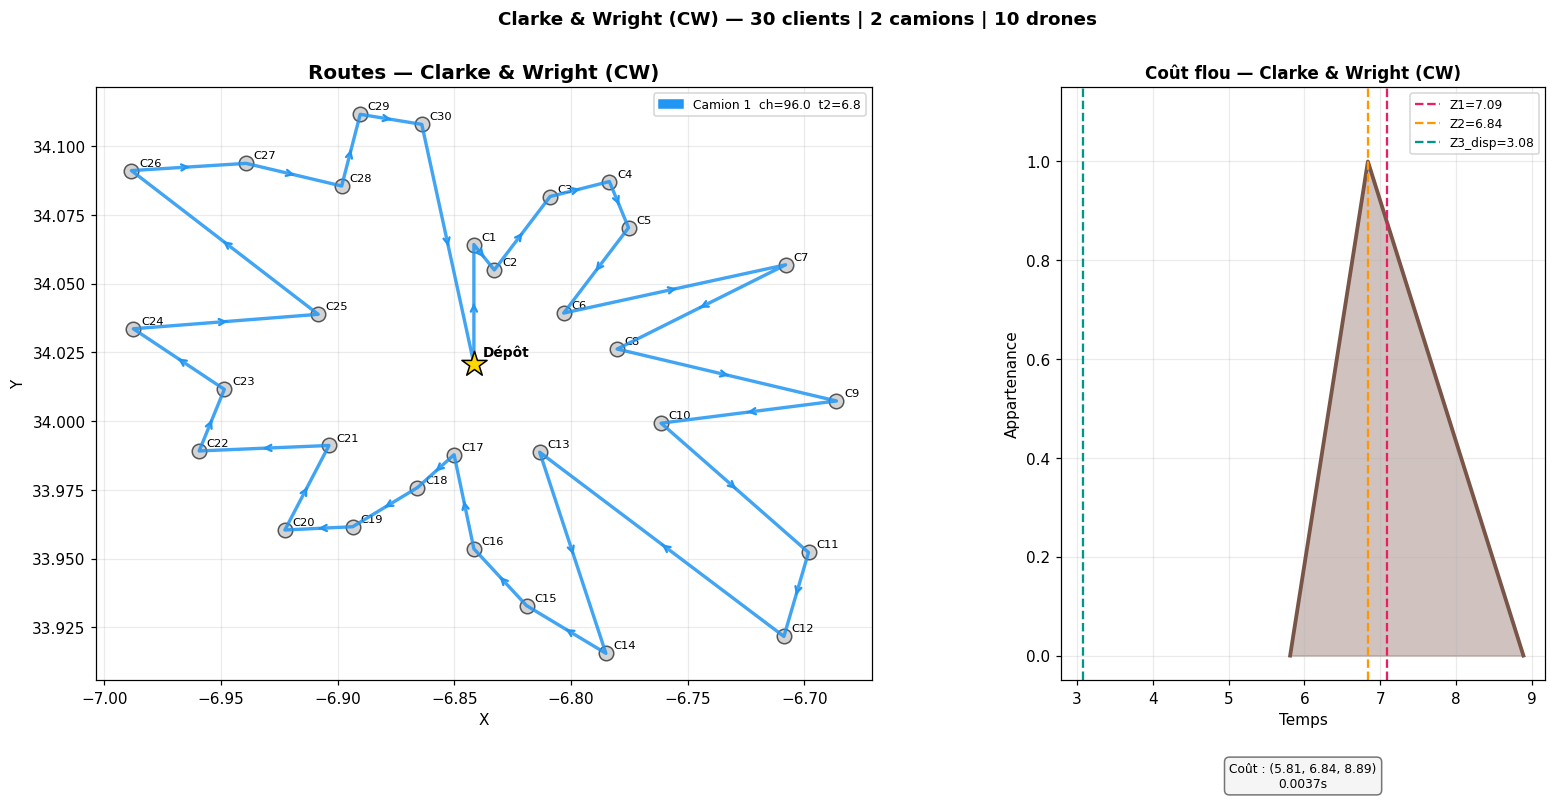

In [94]:
print('=== Clarke & Wright ===\n')
cw_h_result, cw_h_elapsed = clarke_wright_h(INST_DEMO)

if cw_h_result:
    _, cw_h_rt, cw_h_rd, cw_h_dct, cw_h_cost = cw_h_result
    print_heuristic_solution(INST_DEMO, 'Clarke & Wright', cw_h_rt, cw_h_rd, cw_h_dct, cw_h_cost, cw_h_elapsed)
    plot_heuristic_solution(INST_DEMO, 'Clarke & Wright (CW)', cw_h_rt, cw_h_rd, cw_h_dct,
                             cw_h_cost, cw_h_elapsed, color_main='#795548')
else:
    print('CW : pas de solution.'); cw_h_cost = None


### 11.3 Algorithme Génétique (AG)

**Chromosome :** vecteur `assign`. Sélection par tournoi, croisement uniforme, mutation aléatoire.  
**Fitness :** triplet lexicographique `(Z1, Z2, Z3)` — minimisation.

In [27]:
def genetic_algorithm_h(inst, pop_size=60, n_gen=200, cx_rate=0.75, mut_rate=0.15,
                         tourn_size=4, seed=42, verbose=True):
    random.seed(seed)
    t0    = time.perf_counter()
    n_veh = inst.mc + inst.md

    # Population initiale
    pop = []
    g   = greedy_assign_h(inst)
    if g: pop.append(g)
    while len(pop) < pop_size:
        a = random_assign_h(inst)
        if a: pop.append(a)
    if not pop: return None, 0.0, []

    def fit(a): return cost_lex_h(inst, a)

    best_a  = min(pop, key=fit)
    best_f  = fit(best_a)
    history = [best_f[0]]

    for gen in range(n_gen):
        new_pop = [best_a[:]]
        while len(new_pop) < pop_size:
            c1 = random.sample(pop, min(tourn_size, len(pop)))
            c2 = random.sample(pop, min(tourn_size, len(pop)))
            p1 = min(c1, key=fit); p2 = min(c2, key=fit)
            child = [p1[k] if random.random()<cx_rate else p2[k] for k in range(inst.n)]
            for k in range(inst.n):
                if random.random()<mut_rate: child[k]=random.randint(0,n_veh-1)
            if not feasible_h(inst, child):
                child = greedy_assign_h(inst) or p1[:]
            new_pop.append(child)
        pop   = new_pop
        cur   = min(pop, key=fit); cur_f = fit(cur)
        if cur_f < best_f: best_f=cur_f; best_a=cur[:]
        history.append(best_f[0])
        if verbose and (gen%50==0 or gen==n_gen-1):
            print(f'  Gen {gen+1:>4}/{n_gen}  |  '
                  f'(Z1={best_f[0]:.4f}, Z2={best_f[1]:.4f}, Z3={best_f[2]:.4f})')

    elapsed = time.perf_counter()-t0
    res = eval_solution_h(inst, best_a)
    if res is None: return None, elapsed, history
    rt, rd, dct, cost = res
    print(f'\n[AG] {elapsed:.4f}s  |  Coût : {cost}')
    return (best_a, rt, rd, dct, cost), elapsed, history


print('Algorithme Génétique (TFN) défini OK')


Algorithme Génétique (TFN) défini OK


=== Algorithme Génétique ===

  Gen    1/200  |  (Z1=6.2624, Z2=6.0359, Z3=3.7519)
  Gen   51/200  |  (Z1=6.2624, Z2=6.0359, Z3=3.7519)
  Gen  101/200  |  (Z1=6.2624, Z2=6.0359, Z3=3.7519)
  Gen  151/200  |  (Z1=6.2624, Z2=6.0359, Z3=3.7519)
  Gen  200/200  |  (Z1=6.2624, Z2=6.0359, Z3=3.7519)

[AG] 31.3249s  |  Coût : (4.61, 6.04, 8.36)
  SOLUTION — Algorithme Génétique
  Temps : 31.3249 s
------------------------------------------------------------------------
  Camion 1: 0 -> 30 -> 0
    charge=3.0/500  Z1=0.89
------------------------------------------------------------------------
  Drone  1: 0 -> 1 -> 2 -> 0
    charge=9.0/10  s~=(0.1,0.1,0.2)
  Drone  2: 0 -> 3 -> 4 -> 0
    charge=9.0/10  s~=(0.1,0.2,0.3)
  Drone  3: 0 -> 5 -> 7 -> 9 -> 0
    charge=9.0/10  s~=(0.3,0.4,0.6)
  Drone  4: 0 -> 6 -> 8 -> 10 -> 11 -> 0
    charge=10.0/10  s~=(0.3,0.4,0.5)
  Drone  5: 0 -> 12 -> 14 -> 15 -> 0
    charge=9.0/10  s~=(0.4,0.5,0.8)
  Drone  6: 0 -> 13 -> 16 -> 0
    charge=10.0/10  s~=(0

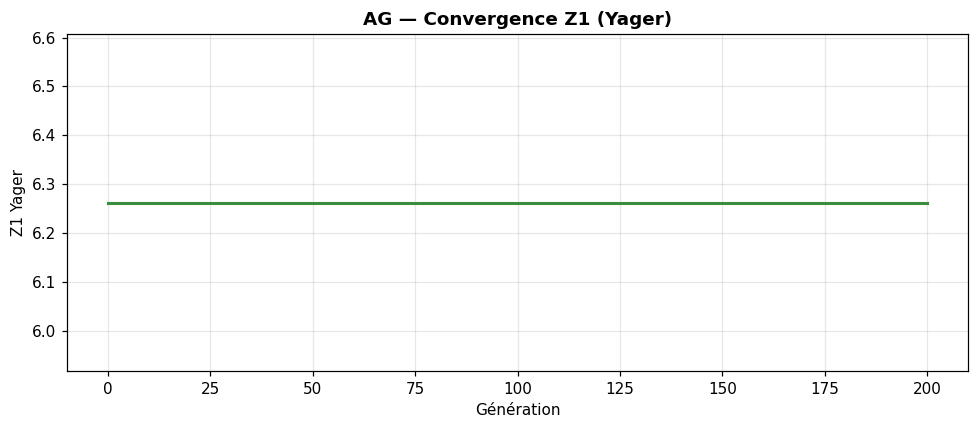

C:\Users\abidm\AppData\Local\Temp\ipykernel_14652\4293208875.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


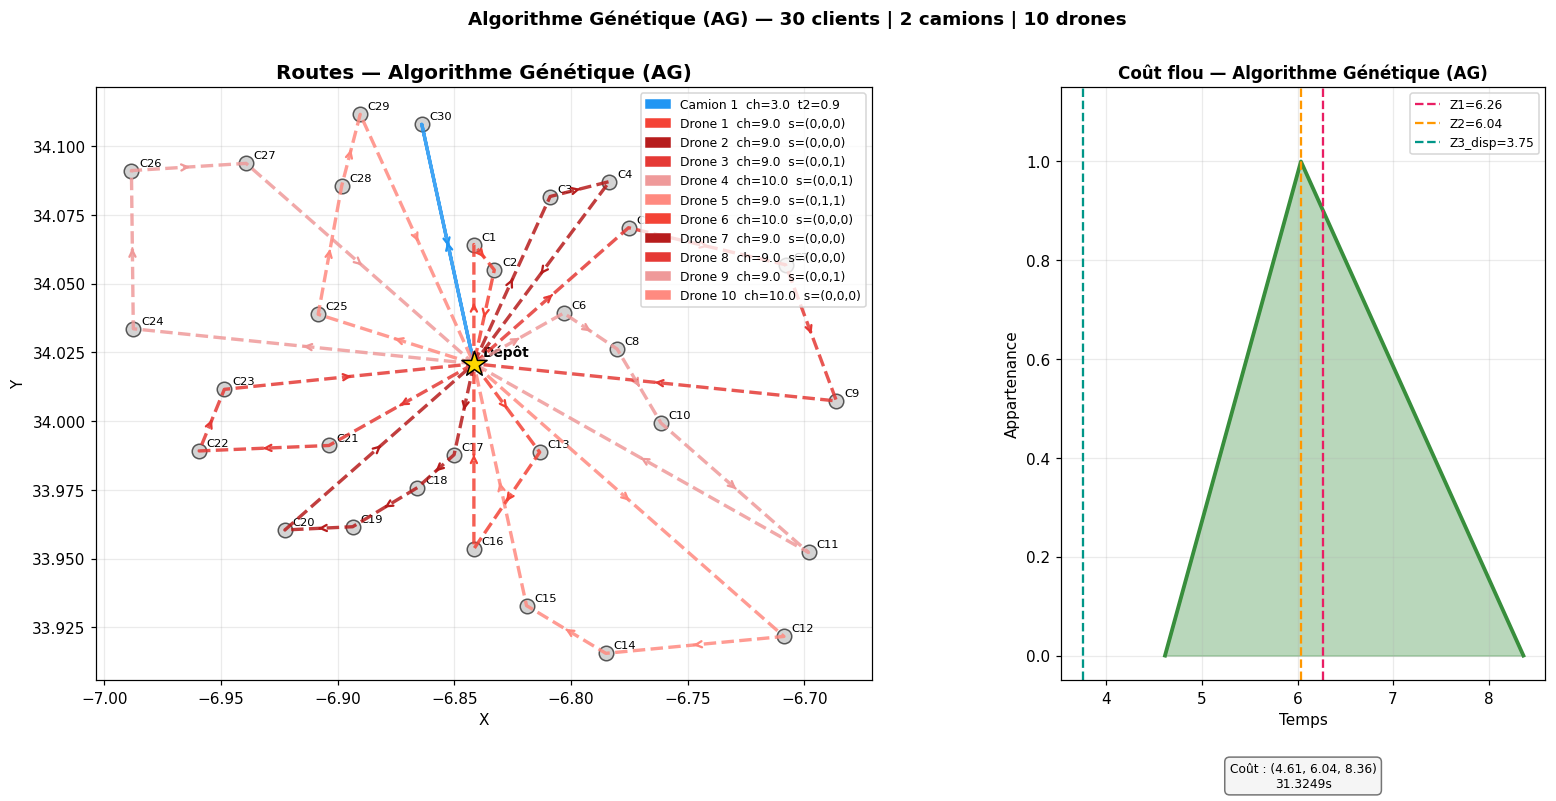

In [95]:
print('=== Algorithme Génétique ===\n')
ag_h_result, ag_h_elapsed, ag_h_history = genetic_algorithm_h(
    INST_DEMO, pop_size=20, n_gen=200, cx_rate=0.75, mut_rate=0.15, seed=42, verbose=True)

if ag_h_result:
    _, ag_h_rt, ag_h_rd, ag_h_dct, ag_h_cost = ag_h_result
    print_heuristic_solution(INST_DEMO, 'Algorithme Génétique', ag_h_rt, ag_h_rd, ag_h_dct, ag_h_cost, ag_h_elapsed)
    # Courbe de convergence
    fig, ax = plt.subplots(figsize=(9,4))
    ax.plot(ag_h_history, color='#388E3C', linewidth=2)
    ax.set_title('AG — Convergence Z1 (Yager)', fontweight='bold')
    ax.set_xlabel('Génération'); ax.set_ylabel('Z1 Yager'); ax.grid(True, alpha=0.3)
    fig.tight_layout(); plt.show(); plt.close(fig)
    plot_heuristic_solution(INST_DEMO, 'Algorithme Génétique (AG)', ag_h_rt, ag_h_rd, ag_h_dct,
                             ag_h_cost, ag_h_elapsed, color_main='#388E3C')
else:
    print('AG : pas de solution.'); ag_h_cost = None


### 11.4 ALNS — Adaptive Large Neighborhood Search

**Destruction :** `random_removal`, `worst_removal`, `related_removal`.  
**Réparation :** `greedy_repair`, `regret_repair`.  
**Acceptation :** recuit simulé sur Z1, scores adaptatifs sur les opérateurs.

In [28]:
def alns_h(inst, n_iter=1500, q_destroy=3, segment=50,
            sigma1=33, sigma2=9, sigma3=3,
            cool_start=0.95, cool_rate=0.998, seed=42, verbose=True):
    random.seed(seed)
    t0    = time.perf_counter()
    n_veh = inst.mc + inst.md

    current = greedy_assign_h(inst)
    if current is None: return None, 0.0, []
    cur_f   = cost_lex_h(inst, current)
    best    = current[:]; best_f = cur_f
    T       = cool_start * cur_f[0]

    d_ops=['random','worst','related']; r_ops=['greedy','regret']
    d_w=[1.0]*3; r_w=[1.0]*2
    d_sc=[0.0]*3; r_sc=[0.0]*2
    d_cnt=[0]*3;  r_cnt=[0]*2

    def pick(w):
        s=sum(w); r=random.uniform(0,s)
        for i,wi in enumerate(w):
            r-=wi
            if r<=0: return i
        return len(w)-1

    def rand_rem(a,q):
        rm=random.sample(range(inst.n),q); p=a[:]
        for k in rm: p[k]=-1
        return p,rm

    def worst_rem(a,q):
        res=eval_solution_h(inst,a)
        if res is None: return rand_rem(a,q)
        base=res[3]; mg=[]
        for k in range(inst.n):
            a2=a[:]; a2[k]=0
            res2=eval_solution_h(inst,a2)
            if res2 is None:
                mg.append((_LEX_INF_H,k))
            else:
                c2=res2[3]
                gain=(base.f1()-c2.f1(), base.f2()-c2.f2(), base.f3()-c2.f3())
                mg.append((gain,k))
        mg.sort(key=lambda x:x[0],reverse=True)
        rm=[mg[i][1] for i in range(q)]; p=a[:]
        for k in rm: p[k]=-1
        return p,rm

    def related_rem(a,q):
        if not inst.coords.size: return rand_rem(a,q)
        piv=random.randint(0,inst.n-1); c_piv=piv+1
        ds=[(float(np.linalg.norm(inst.coords[c_piv]-inst.coords[k+1])),k)
            for k in range(inst.n) if k!=piv]
        ds.sort(); rm=[piv]+[ds[i][1] for i in range(min(q-1,len(ds)))]
        p=a[:]
        for k in rm: p[k]=-1
        return p,rm

    def greedy_rep(partial,rm):
        a=partial[:]
        for k in rm:
            best_v=-1; best_key=_LEX_INF_H
            for v in range(n_veh):
                a[k]=v
                if feasible_h(inst,a):
                    key=cost_lex_h(inst,a)
                    if key<best_key: best_key=key; best_v=v
            a[k]=best_v if best_v!=-1 else 0
        return a if feasible_h(inst,a) else None

    def regret_rep(partial,rm):
        a=partial[:]; remaining=list(rm)
        while remaining:
            rg=[]
            for k in remaining:
                cv=[]
                for v in range(n_veh):
                    a[k]=v
                    if feasible_h(inst,a): cv.append((cost_lex_h(inst,a),v))
                    a[k]=-1
                cv.sort(key=lambda x:x[0])
                if len(cv)<2: regret_val=_LEX_INF_H; best_v=cv[0][1] if cv else 0
                else:
                    f0=cv[0][0]; f1=cv[1][0]
                    regret_val=(f1[0]-f0[0],f1[1]-f0[1],f1[2]-f0[2]); best_v=cv[0][1]
                rg.append((regret_val,k,best_v))
            rg.sort(key=lambda x:x[0],reverse=True)
            _,k_b,v_b=rg[0]; a[k_b]=v_b; remaining.remove(k_b)
        return a if feasible_h(inst,a) else None

    history=[best_f[0]]; seg_best=cur_f

    for it in range(1,n_iter+1):
        if it%segment==0:
            for i in range(3):
                if d_cnt[i]>0: d_w[i]=max(0.1,d_w[i]*0.8+0.2*d_sc[i]/d_cnt[i])
                d_sc[i]=0.0; d_cnt[i]=0
            for i in range(2):
                if r_cnt[i]>0: r_w[i]=max(0.1,r_w[i]*0.8+0.2*r_sc[i]/r_cnt[i])
                r_sc[i]=0.0; r_cnt[i]=0
            seg_best=cur_f

        di=pick(d_w); ri=pick(r_w)
        d_cnt[di]+=1; r_cnt[ri]+=1
        q=min(random.randint(max(1,q_destroy-1),q_destroy+1),inst.n-1)
        if   d_ops[di]=='random':  p,rm=rand_rem(current,q)
        elif d_ops[di]=='worst':   p,rm=worst_rem(current,q)
        else:                       p,rm=related_rem(current,q)
        new_a=greedy_rep(p,rm) if r_ops[ri]=='greedy' else regret_rep(p,rm)
        if new_a is None: history.append(best_f[0]); continue
        new_f=cost_lex_h(inst,new_a); score=0; acc=False
        if new_f<best_f:       best=new_a[:]; best_f=new_f; score=sigma1; acc=True
        elif new_f<seg_best:   seg_best=new_f; score=sigma2; acc=True
        elif new_f<cur_f:      score=sigma3; acc=True
        if not acc and T>1e-8:
            delta=new_f[0]-cur_f[0]
            if delta<0 or random.random()<math.exp(-delta/T): acc=True; score=max(score,1)
        if acc: current=new_a[:]; cur_f=new_f
        d_sc[di]+=score; r_sc[ri]+=score; T*=cool_rate
        history.append(best_f[0])
        if verbose and (it%300==0 or it==n_iter):
            print(f'  Iter {it:>4}/{n_iter}  |  '
                  f'(Z1={best_f[0]:.4f}, Z2={best_f[1]:.4f}, Z3={best_f[2]:.4f})  T={T:.4f}')

    elapsed=time.perf_counter()-t0
    res=eval_solution_h(inst,best)
    if res is None: return None, elapsed, history
    rt,rd,dct,cost=res
    print(f'\n[ALNS] {elapsed:.4f}s  |  Coût : {cost}')
    return (best,rt,rd,dct,cost), elapsed, history


print('ALNS (TFN) défini OK')


ALNS (TFN) défini OK


=== ALNS ===

  Iter  300/1500  |  (Z1=5.5178, Z2=5.3184, Z3=2.5944)  T=3.2631
  Iter  600/1500  |  (Z1=5.5178, Z2=5.3184, Z3=2.5944)  T=1.7897
  Iter  900/1500  |  (Z1=5.5178, Z2=5.3184, Z3=2.5944)  T=0.9816
  Iter 1200/1500  |  (Z1=5.5178, Z2=5.3184, Z3=2.5944)  T=0.5384
  Iter 1500/1500  |  (Z1=5.5178, Z2=5.3184, Z3=2.5944)  T=0.2953

[ALNS] 50.5256s  |  Coût : (4.42, 5.32, 7.01)
  SOLUTION — ALNS
  Temps : 50.5256 s
------------------------------------------------------------------------
  Camion 2: 0 -> 1 -> 3 -> 4 -> 5 -> 7 -> 9 -> 11 -> 12 -> 14 -> 15 -> 16 -> 18 -> 19 -> 20 -> 22 -> 23 -> 24 -> 26 -> 27 -> 28 -> 29 -> 30 -> 0
    charge=69.0/500  Z1=4.48
------------------------------------------------------------------------
  Drone  1: 0 -> 2 -> 6 -> 0
    charge=8.0/10  s~=(0.1,0.1,0.2)
  Drone  5: 0 -> 8 -> 10 -> 13 -> 0
    charge=9.0/10  s~=(0.2,0.3,0.4)
  Drone  7: 0 -> 17 -> 21 -> 25 -> 0
    charge=10.0/10  s~=(0.2,0.3,0.4)
---------------------------------------------

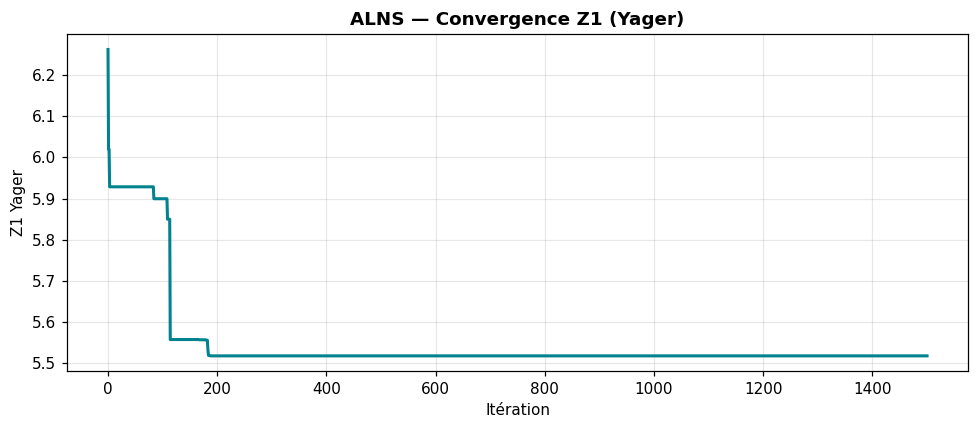

C:\Users\abidm\AppData\Local\Temp\ipykernel_14652\4293208875.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


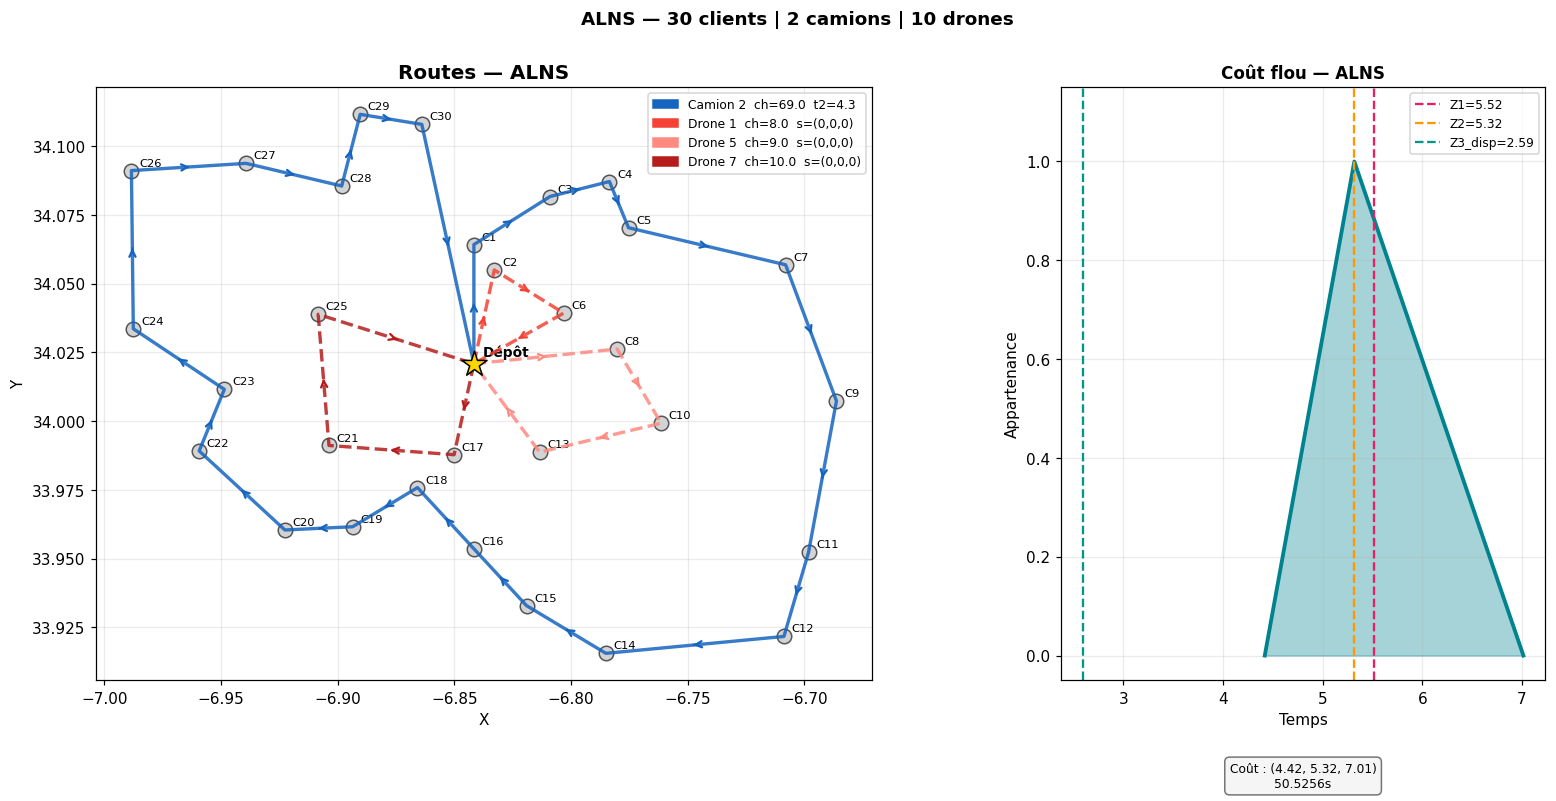

In [96]:
print('=== ALNS ===\n')
alns_h_result, alns_h_elapsed, alns_h_history = alns_h(
    INST_DEMO, n_iter=1500, q_destroy=3, segment=50,
    cool_start=0.95, cool_rate=0.998, seed=42, verbose=True)

if alns_h_result:
    _, alns_h_rt, alns_h_rd, alns_h_dct, alns_h_cost = alns_h_result
    print_heuristic_solution(INST_DEMO, 'ALNS', alns_h_rt, alns_h_rd, alns_h_dct, alns_h_cost, alns_h_elapsed)
    fig, ax = plt.subplots(figsize=(9,4))
    ax.plot(alns_h_history, color='#00838F', linewidth=2)
    ax.set_title('ALNS — Convergence Z1 (Yager)', fontweight='bold')
    ax.set_xlabel('Itération'); ax.set_ylabel('Z1 Yager'); ax.grid(True, alpha=0.3)
    fig.tight_layout(); plt.show(); plt.close(fig)
    plot_heuristic_solution(INST_DEMO, 'ALNS', alns_h_rt, alns_h_rd, alns_h_dct,
                             alns_h_cost, alns_h_elapsed, color_main='#00838F')
else:
    print('ALNS : pas de solution.'); alns_h_cost = None


### 11.5 Recherche Tabou (TS)

**Voisinage :** *Relocate* (changer un client de véhicule) et *Swap* (échanger deux clients).  
**Mémoire :** liste tabou sur les mouvements avec tenure fixe.  
**Critère d'aspiration :** le mouvement tabou est autorisé s'il améliore le meilleur global.

In [22]:
# ─── Helpers 2-opt intra-route ───────────────────────────────────────────────

def _route_cost_lex(inst, route_clients, vtype):
    """Coût lex (f1,f2,f3) d'une liste de clients avec dépôt 0 en tête et queue."""
    if not route_clients:
        return (0.0, 0.0, 0.0)
    full = [0] + route_clients + [0]
    c = TFN_ZERO
    for u, v in zip(full[:-1], full[1:]):
        c = c + (inst.tC_tfn(u, v) if vtype == 'truck' else inst.tD_tfn(u, v))
    return (c.f1(), c.f2(), c.f3())


def _drone_route_feasible(inst, route_clients):
    """Vérifie la faisabilité autonomie d'une route drone (liste de clients)."""
    Ad = inst.A_drone
    s = TFN_ZERO; prev = 0
    for cli in route_clients:
        arc = inst.tD_tfn(prev, cli)
        ret = inst.tD_tfn(cli, 0)
        ns1 = s.a1+arc.a1; ns2 = s.a2+arc.a2; ns3 = s.a3+arc.a3
        if (ns1 > Ad.a1 or ns2 > Ad.a2 or ns3 > Ad.a3 or
                ns1+ret.a1 > Ad.a1 or ns2+ret.a2 > Ad.a2 or ns3+ret.a3 > Ad.a3):
            return False
        s = TFN(round(ns1,3), round(ns2,3), round(ns3,3)); prev = cli
    return True


def _apply_2opt_routes(inst, rt, rd, n_neighbors):
    """Amélioration 2-opt intra-route sur toutes les routes camion et drone.

    Pour chaque route de longueur ≥ 2, on tire n_neighbors paires (i,j)
    aléatoires et on inverse le segment si le coût lex s'améliore.
    Retourne (rt_new, rd_new, improved: bool).
    """
    improved = False

    # ── Camions ──────────────────────────────────────────────────────────
    new_rt = [r[:] for r in rt]
    for t_idx, r in enumerate(new_rt):
        if len(r) < 2:
            continue
        best_r = r[:]
        best_cost = _route_cost_lex(inst, r, 'truck')
        for _ in range(n_neighbors):
            i = random.randint(0, len(r) - 2)
            j = random.randint(i + 1, len(r) - 1)
            candidate = r[:i] + r[i:j+1][::-1] + r[j+1:]
            cost_c = _route_cost_lex(inst, candidate, 'truck')
            if cost_c < best_cost:
                best_cost = cost_c
                best_r = candidate
                improved = True
        new_rt[t_idx] = best_r

    # ── Drones ───────────────────────────────────────────────────────────
    new_rd = [r[:] for r in rd]
    for d_idx, r in enumerate(new_rd):
        if len(r) < 2:
            continue
        best_r = r[:]
        best_cost = _route_cost_lex(inst, r, 'drone')
        for _ in range(n_neighbors):
            i = random.randint(0, len(r) - 2)
            j = random.randint(i + 1, len(r) - 1)
            candidate = r[:i] + r[i:j+1][::-1] + r[j+1:]
            if not _drone_route_feasible(inst, candidate):
                continue
            cost_c = _route_cost_lex(inst, candidate, 'drone')
            if cost_c < best_cost:
                best_cost = cost_c
                best_r = candidate
                improved = True
        new_rd[d_idx] = best_r

    return new_rt, new_rd, improved


# ─── Reconstruction d'une solution (assign) depuis rt/rd ─────────────────────

def _routes_to_assign(inst, rt, rd):
    """Reconstruit le vecteur assign depuis rt/rd (inverse de eval_solution_h)."""
    assign = [None] * inst.n
    clients = list(range(1, inst.n + 1))
    cli_to_idx = {c: k for k, c in enumerate(clients)}
    for t_idx, r in enumerate(rt):
        for cli in r:
            assign[cli_to_idx[cli]] = t_idx
    for d_idx, r in enumerate(rd):
        for cli in r:
            assign[cli_to_idx[cli]] = inst.mc + d_idx
    return assign


# ─── Tabou Search corrigée avec 2-opt intra-route ────────────────────────────

def tabu_search_h(inst, n_iter=2000, tabu_tenure=12, n_neighbors=40, seed=42, verbose=True):
    """Recherche Tabou avec trois mouvements :
      1. Relocate : réaffecter un client à un autre véhicule
      2. Swap     : échanger les affectations de deux clients
      3. 2-opt    : inverser un segment intra-route (explore les permutations)
    """
    random.seed(seed)
    t0    = time.perf_counter()
    n_veh = inst.mc + inst.md

    current = greedy_assign_h(inst)
    if current is None: return None, 0.0, []
    cur_f   = cost_lex_h(inst, current)
    best    = current[:]; best_f = cur_f
    tabu    = {}; history = [best_f[0]]

    for it in range(1, n_iter+1):
        neighbors = []

        # ── Mouvement 1 : Relocate ───────────────────────────────────────
        for _ in range(n_neighbors):
            k=random.randint(0,inst.n-1); v=random.randint(0,n_veh-1)
            if v==current[k]: continue
            nb=current[:]; nb[k]=v
            if not feasible_h(inst,nb): continue
            f=cost_lex_h(inst,nb)
            is_tabu=(k,v) in tabu and tabu[(k,v)]>it
            if not is_tabu or f<best_f: neighbors.append((f,nb,(k,v)))

        # ── Mouvement 2 : Swap ───────────────────────────────────────────
        for _ in range(n_neighbors):
            k1=random.randint(0,inst.n-1); k2=random.randint(0,inst.n-1)
            if k1==k2 or current[k1]==current[k2]: continue
            nb=current[:]; nb[k1],nb[k2]=nb[k2],nb[k1]
            if not feasible_h(inst,nb): continue
            f=cost_lex_h(inst,nb)
            mv=(min(k1,k2),max(k1,k2))
            is_tabu=mv in tabu and tabu[mv]>it
            if not is_tabu or f<best_f: neighbors.append((f,nb,mv))

        # ── Mouvement 3 : 2-opt intra-route ─────────────────────────────
        # On récupère les routes actuelles et on tente des inversions de segments.
        res_cur = eval_solution_h(inst, current)
        if res_cur is not None:
            cur_rt, cur_rd, _, _ = res_cur
            new_rt, new_rd, opt_improved = _apply_2opt_routes(inst, cur_rt, cur_rd, n_neighbors)
            if opt_improved:
                nb_2opt = _routes_to_assign(inst, new_rt, new_rd)
                if None not in nb_2opt and feasible_h(inst, nb_2opt):
                    f_2opt = cost_lex_h(inst, nb_2opt)
                    mv_2opt = ('2opt', it)   # clé unique de mouvement
                    is_tabu = mv_2opt in tabu and tabu[mv_2opt] > it
                    if not is_tabu or f_2opt < best_f:
                        neighbors.append((f_2opt, nb_2opt, mv_2opt))

        if not neighbors: history.append(best_f[0]); continue
        neighbors.sort(key=lambda x:x[0])
        f_new,current,move=neighbors[0]; tabu[move]=it+tabu_tenure
        if f_new<best_f:
            best_f=f_new; best=current[:]
            if verbose:
                print(f'  Iter {it:>4}  |  (Z1={best_f[0]:.4f}, Z2={best_f[1]:.4f}, Z3={best_f[2]:.4f})')
        history.append(best_f[0])

    elapsed=time.perf_counter()-t0
    res=eval_solution_h(inst,best)
    if res is None: return None, elapsed, history
    rt,rd,dct,cost=res

    # ── Post-optimisation 2-opt finale ───────────────────────────────────
    rt, rd, _ = _apply_2opt_routes(inst, rt, rd, n_neighbors=max(n_neighbors, 60))
    # Recalcul du coût après optimisation finale
    cost = TFN_ZERO
    for r in rt: cost = cost + route_time_truck_bb(inst, r)
    for r in rd: cost = cost + route_time_drone_bb(inst, r)

    print(f'\n[TS] {elapsed:.4f}s  |  Coût : {cost}')
    return (best,rt,rd,dct,cost), elapsed, history


print('Recherche Tabou (TFN) avec 2-opt définie OK')


Recherche Tabou (TFN) avec 2-opt définie OK


=== Recherche Tabou ===

  Iter    1  |  (Z1=14.3648, Z2=13.8457, Z3=8.9174)
  Iter    3  |  (Z1=14.3286, Z2=13.8108, Z3=8.8947)
  Iter    9  |  (Z1=14.2489, Z2=13.7341, Z3=8.8447)
  Iter   10  |  (Z1=14.1248, Z2=13.6144, Z3=8.7668)
  Iter   15  |  (Z1=14.1247, Z2=13.6143, Z3=8.7666)
  Iter   20  |  (Z1=13.9429, Z2=13.4391, Z3=8.6527)
  Iter   21  |  (Z1=13.9281, Z2=13.4249, Z3=8.6386)
  Iter   24  |  (Z1=13.6685, Z2=13.1747, Z3=8.4760)
  Iter   27  |  (Z1=13.6476, Z2=13.1546, Z3=8.4629)
  Iter   28  |  (Z1=13.6471, Z2=13.1541, Z3=8.4625)
  Iter   31  |  (Z1=13.5890, Z2=13.0981, Z3=8.4261)
  Iter   33  |  (Z1=13.5829, Z2=13.0922, Z3=8.4222)
  Iter   37  |  (Z1=13.5465, Z2=13.0571, Z3=8.3996)
  Iter   38  |  (Z1=13.5299, Z2=13.0411, Z3=8.3892)
  Iter   39  |  (Z1=13.5289, Z2=13.0401, Z3=8.3885)
  Iter   42  |  (Z1=13.3540, Z2=12.8715, Z3=8.2789)
  Iter   43  |  (Z1=13.3417, Z2=12.8596, Z3=8.2712)
  Iter   46  |  (Z1=13.3042, Z2=12.8234, Z3=8.2513)
  Iter   49  |  (Z1=13.2845, Z2=12.8045

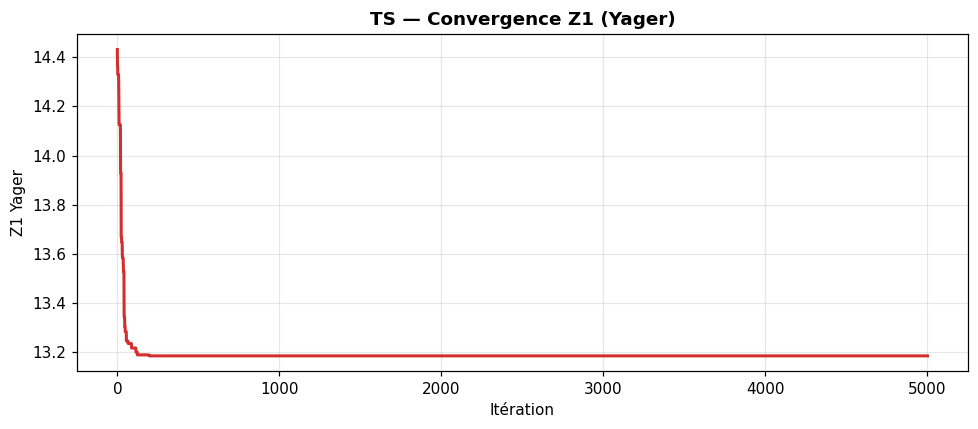

C:\Users\abidm\AppData\Local\Temp\ipykernel_284\4293208875.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


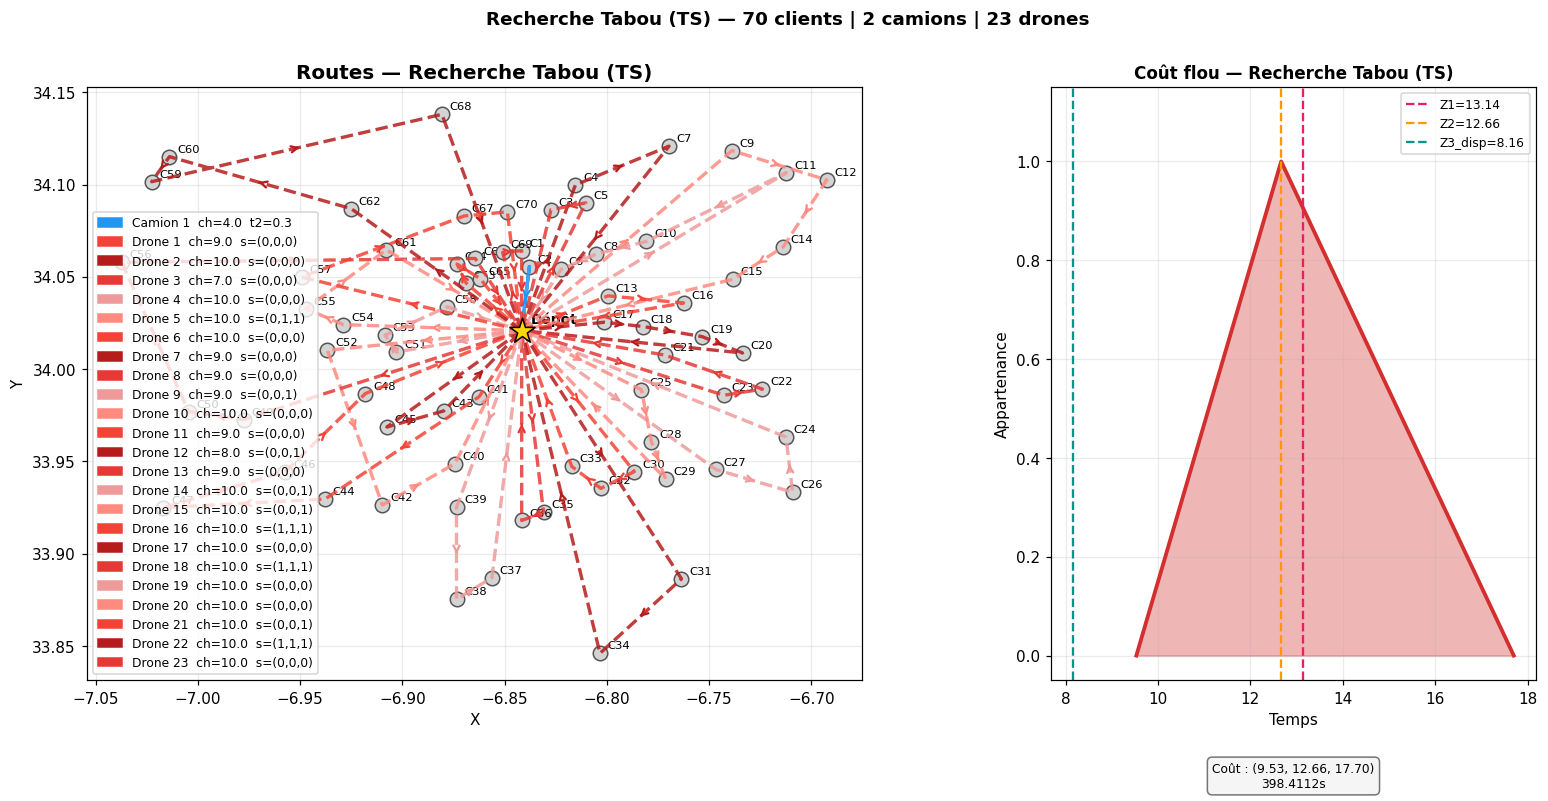

In [37]:
print('=== Recherche Tabou ===\n')
ts_h_result, ts_h_elapsed, ts_h_history = tabu_search_h(
    INST_DEMO, n_iter=5000, tabu_tenure=12, n_neighbors=40, seed=42, verbose=True)

if ts_h_result:
    _, ts_h_rt, ts_h_rd, ts_h_dct, ts_h_cost = ts_h_result
    print_heuristic_solution(INST_DEMO, 'Recherche Tabou', ts_h_rt, ts_h_rd, ts_h_dct, ts_h_cost, ts_h_elapsed)
    fig, ax = plt.subplots(figsize=(9,4))
    ax.plot(ts_h_history, color='#D32F2F', linewidth=2)
    ax.set_title('TS — Convergence Z1 (Yager)', fontweight='bold')
    ax.set_xlabel('Itération'); ax.set_ylabel('Z1 Yager'); ax.grid(True, alpha=0.3)
    fig.tight_layout(); plt.show(); plt.close(fig)
    plot_heuristic_solution(INST_DEMO, 'Recherche Tabou (TS)', ts_h_rt, ts_h_rd, ts_h_dct,
                             ts_h_cost, ts_h_elapsed, color_main='#D32F2F')
else:
    print('TS : pas de solution.'); ts_h_cost = None
